# Exploring how to make cyclone relative composites using TempestExtremes NodeFileFilter and NodeFileCompose

In [1]:
### Importing necessary packages
import pandas as pd
import os
from pathlib import Path
import re
import warnings

#warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", module="cartopy")

import matplotlib 
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import matplotlib.contour as mcontour
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable

import cmocean
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np
import seaborn as sns
import xarray as xr

from scipy.stats import permutation_test

## custom packages:
from download_era5_composite import timestamps_from_etc_summary, build_date_groups, download, OUT_DIR

## Creating two TempestExtremes nodefiles, each with one node per cyclone:

Full **DJFM 1996–2025** run. December is treated as in-season and attached to the **following** year's JFM (e.g. Dec 2019 → season 2020).

In [2]:
## full 1995-2025 summaries 
etc_summary = pd.read_csv('data/etc_summary_final.csv')
nodes_with_reports = pd.read_csv('data/nodes_with_reports_final.csv')
core_summary = pd.read_csv('data/kde_core_summary.csv')

In [3]:
MASTER_NODEFILE = "/data1/lepique/TempestExtremes/tracks/tracks_hourly_1995_2025.txt"  

def diagnose(master_nodefile, etc_summary):
    print("=== etc_summary columns ===")
    print(list(etc_summary.columns))
    print("\n=== etc_summary dtypes (relevant) ===")
    print(etc_summary.dtypes)
    print("\n=== etc_summary head ===")
    print(etc_summary.head())

    print("\n=== first 6 lines of master nodefile ===")
    with open(master_nodefile) as f:
        for i, line in enumerate(f):
            print(repr(line.rstrip("\n")))
            if i >= 5:
                break

In [13]:
diagnose(MASTER_NODEFILE, etc_summary)

=== etc_summary columns ===
['track_id', 'track_start', 'track_end', 'time_min_msl', 'min_msl', 'n_steps', 'n_reports', 'n_tornado', 'n_hail', 'n_wind', 'n_cores_total', 'n_cores_kept', 'kept_reports', 'max_core_reports', 'time_max_reports']

=== etc_summary dtypes (relevant) ===
track_id            float64
track_start          object
track_end            object
time_min_msl         object
min_msl             float64
n_steps               int64
n_reports             int64
n_tornado             int64
n_hail                int64
n_wind                int64
n_cores_total         int64
n_cores_kept          int64
kept_reports          int64
max_core_reports      int64
time_max_reports     object
dtype: object

=== etc_summary head ===
   track_id                track_start                  track_end  \
0       1.0  1995-12-01 00:00:00+00:00  1995-12-06 23:00:00+00:00   
1       2.0  1995-12-01 00:00:00+00:00  1995-12-12 03:00:00+00:00   
2       3.0  1995-12-03 06:00:00+00:00  1995-12-07 0

In [4]:
## CONFIG
REFERENCE = "min_msl" ## time to center the composite on (can use "max_reports")
COL_TRACKID = "track_id"
COL_NREPORTS = "n_reports"
COL_NCORESKEPT = "n_cores_kept"
COL_TIMEMAXREP = "time_max_reports"
COL_TIMEMSL = "time_min_msl"
REF_TIME_COL = COL_TIMEMSL if REFERENCE == "min_msl" else COL_TIMEMAXREP


## node data columns AFTER the two grid indices:
NODE_DATA_COLS = ["lon", "lat", "msl", "phis"]

## OC / NOC split: a cyclone is an "outbreak cyclone" if it has at least
## OUTBREAK_MIN_CORES kept cores (n_cores_kept >= OUTBREAK_MIN_CORES). NOC =
## fewer than that. Together these partition every in-season cyclone.
## (Earlier this was based on n_reports > 0.)
OUTBREAK_MIN_CORES = 1

## DJFM season for the full 1996-2025 run. December is in-season and is attached
## to the FOLLOWING year's JFM (e.g. Dec 2019 -> season 2020), via season_year().
MONTHS = (12, 1, 2, 3)

def season_year(ts):
    """DJFM season label: December belongs to the following year's JFM season."""
    ts = pd.Timestamp(ts)
    return ts.year + 1 if ts.month == 12 else ts.year

OUT_OC = "data/outbreak_cyclones_min_msl_cores_filtered.txt"
OUT_NOC = "data/nonoutbreak_cyclones_min_msl_cores_filtered.txt"

## ERA5 domain [N, W, S, E] -- kept in sync with download_era5_composite.py,
## which holds the authoritative ERA5 download config (variables, levels, the
## 9 min-MSL +/- offset reference times). Used here only for the southern-
## boundary check in select_reference_nodes.
ERA5_AREA = [70, -140, -10, -50]

## Composite-domain filter. A cyclone is kept only if its reference node lies
## inside this box, so the plotted +/-25 deg composite window stays largely
## inside the ERA5 download domain. Without it the nodefiles are GLOBAL: OC
## centers run from 175 W to 178 E and up to 86 N, and cyclones far outside the
## domain contribute mostly-NaN snapshots that still count toward n.
## [lon_min, lon_max, lat_min, lat_max], degrees east in -180..180.
CONUS_BOX = [-125.0, -65.0, 25.0, 50.0]
RESTRICT_TO_BOX = True


In [5]:
## Parse nodefile 
def parse_nodefile(path, data_cols):
    """
    Parse TE StitchNodes nodefile. track_id is 1-indexed (first block = 1) to
    match etc_summary. Datetime build is vectorized so it scales to the full
    1996-2025 record.
    """

    rows = []
    with open(path) as f:
        lines = [ln.rstrip("\n") for ln in f]

    i = 0
    tid = 0
    n_data = len(data_cols)
    while i < len(lines):
        parts = lines[i].split()
        if not parts:
            i += 1
            continue
        if parts[0] == "start":
            tid +=1
            n_steps = int(parts[1])
            for k in range(1, n_steps + 1):
                np_ = lines[i+k].split()
                grid_i, grid_j = int(np_[0]), int(np_[1])
                data_vals = np_[2:2 + n_data]
                yyyy, mm, dd, off = np_[2 + n_data:2 + n_data + 4]
                row = {
                    "track_id": float(tid),
                    "grid_i": grid_i, "grid_j": grid_j,
                    "year": int(yyyy), "month": int(mm),
                    "day": int(dd), "offset": off,
                }
                for c, v in zip(data_cols, data_vals):
                    row[c] = float(v)
                rows.append(row)
            i += n_steps + 1
        else:
            i +=1
    
    df = pd.DataFrame(rows)
    ## "offset" is the hour-of-day field; build tz-aware UTC datetimes vectorized
    df["datetime"] = (
        pd.to_datetime(dict(year=df["year"], month=df["month"], day=df["day"]),
                       utc=True)
        + pd.to_timedelta(df["offset"].astype(float), unit="h")
    )

    return df


In [6]:
## if only want the nodefile, run this:
nodes_df = parse_nodefile(MASTER_NODEFILE, NODE_DATA_COLS)

In [7]:
## label OC/NOC, pick reference node
def select_reference_nodes(nodes_df, etc_summary, ref_time_col):
    es = etc_summary[[COL_TRACKID, COL_NREPORTS, COL_NCORESKEPT, ref_time_col]].copy()
    es[ref_time_col] = pd.to_datetime(es[ref_time_col], utc=True)
    es = es.dropna(subset=[ref_time_col])              ## need a reference time
    es = es[es[ref_time_col].dt.month.isin(MONTHS)]    ## DJFM only (December in-season)
    es["is_oc"] = es[COL_NCORESKEPT] >= OUTBREAK_MIN_CORES  ## >=1 kept core -> outbreak; else NOC
    es["season_year"] = es[ref_time_col].apply(season_year)   ## Dec -> following JFM

    ## vectorized nearest-node pick (scales to the full 1996-2025 record)
    merged = nodes_df.merge(
        es[[COL_TRACKID, ref_time_col, COL_NREPORTS, COL_NCORESKEPT, "is_oc", "season_year"]],
        on=COL_TRACKID, how="inner",
    )
    merged["dt_diff"] = (merged["datetime"] - merged[ref_time_col]).abs()
    idx = merged.groupby(COL_TRACKID)["dt_diff"].idxmin()
    picks_df = merged.loc[idx].sort_values(COL_TRACKID).reset_index(drop=True)

    ## tracks requested (in-season, with a reference time) but absent from the nodefile
    missing = sorted(set(es[COL_TRACKID]) - set(picks_df[COL_TRACKID]))
    if missing:
        head = ", ".join(f"{m:.0f}" for m in missing[:10])
        print(f"WARNING: {len(missing)} track(s) not in nodefile: {head}"
              f"{' ...' if len(missing) > 10 else ''}")

    ## flag any pick whose nearest node is > 1 h from the reference time
    far = picks_df[picks_df["dt_diff"] > pd.Timedelta(hours=1)]
    for _, n in far.iterrows():
        print(f"NOTE: track {n[COL_TRACKID]:.0f} nearest node "
              f"{n['dt_diff']} from {ref_time_col}")

    ## restrict to cyclones whose reference node lies inside CONUS_BOX. Done
    ## BEFORE the counts below so the printed OC/NOC totals match the nodefiles
    ## that actually get written.
    if RESTRICT_TO_BOX:
        lon180 = ((picks_df["lon"] + 180) % 360) - 180
        inbox = (lon180.between(CONUS_BOX[0], CONUS_BOX[1])
                 & picks_df["lat"].between(CONUS_BOX[2], CONUS_BOX[3]))
        dropped = picks_df[~inbox]
        if len(dropped):
            n_oc_d = int(dropped["is_oc"].sum())
            print(f"\n  BOX FILTER: dropped {len(dropped)} cyclone(s) with a "
                  f"reference node outside {CONUS_BOX} "
                  f"({n_oc_d} OC / {len(dropped) - n_oc_d} NOC)")
        picks_df = picks_df[inbox].reset_index(drop=True)

    print(f"\n  DJFM seasons : {picks_df['season_year'].min():.0f}-"
          f"{picks_df['season_year'].max():.0f} "
          f"({picks_df['season_year'].nunique()} seasons)")
    print(f"  OC  (>={OUTBREAK_MIN_CORES} kept core): {int(picks_df['is_oc'].sum())}")
    print(f"  NOC (<{OUTBREAK_MIN_CORES} kept core) : {int((~picks_df['is_oc']).sum())}")

    ## per-season OC / NOC / total (record-keeping for the full period)
    by_season = picks_df.groupby("season_year")["is_oc"].agg(OC="sum", total="size")
    by_season["NOC"] = by_season["total"] - by_season["OC"]
    print("\n  per-season (OC / NOC / total):")
    for yr, r in by_season.iterrows():
        print(f"    {yr:.0f}: {int(r['OC']):4d} / {int(r['NOC']):4d} / {int(r['total']):4d}")

    ## warn if any node is within ~20 deg of the ERA5 southern boundary
    south_edge = ERA5_AREA[2]
    too_south = picks_df[picks_df["lat"] - 20 < south_edge]
    if len(too_south):
        print(f"\n  DOMAIN WARNING: {len(too_south)} node(s) within 20 deg of "
              f"southern boundary ({south_edge} N):")
        for _, n in too_south.iterrows():
            print(f"    track {n['track_id']:.0f}  lat={n['lat']:.2f}  "
                  f"-> radius reaches {n['lat']-20:.1f} N")
    return picks_df

In [8]:
picks_df = select_reference_nodes(nodes_df, etc_summary, ref_time_col=REF_TIME_COL)


  BOX FILTER: dropped 1662 cyclone(s) with a reference node outside [-125.0, -65.0, 25.0, 50.0] (156 OC / 1506 NOC)

  DJFM seasons : 1996-2025 (30 seasons)
  OC  (>=1 kept core): 114
  NOC (<1 kept core) : 449

  per-season (OC / NOC / total):
    1996:    3 /   12 /   15
    1997:    5 /   17 /   22
    1998:    7 /   17 /   24
    1999:    4 /   18 /   22
    2000:    7 /   15 /   22
    2001:    3 /   18 /   21
    2002:    2 /   15 /   17
    2003:    2 /    9 /   11
    2004:    0 /   20 /   20
    2005:    5 /    8 /   13
    2006:    6 /   12 /   18
    2007:    6 /    8 /   14
    2008:    3 /   21 /   24
    2009:    5 /   14 /   19
    2010:    3 /   20 /   23
    2011:    2 /   16 /   18
    2012:    6 /    8 /   14
    2013:    4 /   13 /   17
    2014:    3 /   22 /   25
    2015:    2 /   17 /   19
    2016:    5 /   13 /   18
    2017:    9 /   15 /   24
    2018:    0 /   15 /   15
    2019:    1 /   15 /   16
    2020:    6 /   20 /   26
    2021:    4 /   13 /   17


In [11]:
## write single-snapshot nodefiles (what will be the input to TE)
def write_snapshot_nodefile(subset, out_path, data_cols):
    with open(out_path, "w") as f:
        for _, r in subset.iterrows():
            yyyy, mm, dd, off = int(r["year"]), int(r["month"]), int(r["day"]), r["offset"]
            data_str = "\t".join(f"{r[c]:.6f}" for c in data_cols)
            f.write(f"start\t1\t{yyyy}\t{mm}\t{dd}\t{off}\n")
            f.write(f"\t{int(r['grid_i'])}\t{int(r['grid_j'])}\t{data_str}"
                    f"\t{yyyy}\t{mm}\t{dd}\t{off}\n")
    print(f" wrote {len(subset)} -> {out_path}")

In [14]:
## driver: build the outbreak-cyclone nodefile for NodeFileCompose over the
## full DJFM 1996-2025 record. oc_only=True restricts input to n_cores_kept
## >= OUTBREAK_MIN_CORES cyclones and skips writing OUT_NOC entirely --
## time_max_reports has no meaning for nonoutbreak cyclones, so this avoids
## overwriting the existing (min-MSL-referenced) NOC nodefile with an empty one.
def run_all(master_nodefile, etc_summary, ref_time_col=REF_TIME_COL, oc_only=False):
    nodes_df = parse_nodefile(master_nodefile, NODE_DATA_COLS)
    print(f"Parsed {nodes_df['track_id'].nunique()} tracks, {len(nodes_df)} nodes.")
    picks_df = select_reference_nodes(nodes_df, etc_summary, ref_time_col)
    write_snapshot_nodefile(picks_df[picks_df["is_oc"]], OUT_OC, NODE_DATA_COLS)
    if not oc_only:
        write_snapshot_nodefile(picks_df[~picks_df["is_oc"]], OUT_NOC, NODE_DATA_COLS)
    return nodes_df, picks_df

In [15]:
## restrict to outbreak cyclones only: time_max_reports has no meaning for
## nonoutbreak cyclones (n_cores_kept == 0), so we don't build a NOC nodefile
## for this reference time.
etc_summary_oc = etc_summary[etc_summary[COL_NCORESKEPT] >= OUTBREAK_MIN_CORES].copy()
print(f"Outbreak cyclones (n_cores_kept >= {OUTBREAK_MIN_CORES}): {len(etc_summary_oc)}")

Outbreak cyclones (n_cores_kept >= 1): 270


In [16]:
nodes_df, picks_df = run_all(MASTER_NODEFILE, etc_summary, oc_only=False)

Parsed 6263 tracks, 849713 nodes.

  BOX FILTER: dropped 1662 cyclone(s) with a reference node outside [-125.0, -65.0, 25.0, 50.0] (156 OC / 1506 NOC)

  DJFM seasons : 1996-2025 (30 seasons)
  OC  (>=1 kept core): 114
  NOC (<1 kept core) : 449

  per-season (OC / NOC / total):
    1996:    3 /   12 /   15
    1997:    5 /   17 /   22
    1998:    7 /   17 /   24
    1999:    4 /   18 /   22
    2000:    7 /   15 /   22
    2001:    3 /   18 /   21
    2002:    2 /   15 /   17
    2003:    2 /    9 /   11
    2004:    0 /   20 /   20
    2005:    5 /    8 /   13
    2006:    6 /   12 /   18
    2007:    6 /    8 /   14
    2008:    3 /   21 /   24
    2009:    5 /   14 /   19
    2010:    3 /   20 /   23
    2011:    2 /   16 /   18
    2012:    6 /    8 /   14
    2013:    4 /   13 /   17
    2014:    3 /   22 /   25
    2015:    2 /   17 /   19
    2016:    5 /   13 /   18
    2017:    9 /   15 /   24
    2018:    0 /   15 /   15
    2019:    1 /   15 /   16
    2020:    6 /   20 / 

### Intensity-matched NOC population

OC's mean minimum MSLP is ~5.9 hPa deeper than NOC's (see the permutation test in the 'Differences between the samples' section) -- outbreak cyclones are, on average, simply stronger cyclones. That makes cyclone intensity a confound: any OC-NOC field difference downstream could partly just be reflecting "strong cyclone vs weak cyclone" rather than "outbreak vs non-outbreak" at matched intensity.

To control for this, match each OC cyclone to its 2 nearest NOC cyclones by true `min_msl` (without replacement) and build a second NOC nodefile from only the matched subset. 1:2 was chosen over 1:1 (tighter matching, but NOC n=114) and 1:3 (more data, but the residual gap is still more than half the original) as the balance between statistical power and how well-matched the two groups are.

In [9]:
## Nearest-neighbor 1:2 matching on true min_msl (etc_summary's own column,
## not the node-tracked "msl" data column) to control for the intensity gap.
## For each OC cyclone (ascending by min_msl), greedily assign its 2 closest
## still-available NOC cyclones, without replacement.
MATCH_K = 2

_msl_lookup = etc_summary.set_index("track_id")["min_msl"]
picks_df["min_msl"] = picks_df["track_id"].map(_msl_lookup)

oc_rows  = picks_df[picks_df["is_oc"]].sort_values("min_msl")
noc_pool = picks_df[~picks_df["is_oc"]].copy()

matched_idx = []
avail = noc_pool.copy()
for _, row in oc_rows.iterrows():
    for _ in range(MATCH_K):
        j = (avail["min_msl"] - row["min_msl"]).abs().idxmin()
        matched_idx.append(j)
        avail = avail.drop(j)
noc_matched = noc_pool.loc[matched_idx]

def mean_diff(a, b):
    return np.mean(a) - np.mean(b)

print(f"OC          : n={len(oc_rows)}   mean min_msl={oc_rows['min_msl'].mean():.2f} hPa")
print(f"NOC matched : n={len(noc_matched)}  mean min_msl={noc_matched['min_msl'].mean():.2f} hPa")
print(f"residual gap: {oc_rows['min_msl'].mean() - noc_matched['min_msl'].mean():+.2f} hPa "
      f"(unmatched gap was -5.90 hPa)")

## Verify the match actually neutralized the confound: goal is for this to come back
## NOT significant, unlike the unmatched population's p=0.0002.
res = permutation_test(
    (oc_rows["min_msl"].values, noc_matched["min_msl"].values), mean_diff,
    permutation_type="independent", n_resamples=10000, alternative="two-sided", random_state=1,
)
print(f"permutation p on matched min_msl: {res.pvalue:.4f}  (large = confound neutralized)")


OC          : n=114   mean min_msl=991.18 hPa
NOC matched : n=228  mean min_msl=992.33 hPa
residual gap: -1.16 hPa (unmatched gap was -5.90 hPa)
permutation p on matched min_msl: 0.2442  (large = confound neutralized)


In [12]:
## Write the matched-NOC nodefile. OC is untouched by matching, so its
## existing nodefile/composites remain valid -- only NOC needs regenerating.
OUT_NOC_MATCHED = "data/nonoutbreak_cyclones_min_msl_cores_matched1to2.txt"
write_snapshot_nodefile(noc_matched, OUT_NOC_MATCHED, NODE_DATA_COLS)


 wrote 228 -> data/nonoutbreak_cyclones_min_msl_cores_matched1to2.txt


## Geographic distribution of the composited cyclones

Full tracks of the OC / NOC cyclones that go into the composites, with the
min-MSL reference node (the point the composite is centered on) marked. Uses
`nodes_df` / `picks_df` from `run_all` above, so the samples plotted are exactly
the ones written to the nodefiles.

In [79]:
picks_df

,track_id,grid_i,grid_j,year,month,day,offset,lon,lat,msl,phis,datetime,time_min_msl,n_reports,n_cores_kept,is_oc,season_year,dt_diff
0,7.0,1027,212,1995,12,8,7,256.75,37.00,100224.30,1558.092000,1995-12-08 07:00:00+00:00,1995-12-08 07:00:00+00:00,0,0,False,1996,0 days
1,8.0,1094,171,1995,12,9,19,273.50,47.25,99813.06,182.237900,1995-12-09 19:00:00+00:00,1995-12-09 19:00:00+00:00,0,0,False,1996,0 days
2,14.0,1174,184,1995,12,21,18,293.50,44.00,97028.75,0.656293,1995-12-21 18:00:00+00:00,1995-12-21 18:00:00+00:00,6,0,False,1996,0 days
3,15.0,1027,258,1995,12,21,21,256.75,25.50,100360.90,1192.765000,1995-12-21 21:00:00+00:00,1995-12-21 21:00:00+00:00,0,0,False,1996,0 days
4,30.0,999,171,1996,1,21,8,249.75,47.25,99749.31,1281.338000,1996-01-21 08:00:00+00:00,1996-01-21 08:00:00+00:00,1,0,False,1996,0 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558,6105.0,1085,164,2025,3,9,19,271.25,49.00,99923.06,343.837400,2025-03-09 19:00:00+00:00,2025-03-09 19:00:00+00:00,0,0,False,2025,0 days
559,6111.0,1045,206,2025,3,19,4,261.25,38.50,98519.44,571.695400,2025-03-19 04:00:00+00:00,2025-03-19 04:00:00+00:00,210,1,True,2025,0 days
560,6113.0,1108,177,2025,3,24,14,277.00,45.75,99349.62,180.203200,2025-03-24 14:00:00+00:00,2025-03-24 14:00:00+00:00,186,1,True,2025,0 days
561,6117.0,1149,166,2025,3,31,20,287.25,48.50,99262.12,418.562700,2025-03-31 20:00:00+00:00,2025-03-31 20:00:00+00:00,927,2,True,2025,0 days


In [83]:
## Maps of the OC and NOC tracks that go into the composites.
## Requires nodes_df, picks_df from run_all() above.

OC_COLOR, NOC_COLOR = "#C0392B", "#2C6FAD"
MAP_EXTENT = [-165, -45, 18, 72]   ## [lon_min, lon_max, lat_min, lat_max]

def wrap180(lon):
    """TE lons are 0-360; cartopy wants -180..180."""
    return ((np.asarray(lon) + 180) % 360) - 180

def split_at_dateline(lon, lat):
    """Insert NaNs where a track jumps the +/-180 seam so lines don't streak."""
    lon = wrap180(lon)
    lat = np.asarray(lat)
    brk = np.where(np.abs(np.diff(lon)) > 180)[0]
    if brk.size == 0:
        return lon, lat
    return (np.insert(lon.astype(float), brk + 1, np.nan),
            np.insert(lat.astype(float), brk + 1, np.nan))

In [84]:
def plot_track_map(ax, tracks, ref_nodes, color, title, alpha=0.35, lw=0.7):
    ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="#f2f0eb", zorder=0)
    ax.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor="#ffffff", zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.5, edgecolor="#8a8a8a")
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.4, edgecolor="#a0a0a0")
    ax.add_feature(cfeature.STATES.with_scale("50m"), lw=0.25, edgecolor="#c8c8c8")

    ## one thin line per cyclone, full lifetime
    for _, g in tracks.groupby("track_id", sort=False):
        g = g.sort_values("datetime")
        lon, lat = split_at_dateline(g["lon"].values, g["lat"].values)
        ax.plot(lon, lat, color=color, lw=lw, alpha=alpha,
                transform=ccrs.PlateCarree(), zorder=2)

    ## the node the composite is actually centered on
    ax.scatter(wrap180(ref_nodes["lon"].values), ref_nodes["lat"].values,
               s=9, color="#1a1a1a", linewidth=0, alpha=0.75,
               transform=ccrs.PlateCarree(), zorder=3)

    ## the CONUS_BOX reference nodes were filtered to
    ax.plot([CONUS_BOX[0], CONUS_BOX[1], CONUS_BOX[1], CONUS_BOX[0], CONUS_BOX[0]],
            [CONUS_BOX[2], CONUS_BOX[2], CONUS_BOX[3], CONUS_BOX[3], CONUS_BOX[2]],
            color="k", lw=0.9, ls="--", transform=ccrs.PlateCarree(), zorder=4)

    gl = ax.gridlines(draw_labels=True, lw=0.3, color="#d0d0d0", alpha=0.8,
                      x_inline=False, y_inline=False, rotate_labels=False,
                      xlocs=range(-160, -39, 20), ylocs=range(20, 81, 10))
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = gl.ylabel_style = {"size": 8, "color": "#555"}
    ax.set_title(title, fontsize=11)

In [80]:
oc_ids  = picks_df.loc[picks_df["is_oc"], "track_id"]
noc_ids = picks_df.loc[~picks_df["is_oc"], "track_id"]
oc_tracks  = nodes_df[nodes_df["track_id"].isin(oc_ids)]
noc_tracks = nodes_df[nodes_df["track_id"].isin(noc_ids)]

/home1/lepique/miniforge3/envs/storm/lib/python3.14/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


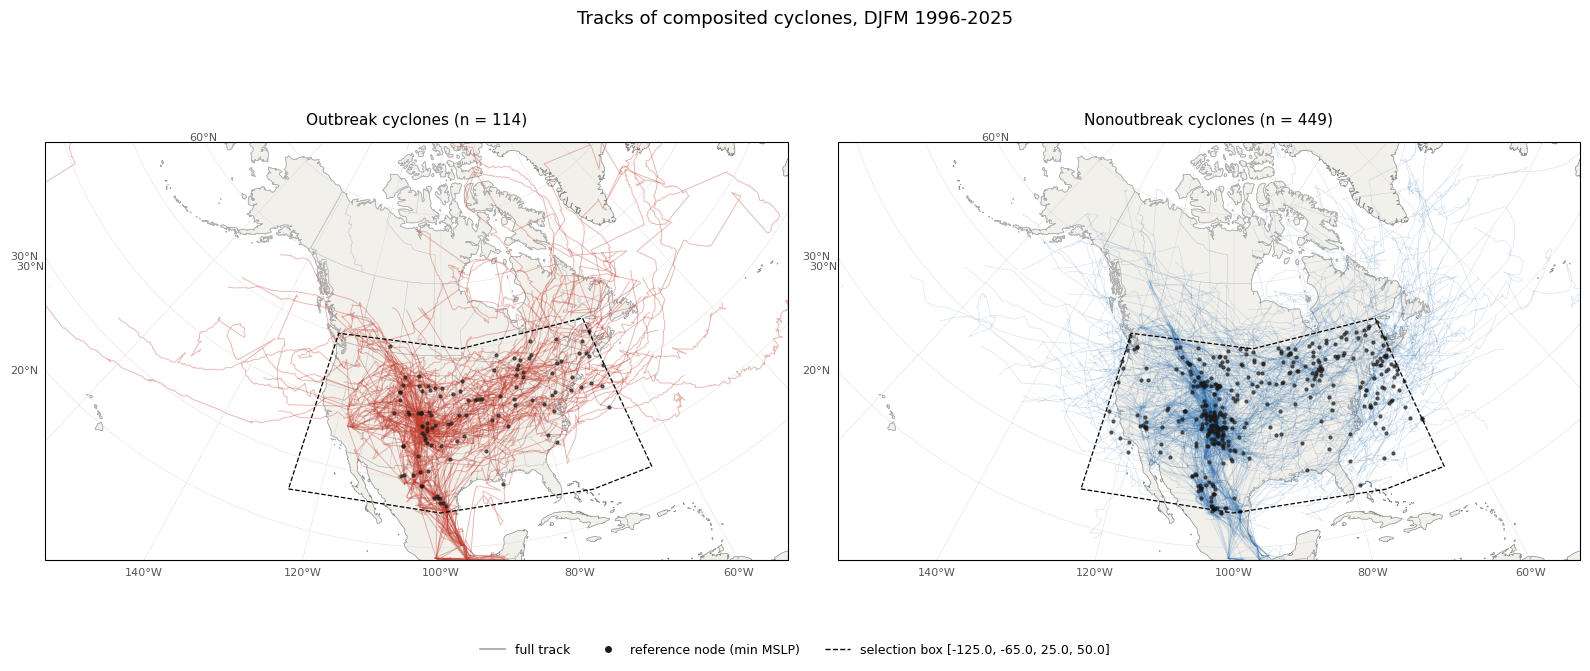

In [21]:
proj = ccrs.LambertConformal(central_longitude=-100, central_latitude=45,
                             standard_parallels=(30, 60))
fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw={"projection": proj})

plot_track_map(axes[0], oc_tracks, picks_df[picks_df["is_oc"]], OC_COLOR,
               f"Outbreak cyclones (n = {len(oc_ids)})", alpha=0.35, lw=0.7)
## NOC is 4x the sample, so lighten the strokes to keep the density readable
plot_track_map(axes[1], noc_tracks, picks_df[~picks_df["is_oc"]], NOC_COLOR,
               f"Nonoutbreak cyclones (n = {len(noc_ids)})", alpha=0.18, lw=0.5)

handles = [Line2D([], [], color="#666", lw=1.2, alpha=0.6, label="full track"),
           Line2D([], [], color="#1a1a1a", marker="o", ls="none", ms=4,
                  label="reference node (min MSLP)"),
           Line2D([], [], color="k", lw=1.0, ls="--", label=f"selection box {CONUS_BOX}")]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, 0.04))
fig.suptitle("Tracks of composited cyclones, DJFM "
             f"{picks_df['season_year'].min():.0f}-{picks_df['season_year'].max():.0f}",
             fontsize=13)
fig.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.show()

## fig.savefig("Figs/composite_cyclone_tracks.png", dpi=200, bbox_inches="tight")

### Track density (KDE contours)

Same two samples, as kernel density estimates of the track positions instead of
individual tracks -- the ETC-density panels in Kiefer et al. (2026), which use
`sns.kdeplot` over cyclone center lon/lat with labeled contours.

/home1/lepique/miniforge3/envs/storm/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


/home1/lepique/miniforge3/envs/storm/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


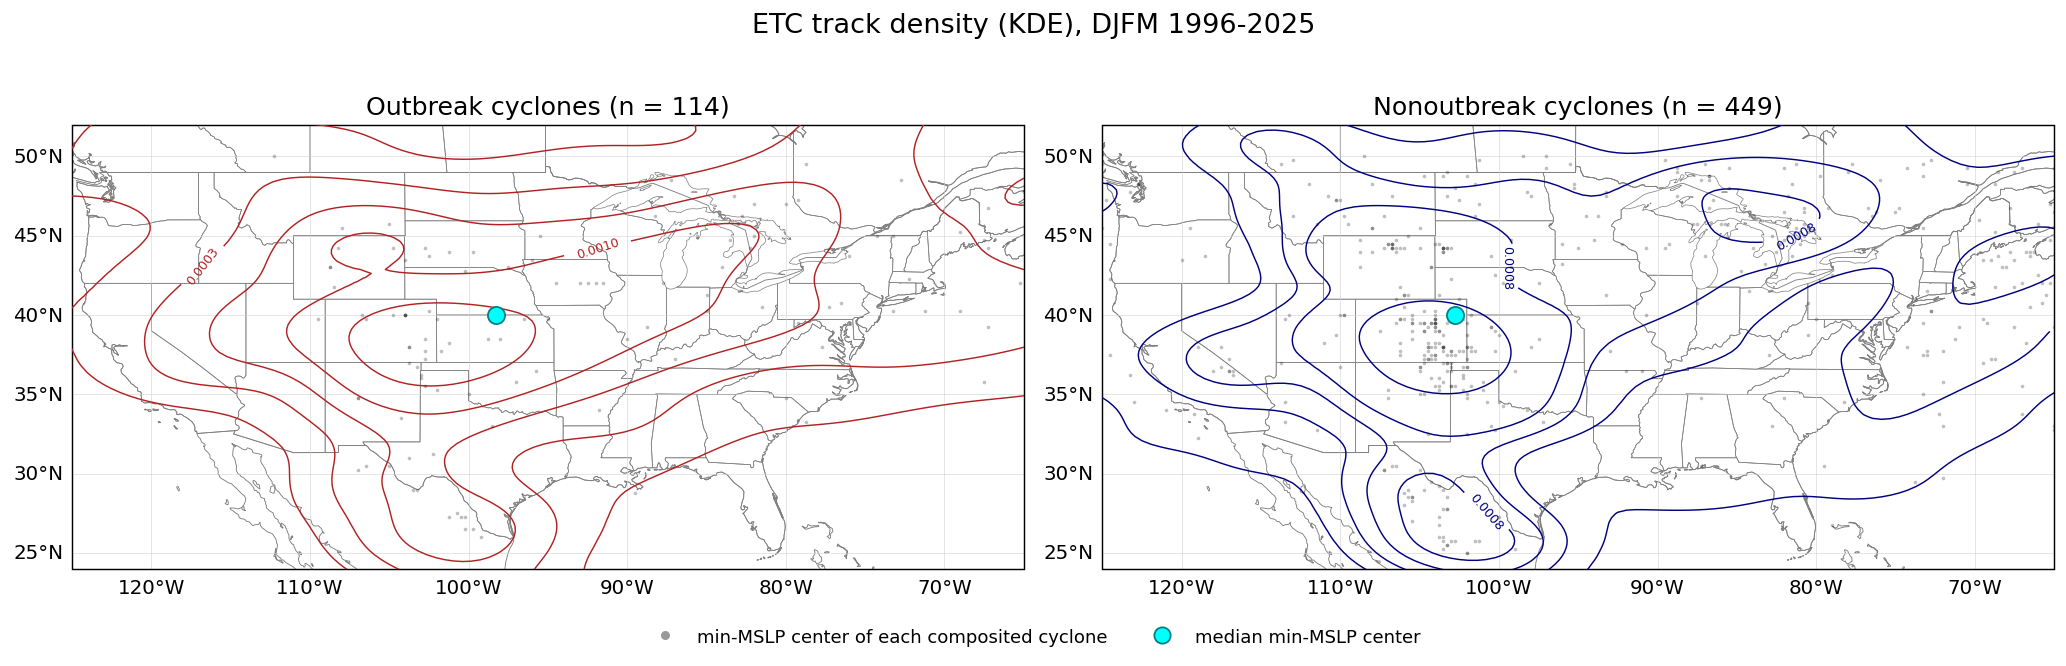

In [ ]:
## Track density of the composited cyclones, KDE contours (Kiefer et al. 2026 style).
## Requires nodes_df, picks_df from run_all() above, and wrap180() from the cell above.

## KDE is fit only to track points inside this box; without it the far-field
## Pacific/Arctic legs of the tracks inflate the bandwidth and smear the CONUS
## maximum. [lon_min, lon_max, lat_min, lat_max], degrees east in -180..180.
KDE_DOMAIN = [-140.0, -50.0, 20.0, 60.0]
MAP_EXTENT = [-125, -65, 24, 52]

## Iso-proportion levels: the contour drawn for 0.2 has 20% of the probability
## mass below it. Each panel's KDE integrates to 1, so the labeled density
## values (deg^-2) are directly comparable between OC and NOC.
LEVELS = np.arange(0.1, 1.0, 0.2)
FILL_LEVELS = np.append(LEVELS, 1.0)

## False -> each hourly node counts once, i.e. classic "system-hours" track
## density, which favors long-lived / slow-moving cyclones. True -> each
## cyclone contributes weight 1 spread over its own track.
EQUAL_WEIGHT_PER_CYCLONE = True

def track_points(ids):
    """Track nodes of the given cyclones, wrapped to -180..180 and clipped to KDE_DOMAIN."""
    d = nodes_df[nodes_df["track_id"].isin(ids)][["track_id", "lon", "lat"]].copy()
    d["lon"] = wrap180(d["lon"].values)
    d = d[d["lon"].between(KDE_DOMAIN[0], KDE_DOMAIN[1])
          & d["lat"].between(KDE_DOMAIN[2], KDE_DOMAIN[3])].copy()
    d["w"] = (1.0 / d.groupby("track_id")["lon"].transform("size")
              if EQUAL_WEIGHT_PER_CYCLONE else 1.0)
    return d

def kde_map(ax, pts, refs, title, line_color, fill_cmap):
    ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="grey", zorder=2)
    ax.add_feature(cfeature.STATES, edgecolor="grey", linewidth=0.4, zorder=2)
    ax.add_feature(cfeature.BORDERS, edgecolor="grey", linewidth=0.5, zorder=2)

    gl = ax.gridlines(draw_labels=True, zorder=3, linewidth=0.3, color="#d0d0d0")
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = {"size": 11}
    gl.ylabel_style = {"size": 11}

    ## shaded density + labeled contours of the same KDE
    # sns.kdeplot(x=pts["lon"], y=pts["lat"], weights=pts["w"], ax=ax,
    #             transform=ccrs.PlateCarree(), fill=True, levels=FILL_LEVELS,
    #             cmap=fill_cmap, alpha=0.75, zorder=1)
    sns.kdeplot(x=pts["lon"], y=pts["lat"], #weights=pts["w"], 
                ax=ax,
                transform=ccrs.PlateCarree(), levels=LEVELS,
                colors=[line_color], linewidths=0.8, zorder=4)
    
    # sns.kdeplot(x=pts["lon"], y=pts["lat"], weights=pts["w"], ax=ax,
    #         transform=ccrs.PlateCarree(), levels=5, cmap=plt.cm.YlOrRd, zorder=4)
    
    for coll in ax.collections:
        if isinstance(coll, mcontour.QuadContourSet) and not coll.filled:
            plt.clabel(coll, coll.levels[1::2], inline=1, fontsize=7,
                       colors=line_color, fmt="%1.4f")

    ## the min-MSLP nodes the composites are centered on, and their median
    ax.scatter(wrap180(refs["lon"].values), refs["lat"].values, s=4, c="k",
               alpha=0.25, linewidth=0, transform=ccrs.PlateCarree(), zorder=5)
    ax.scatter(np.median(wrap180(refs["lon"].values)), refs["lat"].median(),
               marker="o", s=90, c="cyan", edgecolors="teal", zorder=6,
               transform=ccrs.PlateCarree())
    ax.set_title(title, fontsize=14)

oc_pts  = track_points(picks_df.loc[picks_df["is_oc"], "track_id"])
noc_pts = track_points(picks_df.loc[~picks_df["is_oc"], "track_id"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5.0), dpi=130,
                         subplot_kw={"projection": ccrs.PlateCarree()})
kde_map(axes[0], oc_pts, picks_df[picks_df["is_oc"]],
        f"Outbreak cyclones (n = {int(picks_df['is_oc'].sum())})", "firebrick",
        ListedColormap(plt.cm.Reds(np.linspace(0.05, 0.75, 256))))
kde_map(axes[1], noc_pts, picks_df[~picks_df["is_oc"]],
        f"Nonoutbreak cyclones (n = {int((~picks_df['is_oc']).sum())})", "navy",
        ListedColormap(plt.cm.Blues(np.linspace(0.05, 0.75, 256))))

handles = [Line2D([], [], marker="o", ls="none", ms=5, mfc="k", mec="none", alpha=0.4,
                  label="min-MSLP center of each composited cyclone"),
           Line2D([], [], marker="o", ls="none", ms=9, mfc="cyan", mec="teal",
                  label="median min-MSLP center")]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("ETC track density (KDE), DJFM "
             f"{picks_df['season_year'].min():.0f}-{picks_df['season_year'].max():.0f}",
             fontsize=15)
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

## fig.savefig("Figs/composite_cyclone_track_density.png", dpi=300, bbox_inches="tight")

## Plotting ETC location at core ONSET and PEAK times:

In [25]:
core_summary.columns

Index(['track_id', 'core_id', 'n_reports', 'n_tornado', 'n_hail', 'n_wind',
       't_start', 't_end', 'lat_min', 'lax_max', 'lon_min', 'lon_max',
       'duration_h', 'grid_points', 'density_ratio', 'season_year',
       'thr_reports', 'thr_density_ratio', 'kept', 'centroid_lat',
       'centroid_lon', 'onset_time', 'peak_time', 'peak_n_reports',
       'time_min_msl', 'onset_h_from_min_msl', 'peak_h_from_min_msl'],
      dtype='object')

In [81]:
## kde_core_sumamry.csv has onset/peak times per outbreak core. ETC center position
## comes from the master nodefile (nodes_df) matched by track_iud. 

MAP_EXTENT = [-125, -65, 24, 52]
LEVELS = np.arange(0.1, 1.0, 0.1)
FILL_LEVELS = np.append(LEVELS, 1.0)

def positions_at(cores, nodes_df, time_col):
    """ETC center (lon, lat) for each core at time_col, from the corresponding node."""
    c = (cores[['track_id', time_col]].dropna()
         .rename(columns={time_col: "ref_time"}).reset_index(drop=True))
    c['ref_time'] = pd.to_datetime(c['ref_time'], utc=True)
    c['row'] = c.index
    m = c.merge(nodes_df[['track_id','datetime','lat','lon']], on='track_id', how='left')
    m['dt'] = (m['datetime'] - m['ref_time']).abs()
    out = m.loc[m.groupby('row')['dt'].idxmin()].copy()
    out['lon'] = wrap180(out['lon'].values)

    return out[['track_id','ref_time','lon','lat','dt']]

In [98]:
core_summary

,track_id,core_id,n_reports,n_tornado,n_hail,n_wind,t_start,t_end,lat_min,lax_max,...,thr_density_ratio,kept,centroid_lat,centroid_lon,onset_time,peak_time,peak_n_reports,time_min_msl,onset_h_from_min_msl,peak_h_from_min_msl
0,25,25_1g0,271,23,32,216,1996-01-18 00:00:00+00:00,1996-01-19 02:00:00+00:00,30.250,43.3000,...,0.031657,True,36.166605,-91.123137,1996-01-18 00:00:00+00:00,1996-01-18 16:00:00+00:00,29,1996-01-21 00:00:00+00:00,-72.0,-56.0
1,25,25_1g1,85,1,1,83,1996-01-19 06:00:00+00:00,1996-01-19 22:00:00+00:00,34.620,43.7800,...,0.031657,True,38.142941,-77.120471,1996-01-19 06:00:00+00:00,1996-01-19 16:00:00+00:00,12,1996-01-21 00:00:00+00:00,-42.0,-32.0
2,28,28_0,50,2,13,35,1996-01-26 13:00:00+00:00,1996-01-27 12:00:00+00:00,30.230,34.3000,...,0.031657,True,31.963400,-87.189000,1996-01-26 13:00:00+00:00,1996-01-27 00:00:00+00:00,8,1996-01-20 02:00:00+00:00,155.0,166.0
3,54,54_1g2,84,0,64,20,1996-02-27 15:00:00+00:00,1996-02-28 02:00:00+00:00,32.120,40.5500,...,0.031657,True,35.580238,-91.026310,1996-02-27 15:00:00+00:00,1996-02-27 19:00:00+00:00,14,1996-03-01 09:00:00+00:00,-66.0,-62.0
4,60,60_1g0,171,11,107,53,1996-03-05 18:00:00+00:00,1996-03-06 12:00:00+00:00,29.830,38.3700,...,0.031657,True,34.999298,-91.348947,1996-03-05 18:00:00+00:00,1996-03-06 04:00:00+00:00,28,1996-03-04 23:00:00+00:00,19.0,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,6109,6109_0g1,506,21,59,426,2025-03-16 03:00:00+00:00,2025-03-17 04:00:00+00:00,29.820,44.3300,...,0.040183,True,39.327536,-79.758995,2025-03-16 03:00:00+00:00,2025-03-16 16:00:00+00:00,134,2025-03-17 17:00:00+00:00,-38.0,-25.0
328,6111,6111_1,206,16,43,147,2025-03-19 07:00:00+00:00,2025-03-20 03:00:00+00:00,35.993,42.5300,...,0.040183,True,40.001778,-87.383061,2025-03-19 07:00:00+00:00,2025-03-19 21:00:00+00:00,42,2025-03-19 04:00:00+00:00,3.0,17.0
329,6113,6113_1,168,2,130,36,2025-03-23 21:00:00+00:00,2025-03-24 15:00:00+00:00,29.280,37.0739,...,0.040183,True,31.931806,-93.555014,2025-03-23 21:00:00+00:00,2025-03-23 23:00:00+00:00,35,2025-03-24 14:00:00+00:00,-17.0,-15.0
330,6117,6117_4g0,70,1,49,20,2025-03-30 00:00:00+00:00,2025-03-30 08:00:00+00:00,31.180,41.6000,...,0.040183,True,34.925389,-97.082104,2025-03-30 00:00:00+00:00,2025-03-30 02:00:00+00:00,19,2025-03-31 20:00:00+00:00,-44.0,-42.0


In [99]:
cores = core_summary[core_summary['kept']]
non_cores = core_summary[core_summary['kept'] == False]
onset_pos = positions_at(cores, nodes_df, 'onset_time')
peak_pos = positions_at(cores, nodes_df, 'peak_time')
min_msl_pos = positions_at(cores, nodes_df, 'time_min_msl')
min_msl_pos_nc = positions_at(non_cores, nodes_df, 'time_min_msl')


In [87]:
def kde_map(ax, pts, title, line_color, fill_cmap):
    ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="grey", zorder=2)
    ax.add_feature(cfeature.STATES, edgecolor="grey", linewidth=0.4, zorder=2)
    ax.add_feature(cfeature.BORDERS, edgecolor="grey", linewidth=0.5, zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, zorder=3, color='#d0d0d0')
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = {"size": 11}
    gl.ylabel_style = {"size": 11}

    sns.kdeplot(x=pts['lon'], y=pts['lat'], ax=ax, transform=ccrs.PlateCarree(),
                fill=True, levels=FILL_LEVELS, cmap=fill_cmap, alpha=0.75, zorder=1)

    sns.kdeplot(x=pts['lon'], y=pts['lat'], ax=ax, transform=ccrs.PlateCarree(),
                levels=LEVELS, colors=[line_color], linewidths=0.8, zorder=4) 
    for coll in ax.collections:
        if isinstance(coll, mcontour.QuadContourSet) and not coll.filled:
            plt.clabel(coll, coll.levels[1::2], inline=1, fontsize=7,
                       colors=line_color, fmt="%1.4f")

    ax.scatter(pts['lon'], pts['lat'], s=6, c="k", alpha=0.3, linewidth=0, 
               transform=ccrs.PlateCarree(), zorder=5)
    ax.scatter(pts['lon'].median(), pts['lat'].median(), marker="o", s=90,
               c="cyan", edgecolors="teal", zorder=6, transform=ccrs.PlateCarree())
    ax.set_title(f"{title} (n={len(pts)})", fontsize=14)

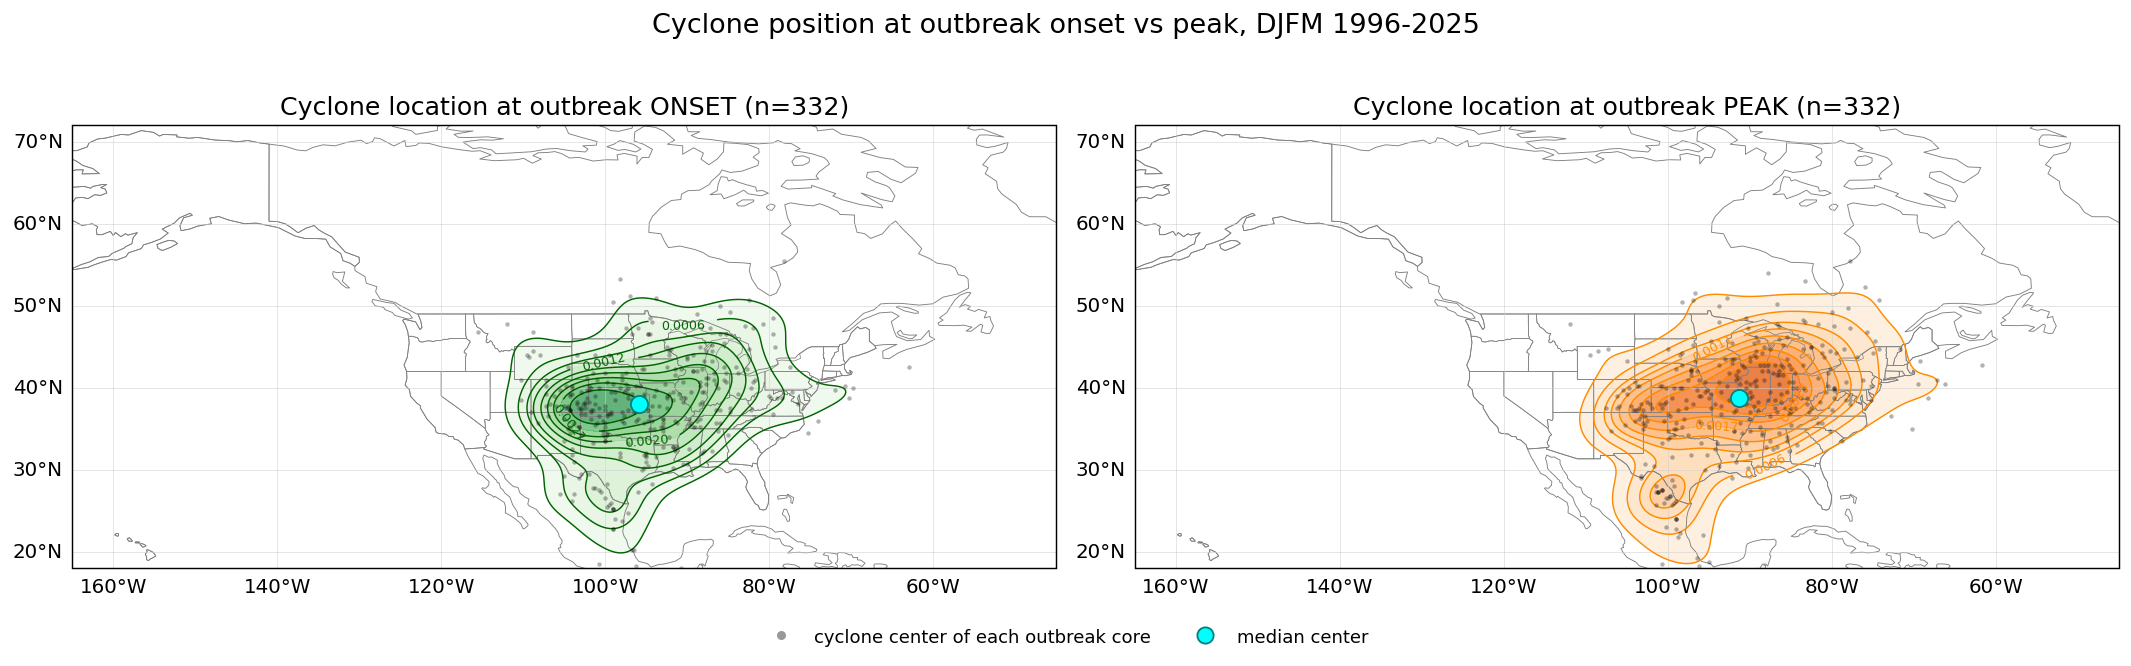

In [96]:
fig, axes = plt.subplots(1,2, figsize=(16.5, 5.0), dpi=130,
                         subplot_kw={"projection": ccrs.PlateCarree()})
kde_map(ax=axes[0], pts=onset_pos, title="Cyclone location at outbreak ONSET", line_color="darkgreen",
        fill_cmap=ListedColormap(plt.cm.Greens(np.linspace(0.05, 0.75, 256))))
kde_map(axes[1], peak_pos, "Cyclone location at outbreak PEAK", "darkorange",
        ListedColormap(plt.cm.Oranges(np.linspace(0.05, 0.75, 256))))

handles = [Line2D([], [], marker="o", ls="none", ms=5, mfc="k", mec="none", alpha=0.4,
                  label="cyclone center of each outbreak core"),
           Line2D([], [], marker="o", ls="none", ms=9, mfc="cyan", mec="teal",
                  label="median center")]

fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Cyclone position at outbreak onset vs peak, DJFM "
             f"{cores['season_year'].min():.0f}-{cores['season_year'].max():.0f}",
             fontsize=15)

fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

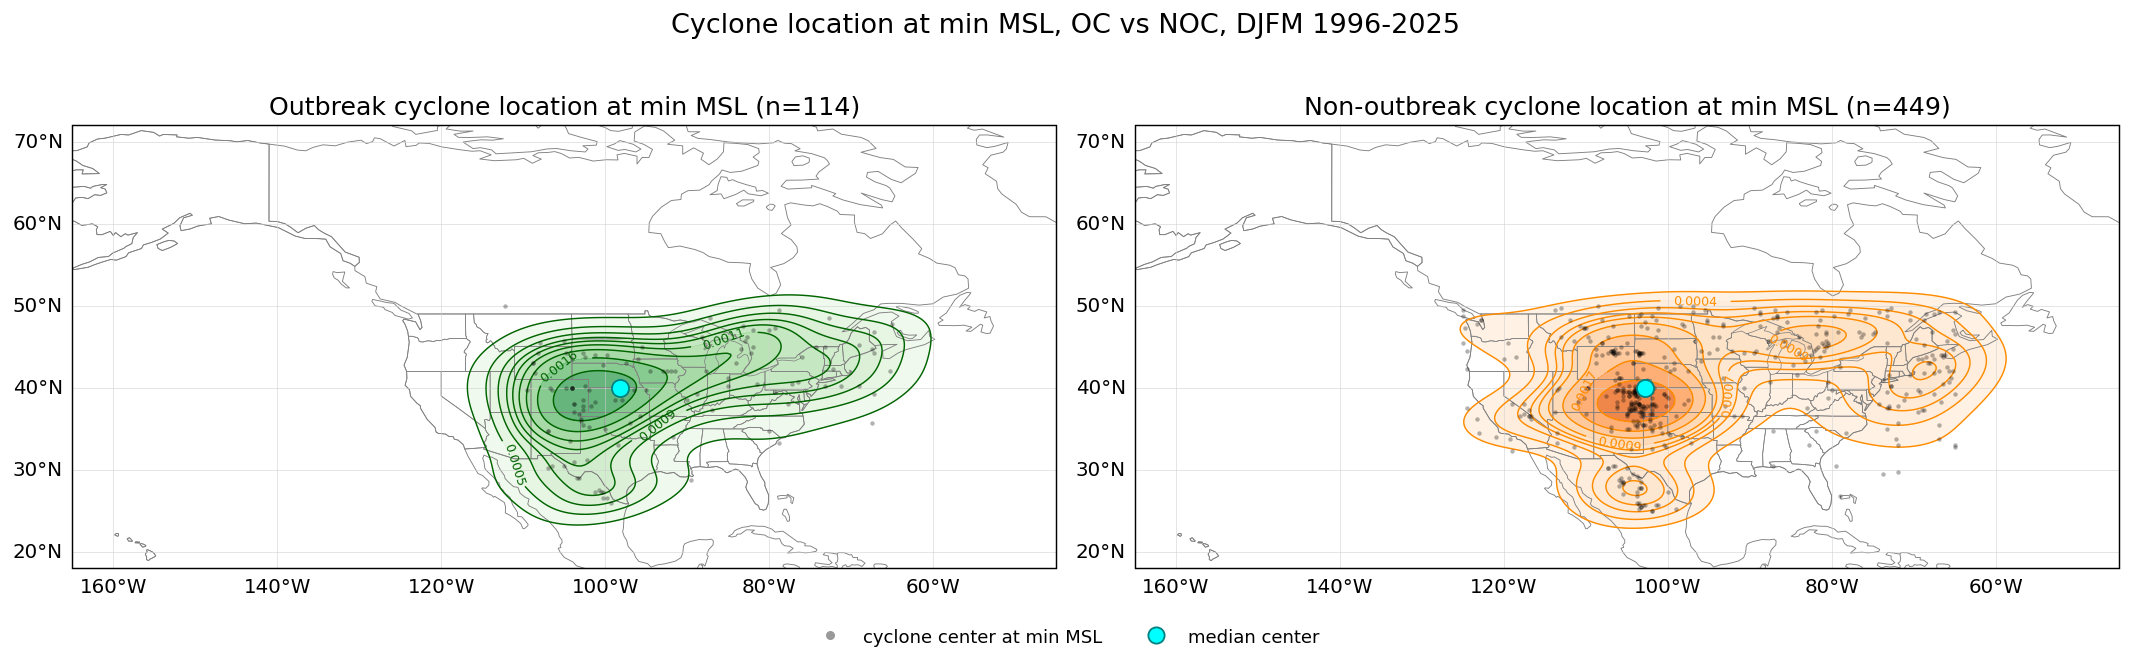

In [103]:
oc_min_msl  = picks_df.loc[picks_df["is_oc"], ["track_id", "lon", "lat"]].copy()
oc_min_msl["lon"] = wrap180(oc_min_msl["lon"].values)
noc_min_msl = picks_df.loc[~picks_df["is_oc"], ["track_id", "lon", "lat"]].copy()
noc_min_msl["lon"] = wrap180(noc_min_msl["lon"].values)

fig, axes = plt.subplots(1,2, figsize=(16.5, 5.0), dpi=130,
                         subplot_kw={"projection": ccrs.PlateCarree()})
kde_map(ax=axes[0], pts=oc_min_msl, title="Outbreak cyclone location at min MSL", line_color="darkgreen",
        fill_cmap=ListedColormap(plt.cm.Greens(np.linspace(0.05, 0.75, 64))))
kde_map(axes[1], noc_min_msl, "Non-outbreak cyclone location at min MSL", "darkorange",
        ListedColormap(plt.cm.Oranges(np.linspace(0.05, 0.75, 64))))

handles = [Line2D([], [], marker="o", ls="none", ms=5, mfc="k", mec="none", alpha=0.4,
                  label="cyclone center at min MSL"),
           Line2D([], [], marker="o", ls="none", ms=9, mfc="cyan", mec="teal",
                  label="median center")]

fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Cyclone location at min MSL, OC vs NOC, DJFM "
             f"{picks_df['season_year'].min():.0f}-{picks_df['season_year'].max():.0f}",
             fontsize=15)

fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Use python script (@download_era5_composite.py) to download the corresponding ERA5 data to input into NodeFileCompose to generate composites

use python script 

## Plotting Composites at time of min msl (filtered so that the time is over CONUS)

data_vars:
    sfc:

    
        - msl
        - cape
        - t2m
        - d2m
        - sp
        - tcwv
    plev:
        - t
        - q
        - r
        - u
        - v
        - z
        - vo
    derived variables:
        - 0-6km shear
        - 0-3km shear
        - 0-1km shear
        - 850 hPa theta e 
    


### MSL

In [3]:
ds_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_msl.nc", decode_times=False)
ds_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_msl.nc", decode_times=False)

In [12]:
ds_oc

<xarray.Dataset> Size: 3MB
Dimensions:      (snapshot: 114, y: 80, x: 80)
Coordinates:
  * y            (y) float64 640B -39.5 -38.5 -37.5 -36.5 ... 37.5 38.5 39.5
  * x            (x) float64 640B -39.5 -38.5 -37.5 -36.5 ... 37.5 38.5 39.5
Dimensions without coordinates: snapshot
Data variables:
    snap_pathid  (snapshot) int32 456B ...
    snap_lon     (snapshot) float64 912B ...
    snap_lat     (snapshot) float64 912B ...
    snap_time    (snapshot) int64 912B ...
    snap_msl     (snapshot, y, x) float32 3MB ...
    msl          (y, x) float32 26kB ...

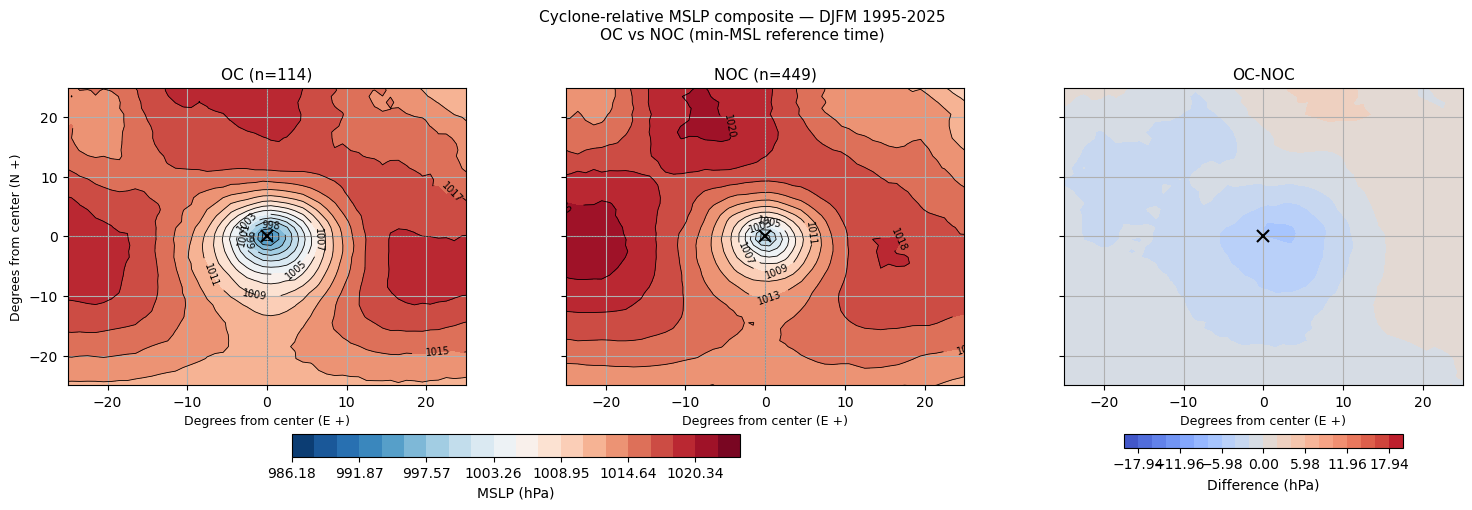

In [15]:
msl_oc  = ds_oc["msl"]  / 100   # Pa -> hPa
msl_noc = ds_noc["msl"] / 100
diff = msl_oc - msl_noc

# Shared contour levels across both panels for direct comparability
vmin = min(np.nanmin(msl_oc.values), np.nanmin(msl_noc.values))
vmax = max(np.nanmax(msl_oc.values), np.nanmax(msl_noc.values))
levels = np.linspace(vmin, vmax, 21)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

cf1 = axes[0].contourf(
        ds_oc["x"], ds_oc["y"], msl_oc,
        levels=levels, cmap="RdBu_r",
    )
cs1 = axes[0].contour(
        ds_oc["x"], ds_oc["y"], msl_oc,
        levels=levels, colors="k", linewidths=0.6,
    )

axes[0].clabel(cs1, inline=True, fontsize=7, fmt="%.0f")
axes[0].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].set_title("OC (n=114)", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[0].grid(True)

cf2 = axes[1].contourf(
        ds_oc["x"], ds_oc["y"], msl_noc,
        levels=levels, cmap="RdBu_r",
    )
cs2 = axes[1].contour(
        ds_oc["x"], ds_oc["y"], msl_noc,
        levels=levels, colors="k", linewidths=0.6,
    )

axes[1].clabel(cs2, inline=True, fontsize=7, fmt="%.0f")
axes[1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].set_title("NOC (n=449)", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[1].grid(True)

# Make the difference colorbar centered at zero
absmax = np.nanmax(np.abs(diff.values))
diff_levels = np.linspace(-absmax, absmax, 21)

cf3 = axes[2].contourf(
        ds_oc["x"], ds_oc["y"], diff,
        levels=diff_levels, cmap="coolwarm",
    )

#axes[2].axhline(0, color="gray", linewidth=0.4, linestyle="--")
#axes[2].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[2].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[2].set_xlim(-25, 25)
axes[2].set_ylim(-25, 25)
axes[2].set_title("OC-NOC", fontsize=11)
axes[2].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[2].grid(True)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_label("MSLP (hPa)", fontsize=10)

cbar2 = fig.colorbar(cf3, ax=axes[2], orientation="horizontal", pad=0.12, shrink=0.7)
cbar2.set_label("Difference (hPa)", fontsize=10)

fig.suptitle("Cyclone-relative MSLP composite — DJFM 1995-2025\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.01)

plt.show()

In [3]:
## So that MSL contours are on all plots:
msl_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_msl.nc",  decode_times=False)["msl"] / 100
msl_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_msl.nc", decode_times=False)["msl"] / 100

# Shared contour levels so the two panels' pressure fields are directly
# comparable -- matplotlib's auto-levels would otherwise pick a different
# spacing for OC (deeper low) than for NOC, making the two hard to compare.
mslp_vmin = min(float(msl_oc.min()), float(msl_noc.min()))
mslp_vmax = max(float(msl_oc.max()), float(msl_noc.max()))
mslp_levels = np.arange(np.floor(mslp_vmin / 4) * 4, np.ceil(mslp_vmax / 4) * 4 + 1, 4)

### 2m Temperature

#### Statistical significance: permutation test (after Tochimoto & Niino 2016)

Reusable helper; used below for 2-m temperature and later for the other variables.

In [15]:
## Permutation significance test for OC vs NOC composite differences,
## following Tochimoto & Niino (2016, MWR). Reusable across variables.
def perm_test_diff_means(oc_stack, noc_stack, n_resamples=5000, seed=1, min_count=10):
    """Grid-point permutation test on the OC-NOC difference of means.

    Pools the two per-cyclone snapshot stacks (snap_<var> from the composite
    files), then on each iteration randomly relabels ``n_oc`` of the pooled
    cyclones as pseudo-OC and recomputes the difference field. Whole cyclones
    are resampled together (one shared permutation for the entire grid), so the
    spatial covariance of the fields is preserved. This is the "means of two
    distributions are different" test TN2016 cite from Efron & Tibshirani (1993).

    NaNs -- grid points a cyclone's box does not cover, because its center sat
    near the edge of the ERA5 download domain -- are handled with nan-aware
    means: each grid point uses only the cyclones that actually cover it. The
    fast update D = S1/C1 - (T-S1)/(Ct-C1) sums only the n_oc sampled rows per
    iteration (~4 s at n_resamples=5000 for 114 vs 449).

    Parameters
    ----------
    oc_stack, noc_stack : (n, ny, nx) arrays, in the SAME units you plot.
    n_resamples : number of label permutations (bump to 10000 for a final fig).
    seed        : RNG seed for reproducibility.
    min_count   : grid points where either group has fewer than this many
                  contributing cyclones are masked (p = NaN); too poorly
                  sampled to test.

    Returns
    -------
    diff_obs : (ny, nx) observed OC-NOC difference of means (nan-aware).
    pval     : (ny, nx) two-sided permutation p-value, (count + 1)/(K + 1),
               with undersampled points set to NaN.
    """
    n_oc = oc_stack.shape[0]
    A = np.concatenate([oc_stack, noc_stack], axis=0).astype(np.float64)
    N, ny, nx = A.shape
    A = A.reshape(N, -1)

    valid = ~np.isnan(A)
    Az = np.where(valid, A, 0.0)      # values, NaN -> 0
    M  = valid.astype(np.float64)     # 1 where a cyclone covers this grid point
    T  = Az.sum(0)                    # total value sum per grid point
    Ct = M.sum(0)                     # total contributing count per grid point

    def diff(idx):
        S1 = Az[idx].sum(0); C1 = M[idx].sum(0)      # pseudo-OC
        S2 = T - S1;         C2 = Ct - C1            # pseudo-NOC
        with np.errstate(invalid="ignore", divide="ignore"):
            return S1 / C1 - S2 / C2

    diff_obs = diff(np.arange(n_oc))                 # first n_oc rows ARE the OC
    absobs = np.abs(diff_obs)

    rng = np.random.default_rng(seed)
    count = np.zeros(A.shape[1])
    for _ in range(n_resamples):
        idx = rng.choice(N, size=n_oc, replace=False)
        with np.errstate(invalid="ignore"):
            count += np.abs(diff(idx)) >= absobs

    pval = (count + 1) / (n_resamples + 1)

    C1o = M[:n_oc].sum(0); C2o = Ct - C1o            # observed contributing counts
    poor = (C1o < min_count) | (C2o < min_count)
    diff_obs = diff_obs.reshape(ny, nx)
    pval = pval.reshape(ny, nx)
    pval[poor.reshape(ny, nx)] = np.nan
    return diff_obs, pval


def bh_fdr(pval, alpha_fdr=0.05):
    """Benjamini-Hochberg false-discovery-rate control on a p-value field.

    perm_test_diff_means tests every grid point independently, so at raw
    p < 0.05 roughly 5% of the ~thousands of points would appear "significant"
    by chance alone (Wilks 2016, BAMS). BH-FDR instead finds a single p
    threshold p* such that declaring all points with p <= p* significant keeps
    the EXPECTED fraction of false positives among them at or below alpha_fdr.
    NaN points (undersampled, already masked by perm_test_diff_means) are
    excluded from the procedure.

    Procedure: sort the m valid p-values ascending p(1)..p(m); find the largest
    k with p(k) <= (k/m)*alpha_fdr; the threshold is p* = p(k).

    Returns
    -------
    sig      : bool array, same shape as pval, True where p <= p* (field-
               significant). All False if nothing survives.
    p_thresh : the BH threshold p* (np.nan if nothing is significant).
    """
    p = pval.ravel()
    ok = ~np.isnan(p)
    pv = np.sort(p[ok])                       # ascending valid p-values
    m = pv.size
    if m == 0:
        return np.zeros(pval.shape, dtype=bool), np.nan
    below = pv <= (np.arange(1, m + 1) / m) * alpha_fdr
    if not below.any():
        return np.zeros(pval.shape, dtype=bool), np.nan
    p_thresh = pv[np.max(np.nonzero(below)[0])]   # p at the largest passing k
    sig = (pval <= p_thresh)                  # NaN <= x is False -> stays out
    return sig, p_thresh


# def plot_sig_panel(ax, x, y, pval, diff_obs, sig_fdr, diff_fmt="%.0f", p_thresh=None):
#     """OC-NOC significance panel. Shade the permutation p-value ONLY where it
#     survives FDR control (everything else left white), and overlay the OC-NOC
#     difference itself as labeled black contours. Returns the filled-contour
#     handle so the caller can attach a colorbar."""
#     p_show = np.where(sig_fdr, pval, np.nan)       # only FDR-significant points
#     p_levels = [0.0, 0.01, 0.05, 0.1]
#     p_colors = ["#7f0000", "#d7301f", "#fdae61"]   # p<0.01, 0.01-0.05, 0.05-0.1
#     cfp = ax.contourf(x, y, p_show, levels=p_levels, colors="#d7301f", extend="neither", alpha=0.7 )
#     dmax = np.nanmax(np.abs(diff_obs))
#     d_levels = MaxNLocator(nbins=10, symmetric=True).tick_values(-dmax, dmax)
#     d_levels = d_levels[d_levels != 0]             # drop the zero contour
#     cs = ax.contour(x, y, diff_obs, levels=d_levels, colors="k", linewidths=0.7)
#     ax.clabel(cs, inline=True, fontsize=7, fmt=diff_fmt)
#     ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
#     ax.set_xlim(-25, 25); ax.set_ylim(-25, 25); ax.grid(True)
#     ax.set_xlabel("Degrees from center (E +)", fontsize=9)
#     return cfp

SIG_COLOR = "#d7301f"
SIG_ALPHA = 0.55

def plot_sig_panel(ax, x, y, pval, diff_obs, sig_fdr, diff_fmt="%.1f", nbins=10):
    """OC-NOC panel: single-colour FDR-significant mask + Δ contours everywhere
    the test ran (significant or not)."""
    ## BH-FDR yields ONE threshold p*, so significance is binary -- a single
    ## shade. (The old 0.01/0.05/0.1 bands showed raw-p gradient among already-
    ## significant points; with p* < 0.01 here the upper two bands are empty.)
    ax.contourf(x, y, sig_fdr.astype(float), levels=[0.5, 1.5],
                colors=[SIG_COLOR], alpha=SIG_ALPHA)

    ## Contour every point that was TESTED, not just the significant ones.
    ## perm_test_diff_means NaNs `pval` where fewer than min_count cyclones
    ## cover a point but leaves `diff_obs` populated there; those domain-corner
    ## values would otherwise set dmax and make the interval far too coarse.
    diff_plot = np.where(np.isfinite(pval), diff_obs, np.nan)
    dmax = np.nanmax(np.abs(diff_plot))
    d_levels = MaxNLocator(nbins=nbins, symmetric=True).tick_values(-dmax, dmax)
    d_levels = d_levels[d_levels != 0]
    cs = ax.contour(x, y, diff_plot, levels=d_levels, colors="k", linewidths=0.7)
    ax.clabel(cs, inline=True, fontsize=7, fmt=diff_fmt)

    ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
    ax.set_xlim(-25, 25); ax.set_ylim(-25, 25); ax.grid(True)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)
    return cs


def add_sig_colorbar(fig, ax, p_thresh, alpha_fdr=0.05, **kw):
    """Single-swatch colorbar for the FDR mask, labelled with the BH threshold.

    Built from a standalone ScalarMappable rather than the contourf handle: a
    boolean field gives a degenerate mappable, and when nothing is significant
    contourf produces no filled region at all, so a handle-derived colorbar
    comes out blank or raises.
    """
    cmap = ListedColormap([SIG_COLOR])
    sm = ScalarMappable(cmap=cmap, norm=BoundaryNorm([0, 1], cmap.N))
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, orientation="horizontal", ticks=[0.5], **kw)
    label = ("none significant" if not np.isfinite(p_thresh)
             else f"p $\\leq$ {p_thresh:.4f}")
    cb.ax.set_xticklabels([label])
    cb.solids.set_alpha(SIG_ALPHA)
    cb.set_label(f"FDR-significant ($\\alpha$={alpha_fdr})", fontsize=10)
    return cb


In [7]:
ds_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_t2m.nc", decode_times=False)
ds_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_t2m.nc", decode_times=False)

BH-FDR alpha=0.05: threshold p*=0.020, 2507/6157 tested grid points significant


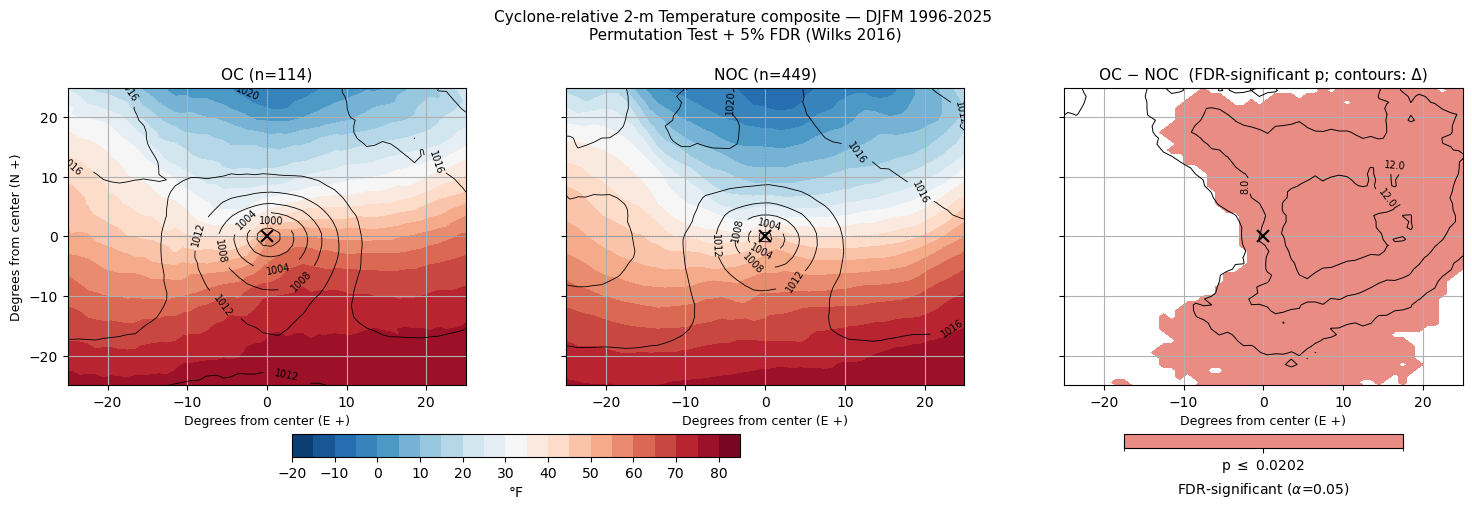

In [10]:
f_oc  = (ds_oc["t2m"] - 273.15) * 9/5 + 32
f_noc = (ds_noc["t2m"] - 273.15) * 9/5 + 32
snap_oc  = (ds_oc["snap_t2m"].values  - 273.15) * 9/5 + 32
snap_noc = (ds_noc["snap_t2m"].values - 273.15) * 9/5 + 32
diff_obs, pval = perm_test_diff_means(snap_oc, snap_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
n_tested = int(np.isfinite(pval).sum())
print(f"BH-FDR alpha=0.05: threshold p*={p_fdr:.3f}, "
      f"{int(np.nansum(sig_fdr))}/{n_tested} tested grid points significant")

# Shared contour levels across the OC/NOC panels for direct comparability
vmin = min(np.nanmin(f_oc.values), np.nanmin(f_noc.values))
vmax = max(np.nanmax(f_oc.values), np.nanmax(f_noc.values))
levels = np.arange(-20, 86, 5)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, f, msl, title in zip(axes[:2], [f_oc, f_noc], [msl_oc, msl_noc], ["OC (n=114)", "NOC (n=449)"]):
    cf = ax.contourf(ds_oc["x"], ds_oc["y"], f, levels=levels, cmap="RdBu_r")
    #cs = ax.contour(ds_oc["x"], ds_oc["y"], f, levels=levels, colors="k", linewidths=0.6)
    cs = ax.contour(ds_oc['x'], ds_oc['y'], msl, levels=mslp_levels, colors="k", linewidths=0.6)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
    ax.set_xlim(-25, 25); ax.set_ylim(-25, 25); ax.grid(True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)

# Panel 3: p-value shaded only where FDR-significant; contours = OC-NOC difference
plot_sig_panel(axes[2], ds_oc['x'], ds_oc['y'], pval, diff_obs, sig_fdr)
axes[2].set_title("OC − NOC  (FDR-significant p; contours: Δ)", fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)
fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_ticks(np.arange(-20, 86, 10))
cbar1.set_label("°F", fontsize=10)

add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

fig.suptitle("Cyclone-relative 2-m Temperature composite — DJFM 1996-2025\n Permutation Test + 5% FDR (Wilks 2016)", fontsize=11, y=1.01)
plt.show()


### 2m Dewpoint

In [49]:
ds_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_d2m.nc", decode_times=False)
ds_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_d2m.nc", decode_times=False)

BH-FDR alpha=0.05: threshold p*=0.014, 1710/6157 tested grid points significant


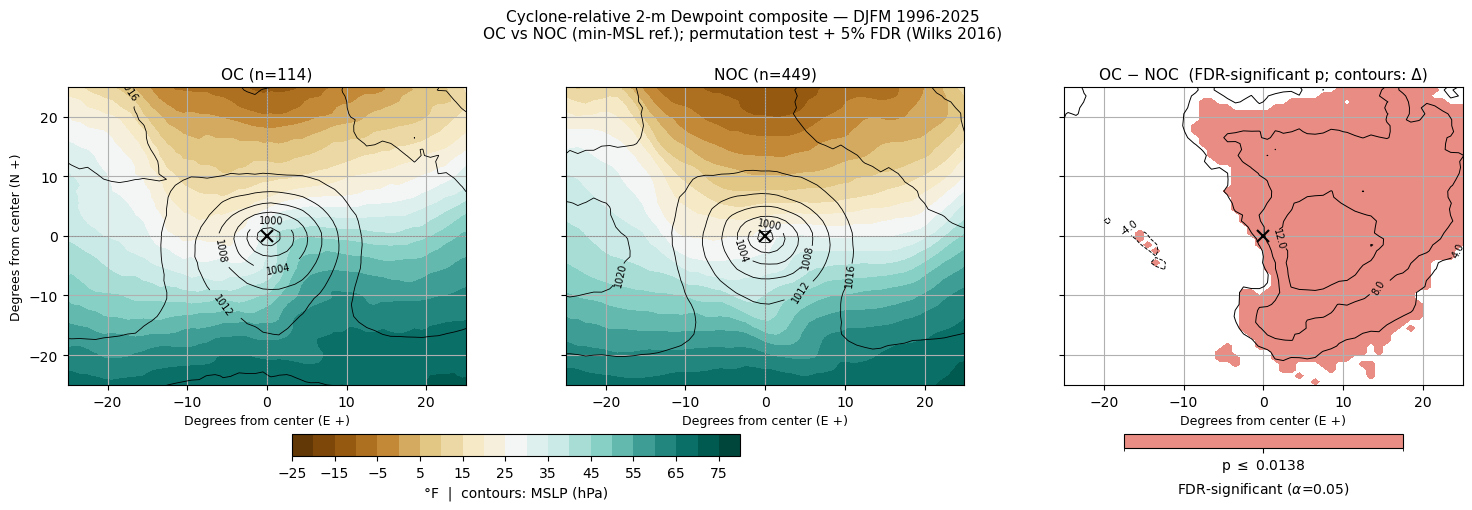

In [50]:
f_oc  = (ds_oc["d2m"] - 273.15) * 9/5 + 32
f_noc = (ds_noc["d2m"] - 273.15) * 9/5 + 32
snap_oc  = (ds_oc["snap_d2m"].values  - 273.15) * 9/5 + 32
snap_noc = (ds_noc["snap_d2m"].values - 273.15) * 9/5 + 32
diff_obs, pval = perm_test_diff_means(snap_oc, snap_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
n_tested = int(np.isfinite(pval).sum())
print(f"BH-FDR alpha=0.05: threshold p*={p_fdr:.3f}, "
      f"{int(np.nansum(sig_fdr))}/{n_tested} tested grid points significant")

# Shared contour levels across the OC/NOC panels for direct comparability
vmin = min(np.nanmin(f_oc.values), np.nanmin(f_noc.values))
vmax = max(np.nanmax(f_oc.values), np.nanmax(f_noc.values))
levels = np.arange(-25, 81, 5)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, f, msl, title in zip(axes[:2], [f_oc, f_noc], [msl_oc, msl_noc], ["OC (n=114)", "NOC (n=449)"]):
    cf = ax.contourf(ds_oc["x"], ds_oc["y"], f, levels=levels, cmap="BrBG")
    cs = ax.contour(ds_oc["x"], ds_oc["y"], msl, levels=mslp_levels, colors="k", linewidths=0.6)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
    ax.set_xlim(-25, 25); ax.set_ylim(-25, 25); ax.grid(True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)

# Panel 3: p-value shaded only where FDR-significant; contours = OC-NOC difference
plot_sig_panel(axes[2], ds_oc['x'], ds_oc['y'], pval, diff_obs, sig_fdr)
axes[2].set_title("OC − NOC  (FDR-significant p; contours: Δ)", fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)
fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_label("°F  |  contours: MSLP (hPa)", fontsize=10)
cbar1.set_ticks(np.arange(-25, 81, 10))
add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

fig.suptitle("Cyclone-relative 2-m Dewpoint composite — DJFM 1996-2025\nOC vs NOC (min-MSL ref.); permutation test + 5% FDR (Wilks 2016)", fontsize=11, y=1.01)
plt.show()


### Total Column Integrated Water Vapor:

In [71]:
ds_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_tcwv.nc", decode_times=False)
ds_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_tcwv.nc", decode_times=False)

BH-FDR alpha=0.05: threshold p*=0.009, 1116/6157 tested grid points significant


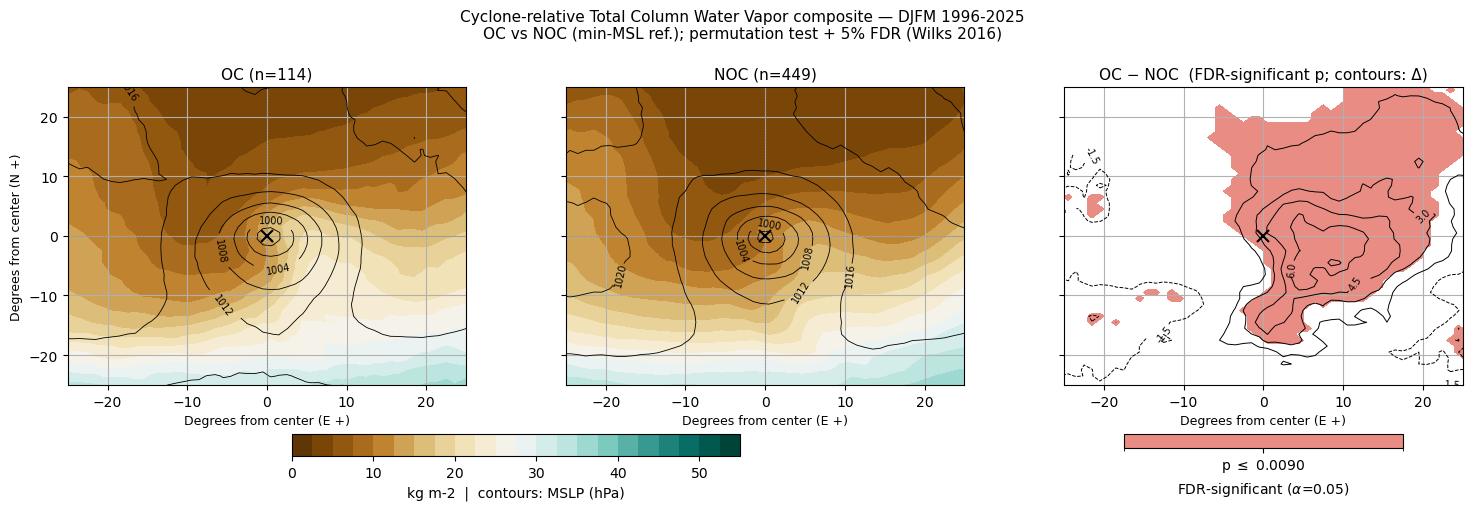

In [72]:
f_oc  = ds_oc["tcwv"]
f_noc = ds_noc["tcwv"]
snap_oc  = ds_oc["snap_tcwv"].values
snap_noc = ds_noc["snap_tcwv"].values
diff_obs, pval = perm_test_diff_means(snap_oc, snap_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
n_tested = int(np.isfinite(pval).sum())
print(f"BH-FDR alpha=0.05: threshold p*={p_fdr:.3f}, "
      f"{int(np.nansum(sig_fdr))}/{n_tested} tested grid points significant")

# Shared contour levels across the OC/NOC panels for direct comparability
vmin = min(np.nanmin(f_oc.values), np.nanmin(f_noc.values))
vmax = max(np.nanmax(f_oc.values), np.nanmax(f_noc.values))
levels = np.arange(0, 56, 2.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, f, msl, title in zip(axes[:2], [f_oc, f_noc], [msl_oc, msl_noc], ["OC (n=114)", "NOC (n=449)"]):
    cf = ax.contourf(ds_oc["x"], ds_oc["y"], f, levels=levels, cmap="BrBG")
    cs = ax.contour(ds_oc["x"], ds_oc["y"], msl, levels=mslp_levels, colors="k", linewidths=0.6)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
    ax.set_xlim(-25, 25); ax.set_ylim(-25, 25); ax.grid(True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)

# Panel 3: p-value shaded only where FDR-significant; contours = OC-NOC difference
plot_sig_panel(axes[2], ds_oc['x'], ds_oc['y'], pval, diff_obs, sig_fdr)
axes[2].set_title("OC − NOC  (FDR-significant p; contours: Δ)", fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)
fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_ticks(np.arange(0, 56, 10))
cbar1.set_label("kg m-2  |  contours: MSLP (hPa)", fontsize=10)
add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)


fig.suptitle("Cyclone-relative Total Column Water Vapor composite — DJFM 1996-2025\nOC vs NOC (min-MSL ref.); permutation test + 5% FDR (Wilks 2016)", fontsize=11, y=1.01)
plt.show()


### 850 hPa Winds

In [53]:
u_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_u850.nc", decode_times=False)["u(5)"]
v_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_v850.nc", decode_times=False)["v(5)"]
u_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_u850.nc", decode_times=False)["u(5)"]
v_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_v850.nc", decode_times=False)["v(5)"]

In [54]:
## So that 850 hPa geopotential height contours are on the wind plots:
z850_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_z850.nc",  decode_times=False)["z(5)"] / 9.80665
z850_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_z850.nc", decode_times=False)["z(5)"] / 9.80665

# Shared contour levels so the two panels' height fields are directly comparable
z850_vmin = min(float(z850_oc.min()), float(z850_noc.min()))
z850_vmax = max(float(z850_oc.max()), float(z850_noc.max()))
z850_levels = np.arange(np.floor(z850_vmin / 40) * 40, np.ceil(z850_vmax / 40) * 40 + 1, 40)


850 hPa speed BH-FDR 0.05: p*=0.004, 543/6157 significant


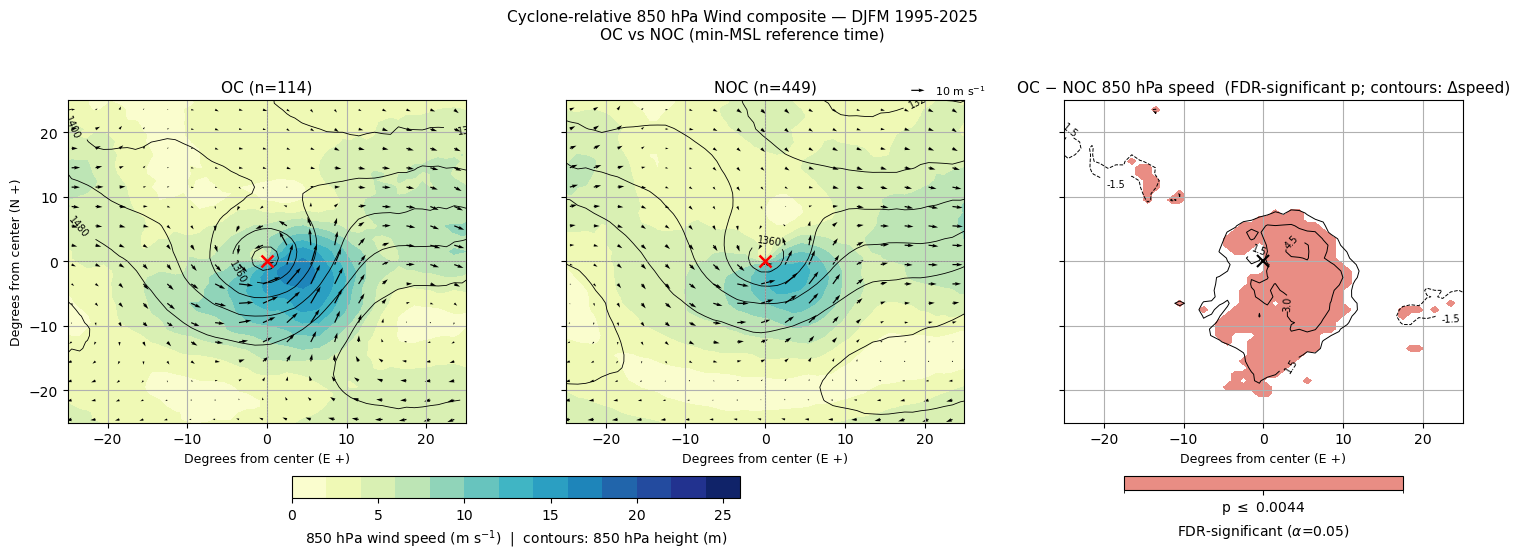

In [55]:
spd_oc  = np.sqrt(u_oc**2  + v_oc**2)
spd_noc = np.sqrt(u_noc**2 + v_noc**2)

# Per-cyclone wind-SPEED stacks for the significance test. This tests the mean
# of the per-cyclone speeds ("are the wind speeds different?"), which is not the
# same quantity as the speed of the mean wind vector shaded in panels 1-2.
su_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_u850.nc",  decode_times=False)["snap_u(5)"].values
sv_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_v850.nc",  decode_times=False)["snap_v(5)"].values
su_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_u850.nc", decode_times=False)["snap_u(5)"].values
sv_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_v850.nc", decode_times=False)["snap_v(5)"].values
snap_spd_oc  = np.sqrt(su_oc**2  + sv_oc**2)
snap_spd_noc = np.sqrt(su_noc**2 + sv_noc**2)
diff_obs, pval = perm_test_diff_means(snap_spd_oc, snap_spd_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
print(f"850 hPa speed BH-FDR 0.05: p*={p_fdr:.3f}, "
      f"{int(np.nansum(sig_fdr))}/{int(np.isfinite(pval).sum())} significant")

x = u_oc["x"]
y = u_oc["y"]

# shared speed scale across both panels for comparability
vmax = max(np.nanmax(spd_oc.values), np.nanmax(spd_noc.values))
levels = np.arange(0, 27, 2)

skip = 3
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5), sharey=True)

cf1 = axes[0].contourf(x, y, spd_oc, levels=levels, cmap="YlGnBu")
cs1 = axes[0].contour(x, y, z850_oc, levels=z850_levels, colors="k", linewidths=0.6)
axes[0].clabel(cs1, inline=True, fontsize=7, fmt="%.0f")
q1 = axes[0].quiver(
        x[::skip], y[::skip],
        u_oc[::skip, ::skip], v_oc[::skip, ::skip],
        scale=300, width=0.003, color="black",
    )

axes[0].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].plot(0, 0, "rx", markersize=9, markeredgewidth=1.8)
axes[0].grid(True)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].set_title("OC (n=114)", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)

cf2 = axes[1].contourf(x, y, spd_noc, levels=levels, cmap="YlGnBu")
cs2 = axes[1].contour(x, y, z850_noc, levels=z850_levels, colors="k", linewidths=0.6)
axes[1].clabel(cs2, inline=True, fontsize=7, fmt="%.0f")
q2 = axes[1].quiver(
        x[::skip], y[::skip],
        u_noc[::skip, ::skip], v_noc[::skip, ::skip],
        scale=300, width=0.003, color="black",
    )

axes[1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].plot(0, 0, "rx", markersize=9, markeredgewidth=1.8)
axes[1].grid(True)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].set_title("NOC (n=449)", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)

plot_sig_panel(axes[2], x, y, pval, diff_obs, sig_fdr)
axes[2].set_title("OC − NOC 850 hPa speed  (FDR-significant p; contours: Δspeed)", fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

axes[1].quiverkey(q2, 0.9, 1.03, 10, "10 m s$^{-1}$",
             labelpos="E", fontproperties={"size": 8})

fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_ticks(np.arange(0, 26, 5))
cbar1.set_label("850 hPa wind speed (m s$^{-1}$)  |  contours: 850 hPa height (m)", fontsize=10)

add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

fig.suptitle("Cyclone-relative 850 hPa Wind composite — DJFM 1995-2025\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.02)

plt.show()

850 hPa v BH-FDR 0.05: p*=0.0064, 798/6157 significant


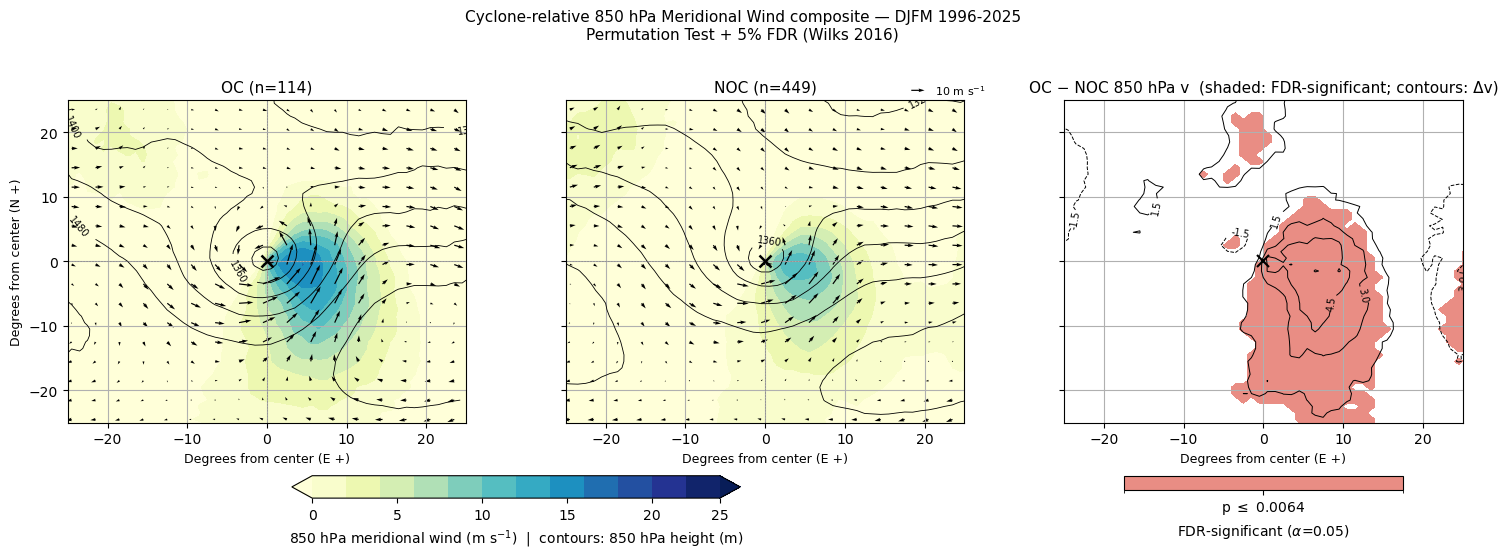

In [56]:
## Same as previous plot but just the meridional component.
## v is SIGNED (northerly flow is negative), so it gets a diverging colormap
## centred on zero -- the old levels started at 0 and clipped all the return flow.
v_ds_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_v850.nc",  decode_times=False)
v_ds_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_v850.nc", decode_times=False)

## Per-cyclone MERIDIONAL-wind stacks: this panel tests v itself (not speed),
## which is exactly the field shaded in panels 1-2.
snap_v_oc  = v_ds_oc["snap_v(5)"].values
snap_v_noc = v_ds_noc["snap_v(5)"].values
diff_obs, pval = perm_test_diff_means(snap_v_oc, snap_v_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
print(f"850 hPa v BH-FDR 0.05: p*={p_fdr:.4f}, "
      f"{int(np.nansum(sig_fdr))}/{int(np.isfinite(pval).sum())} significant")

n_oc, n_noc = snap_v_oc.shape[0], snap_v_noc.shape[0]
x = u_oc["x"]
y = u_oc["y"]

## symmetric, zero-centred levels so northerly/southerly read correctly
levels = np.arange(0, 26, 2)

skip = 3
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5), sharey=True)

for ax, u, v, z850, title in (
    (axes[0], u_oc,  v_oc,  z850_oc,  f"OC (n={n_oc})"),
    (axes[1], u_noc, v_noc, z850_noc, f"NOC (n={n_noc})"),
):
    cf = ax.contourf(x, y, v, levels=levels, cmap="YlGnBu", extend="both")
    cs = ax.contour(x, y, z850, levels=z850_levels, colors="k", linewidths=0.6)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    q = ax.quiver(x[::skip], y[::skip],
                  u[::skip, ::skip], v[::skip, ::skip],
                  scale=300, width=0.003, color="black")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "kx", markersize=9, markeredgewidth=1.8)
    ax.set_xlim(-25, 25); ax.set_ylim(-25, 25); ax.grid(True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)

axes[1].quiverkey(q, 0.9, 1.03, 10, "10 m s$^{-1}$",
                  labelpos="E", fontproperties={"size": 8})

plot_sig_panel(axes[2], x, y, pval, diff_obs, sig_fdr, diff_fmt="%.1f")
axes[2].set_title("OC − NOC 850 hPa v  (shaded: FDR-significant; contours: Δv)",
                  fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)
fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_ticks(np.arange(0, 26, 5))    
cbar1.set_label("850 hPa meridional wind (m s$^{-1}$)  |  contours: 850 hPa height (m)", fontsize=10)

add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

fig.suptitle("Cyclone-relative 850 hPa Meridional Wind composite — DJFM 1996-2025\n"
             "Permutation Test + 5% FDR (Wilks 2016)", fontsize=11, y=1.02)
plt.show()

### 500 hPa Heights and Vorticity

In [31]:
z_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_z500.nc", decode_times=False)['z(12)'] / 9.80665
z_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_z500.nc", decode_times=False)['z(12)'] / 9.80665
oc_vort = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_vo500.nc", decode_times=False)['vo(12)']
noc_vort = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_vo500.nc", decode_times=False)['vo(12)']

In [32]:
oc_vort

<xarray.DataArray 'vo(12)' (y: 80, x: 80)> Size: 26kB
[6400 values with dtype=float32]
Coordinates:
  * y        (y) float64 640B -39.5 -38.5 -37.5 -36.5 ... 36.5 37.5 38.5 39.5
  * x        (x) float64 640B -39.5 -38.5 -37.5 -36.5 ... 36.5 37.5 38.5 39.5

500 hPa height BH-FDR 0.05: p*=0.009, 1149/6157 significant


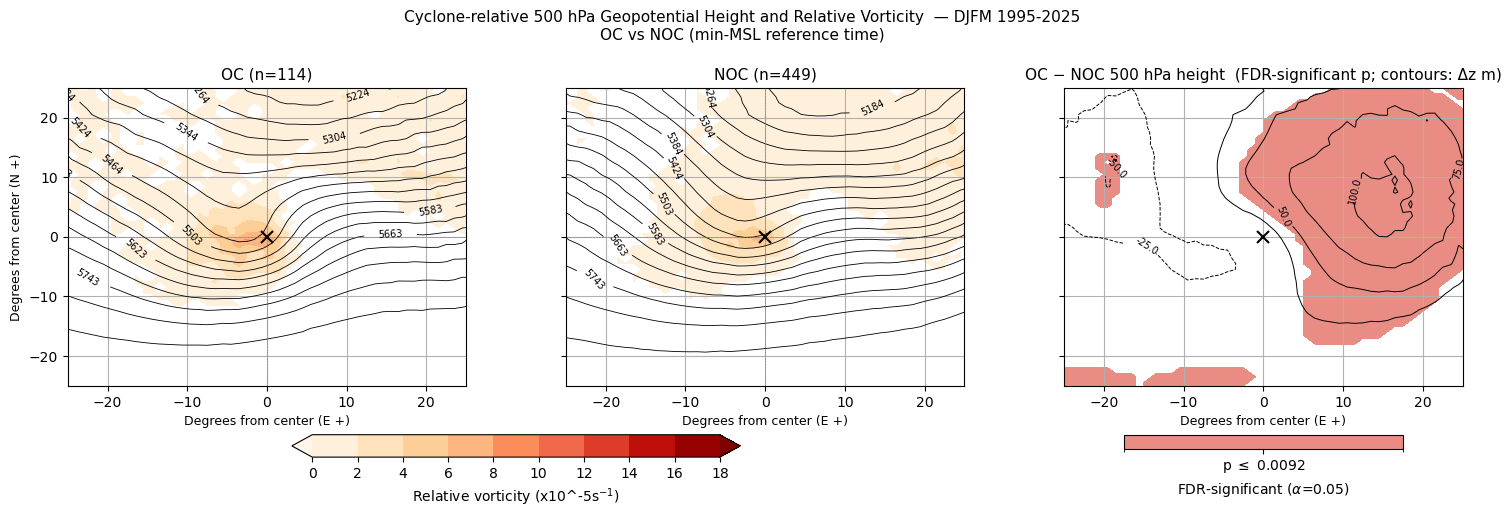

-7.7403617 17.365114
-4.322043 7.2178025


In [33]:
# Per-cyclone 500 hPa geopotential-HEIGHT stacks for the significance test.
sz_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_z500.nc",  decode_times=False)["snap_z(12)"].values / 9.80665
sz_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_z500.nc", decode_times=False)["snap_z(12)"].values / 9.80665
diff_obs, pval = perm_test_diff_means(sz_oc, sz_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
print(f"500 hPa height BH-FDR 0.05: p*={p_fdr:.3f}, "
      f"{int(np.nansum(sig_fdr))}/{int(np.isfinite(pval).sum())} significant")

# Shared contour levels across both panels for direct comparability
vmin = min(np.nanmin(z_oc.values), np.nanmin(z_noc.values))
vmax = max(np.nanmax(z_oc.values), np.nanmax(z_noc.values))
levels = np.linspace(vmin, vmax, 21)

pos_vort_oc = np.where(oc_vort.values > 0, oc_vort.values * 1e5, np.nan)
pos_vort_noc = np.where(noc_vort.values > 0, noc_vort.values * 1e5, np.nan)

#vort_vmin = min(np.nanmin(oc_vort.values), np.nanmin(noc_vort.values))
vort_vmax = max(np.nanmax(pos_vort_oc), np.nanmax(pos_vort_noc))
vort_levels = np.arange(0, vort_vmax+2, 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

cf1 = axes[0].contourf(z_oc["x"], z_oc["y"], pos_vort_oc, levels=vort_levels, cmap="OrRd", extend="both")
cs1 = axes[0].contour(z_oc["x"], z_oc["y"], z_oc, levels=levels, colors="k", linewidths=0.6)
axes[0].clabel(cs1, inline=True, fontsize=7, fmt="%.0f")
axes[0].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].grid(True)
axes[0].set_title("OC (n=114)", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)

cf2 = axes[1].contourf(z_noc["x"], z_noc["y"], pos_vort_noc, levels=vort_levels, cmap="OrRd", extend="both")
cs2 = axes[1].contour(z_noc["x"], z_noc["y"], z_noc, levels=levels, colors="k", linewidths=0.6)
axes[1].clabel(cs2, inline=True, fontsize=7, fmt="%.0f")
axes[1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].grid(True)
axes[1].set_title("NOC (n=449)", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)

plot_sig_panel(axes[2], x, y, pval, diff_obs, sig_fdr)
axes[2].set_title("OC − NOC 500 hPa height  (FDR-significant p; contours: Δz m)", fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_label("Relative vorticity (x10^-5s$^{-1}$)", fontsize=10)

add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

fig.suptitle("Cyclone-relative 500 hPa Geopotential Height and Relative Vorticity  — DJFM 1995-2025\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.01)

plt.show()
print(np.nanmin(oc_vort * 1e5), np.nanmax(oc_vort * 1e5))
print(np.nanmin(noc_vort * 1e5), np.nanmax(noc_vort * 1e5))

### 250 hPa Heights and Winds:

In [68]:
u_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_u250.nc", decode_times=False)['u(17)'] 
u_noc  = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_u250.nc", decode_times=False)['u(17)'] 

v_oc = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_v250.nc", decode_times=False)['v(17)']
v_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_v250.nc", decode_times=False)['v(17)']

z_oc = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_z250.nc", decode_times=False)['z(17)'] / 9.80665
z_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_z250.nc", decode_times=False)['z(17)'] / 9.80665

250 hPa speed BH-FDR 0.05: p*=0.007, 825/6157 significant


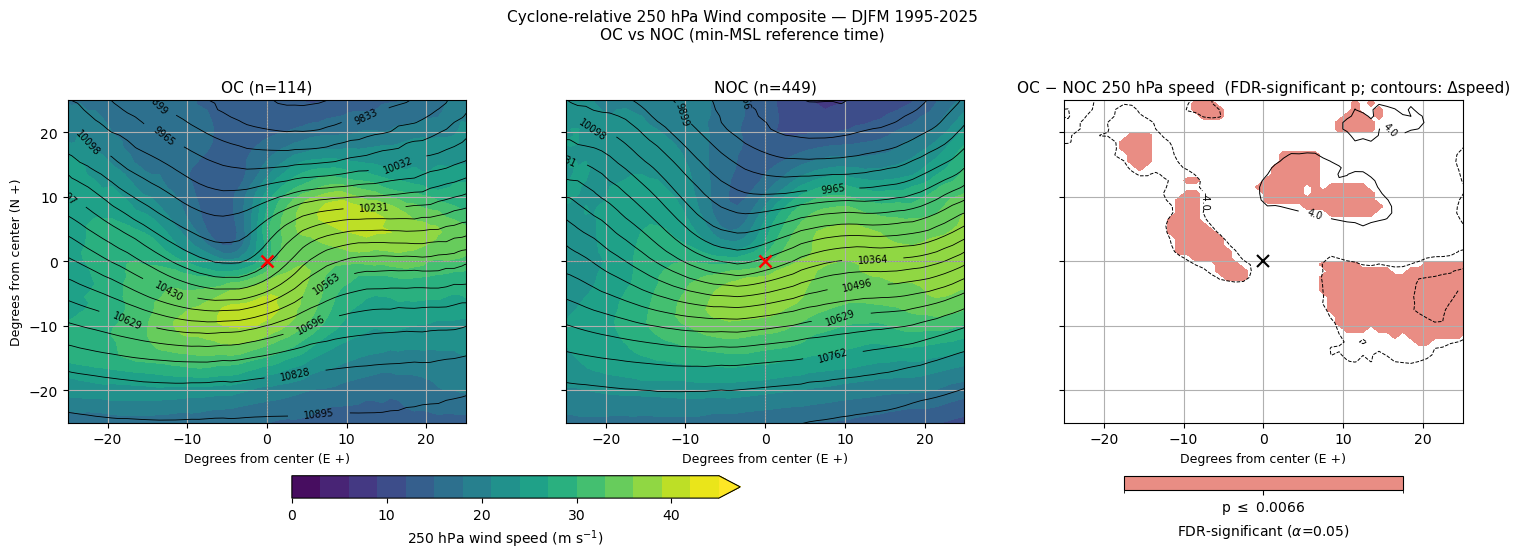

In [69]:
# Shared geopotential height contour levels across both panels for direct comparability
vmin_z = min(np.nanmin(z_oc.values), np.nanmin(z_noc.values))
vmax_z = max(np.nanmax(z_oc.values), np.nanmax(z_noc.values))
z_levels = np.linspace(vmin_z, vmax_z, 21)

spd_oc = np.sqrt(u_oc**2 + v_oc**2)
spd_noc = np.sqrt(u_noc**2 + v_noc**2)

# Per-cyclone wind-SPEED stacks for the significance test (mean of per-cyclone
# speeds, distinct from the speed of the mean vector shaded in panels 1-2).
su_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_u250.nc",  decode_times=False)["snap_u(17)"].values
sv_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_v250.nc",  decode_times=False)["snap_v(17)"].values
su_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_u250.nc", decode_times=False)["snap_u(17)"].values
sv_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_v250.nc", decode_times=False)["snap_v(17)"].values
snap_spd_oc  = np.sqrt(su_oc**2  + sv_oc**2)
snap_spd_noc = np.sqrt(su_noc**2 + sv_noc**2)
diff_obs, pval = perm_test_diff_means(snap_spd_oc, snap_spd_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
print(f"250 hPa speed BH-FDR 0.05: p*={p_fdr:.3f}, "
      f"{int(np.nansum(sig_fdr))}/{int(np.isfinite(pval).sum())} significant")

x = u_oc["x"]
y = u_oc["y"]

# Shared speed scale across both panels for comparability
vmax = max(np.nanmax(spd_oc.values), np.nanmax(spd_noc.values))
spd_levels = np.arange(0, 46, 3)

skip = 3

fig, axes = plt.subplots(1,3, figsize=(18,6.5), sharey=True)

cf1 = axes[0].contourf(spd_oc["x"], spd_oc["y"], spd_oc, levels=spd_levels, cmap="viridis", extend="max")
cs1 = axes[0].contour(z_oc["x"], z_oc["y"], z_oc, levels=z_levels, colors="k", linewidths=0.6)
axes[0].clabel(cs1, inline=True, fontsize=7, fmt="%.0f")
axes[0].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].plot(0, 0, "rx", markersize=9, markeredgewidth=1.8)
axes[0].grid(True)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].set_title("OC (n=114)", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)

cf2 = axes[1].contourf(spd_noc["x"], spd_noc["y"], spd_noc, levels=spd_levels, cmap="viridis", extend="max")
cs2 = axes[1].contour(z_noc["x"], z_noc["y"], z_noc, levels=z_levels, colors="k", linewidths=0.6)
axes[1].clabel(cs2, inline=True, fontsize=7, fmt="%.0f")
axes[1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].plot(0, 0, "rx", markersize=9, markeredgewidth=1.8)
axes[1].grid(True)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].set_title("NOC (n=449)", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)

plot_sig_panel(axes[2], x, y, pval, diff_obs, sig_fdr)
axes[2].set_title("OC − NOC 250 hPa speed  (FDR-significant p; contours: Δspeed)", fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_ticks(np.arange(0, 46, 10))
cbar1.set_label("250 hPa wind speed (m s$^{-1}$)", fontsize=10)

add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

fig.suptitle("Cyclone-relative 250 hPa Wind composite — DJFM 1995-2025\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.02)

plt.show()

#### CAPE

In [57]:
cape_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_cape.nc", decode_times=False)['cape']
cape_noc  = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_cape.nc", decode_times=False)['cape']

CAPE BH-FDR 0.05: p*=0.004, 482/6157 significant


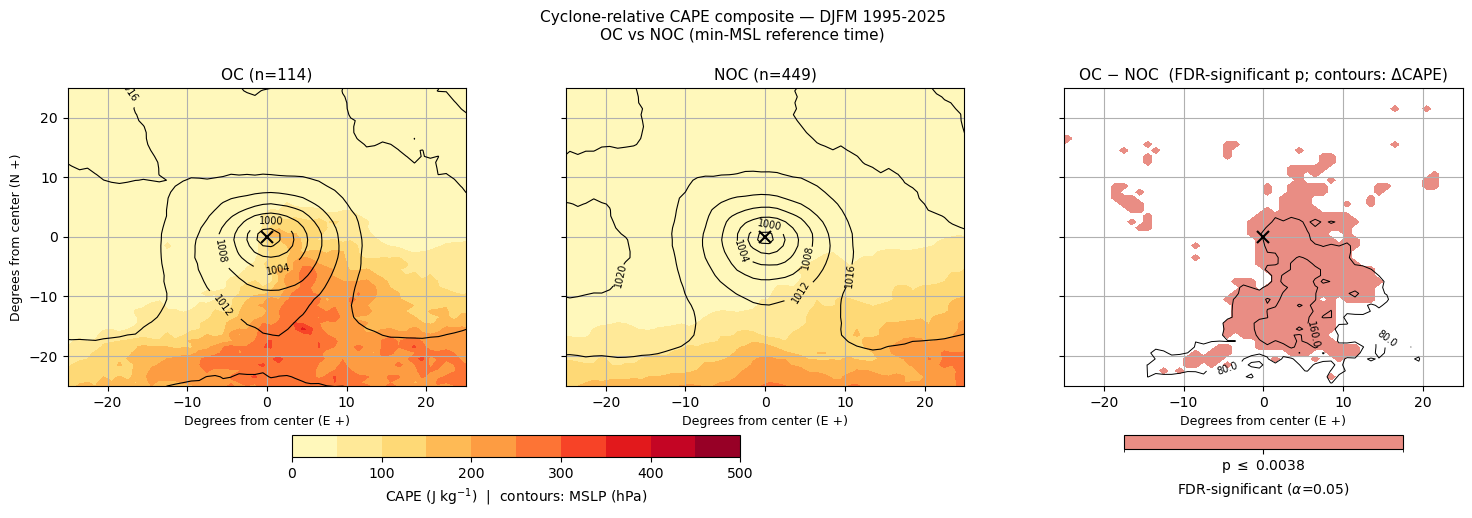

0.0 1090.3671
0.0 902.4354


In [58]:
vmin = min(np.nanmin(cape_oc.values), np.nanmin(cape_noc.values))
vmax = max(np.nanmax(cape_oc.values), np.nanmax(cape_noc.values))
levels = np.arange(0, 500+1, 50)

diff = cape_oc - cape_noc

# Per-cyclone CAPE stacks for the significance test.
snap_oc  = xr.open_dataset("/data1/lepique/composites_full_filtered/oc_min_msl_cape.nc",  decode_times=False)["snap_cape"].values
snap_noc = xr.open_dataset("/data1/lepique/composites_full_filtered/noc_min_msl_cape.nc", decode_times=False)["snap_cape"].values
diff_obs, pval = perm_test_diff_means(snap_oc, snap_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
print(f"CAPE BH-FDR 0.05: p*={p_fdr:.3f}, "
      f"{int(np.nansum(sig_fdr))}/{int(np.isfinite(pval).sum())} significant")

x = cape_oc['x']
y = cape_oc['y']

fig, axes = plt.subplots(1,3, figsize=(18,6), sharey=True)

cf1 = axes[0].contourf(x, y, cape_oc, levels=levels, cmap="YlOrRd")
cs1 = axes[0].contour(x, y, msl_oc, levels=mslp_levels, colors="k", linewidths=0.8)
axes[0].clabel(cs1, inline=True, fontsize=7, fmt="%.0f")
axes[0].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].grid(True)
axes[0].set_title("OC (n=114)", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)

cf2 = axes[1].contourf(x, y, cape_noc, levels=levels, cmap="YlOrRd")
cs2 = axes[1].contour(x, y, msl_noc, levels=mslp_levels, colors="k", linewidths=0.8)
axes[1].clabel(cs2, inline=True, fontsize=7, fmt="%.0f")
axes[1].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].grid(True)
axes[1].set_title("NOC (n=449)", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)

plot_sig_panel(axes[2], x, y, pval, diff_obs, sig_fdr)
axes[2].set_title("OC − NOC  (FDR-significant p; contours: ΔCAPE)", fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)
fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_label("CAPE (J kg$^{-1}$)  |  contours: MSLP (hPa)", fontsize=10)

add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

fig.suptitle("Cyclone-relative CAPE composite — DJFM 1995-2025\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.01)

plt.show()
print(np.nanmin(cape_oc), np.nanmax(cape_oc))
print(np.nanmin(cape_oc), np.nanmax(cape_noc))



#### Vertical wind shear composites (0-1, 0-3, 0-6 km)

Bulk shear = wind at the layer top minus the 10 m wind, with the layer top taken
in TRUE height above ground (`H_AGL = (z - z_sfc)/g`).

In [59]:
SHEAR_DIR = "/data1/lepique/composites_full_filtered"

def plot_shear_composite(tag, label, levels, n_resamples=5000, seed=1, skip=3, scale=None, key=10):
    def load(pop, var):
        return xr.open_dataset(f"{SHEAR_DIR}/{pop}_min_msl_{var}.nc",
                                decode_times=False)
    
    mag_oc, mag_noc = load("oc", tag)[tag], load("noc", tag)[tag]
    u_oc,    u_noc   = (load("oc",  f"{tag}_u")[f"{tag}_u"],
                        load("noc", f"{tag}_u")[f"{tag}_u"])
    v_oc,    v_noc   = (load("oc",  f"{tag}_v")[f"{tag}_v"],
                        load("noc", f"{tag}_v")[f"{tag}_v"])

    ## per-cyclone magnitude stacks -> permutation test and FDR control
    snap_oc = load("oc", tag)[f"snap_{tag}"].values
    snap_noc = load("noc", tag)[f"snap_{tag}"].values
    diff_obs, pval = perm_test_diff_means(snap_oc, snap_noc,
                                          n_resamples=n_resamples, seed=seed)
    sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
    print(f"{label} shear BH-FDR 0.05: p*={p_fdr:.3f}, "
          f"{int(np.nansum(sig_fdr))}/{int(np.isfinite(pval).sum())} significant")

    n_oc, n_noc = snap_oc.shape[0], snap_noc.shape[0]
    x,y = mag_oc["x"], mag_oc["y"]

    fig, axes = plt.subplots(1,3, figsize=(18,6.5), sharey=True)

    for ax, mag, u, v, msl, title in (
        (axes[0], mag_oc, u_oc, v_oc, msl_oc, f"OC (n={n_oc})"),
        (axes[1], mag_noc, u_noc, v_noc, msl_noc, f"OC (n={n_noc})"),
    ):
        cf = ax.contourf(x, y, mag, levels=levels, cmap="YlGnBu", extend="max")
        cs = ax.contour(x, y, msl, levels=mslp_levels, colors="k", linewidths=0.5)
        ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
        q = ax.quiver(x[::skip], y[::skip],
                      u[::skip, ::skip], v[::skip, ::skip],
                      scale=scale, width=0.0025, minlength=0, 
                      headwidth=2.5, headlength=3.5, headaxislength=3,
                      color="black")
        ax.plot(0, 0, "rx", markersize=9, markeredgewidth=1.8)
        ax.grid(True)
        ax.set_xlim(-25, 25)
        ax.set_ylim(-25, 25)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Degrees from center (E +)", fontsize=9)

    axes[1].quiverkey(q, 0.9, 1.03, 10, f"{key} m s$^{-1}$",
                      labelpos="E", fontproperties={"size": 8})
    
    plot_sig_panel(axes[2], x, y, pval, diff_obs, sig_fdr, nbins=14)

    axes[2].set_title(f"OC − NOC {label} shear  (shaded: FDR-significant; contours: Δshear)",
                      fontsize=11)

    axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)
    fig.subplots_adjust(bottom=0.2, wspace=0.25)

    cbar1 = fig.colorbar(cf, ax=axes[:2], orientation="horizontal",
                         pad=0.12, shrink=0.5)
    cbar1.set_label(f"{label} bulk wind shear (m s$^{{-1}}$)", fontsize=10)

    add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

    fig.suptitle(
        f"Cyclone-relative {label} bulk wind shear composite — DJFM 1995-2025\n"
        f"OC vs NOC (min-MSL reference time)", fontsize=11, y=1.02)
    plt.show()


0-6 km shear BH-FDR 0.05: p*=0.004, 502/6157 significant


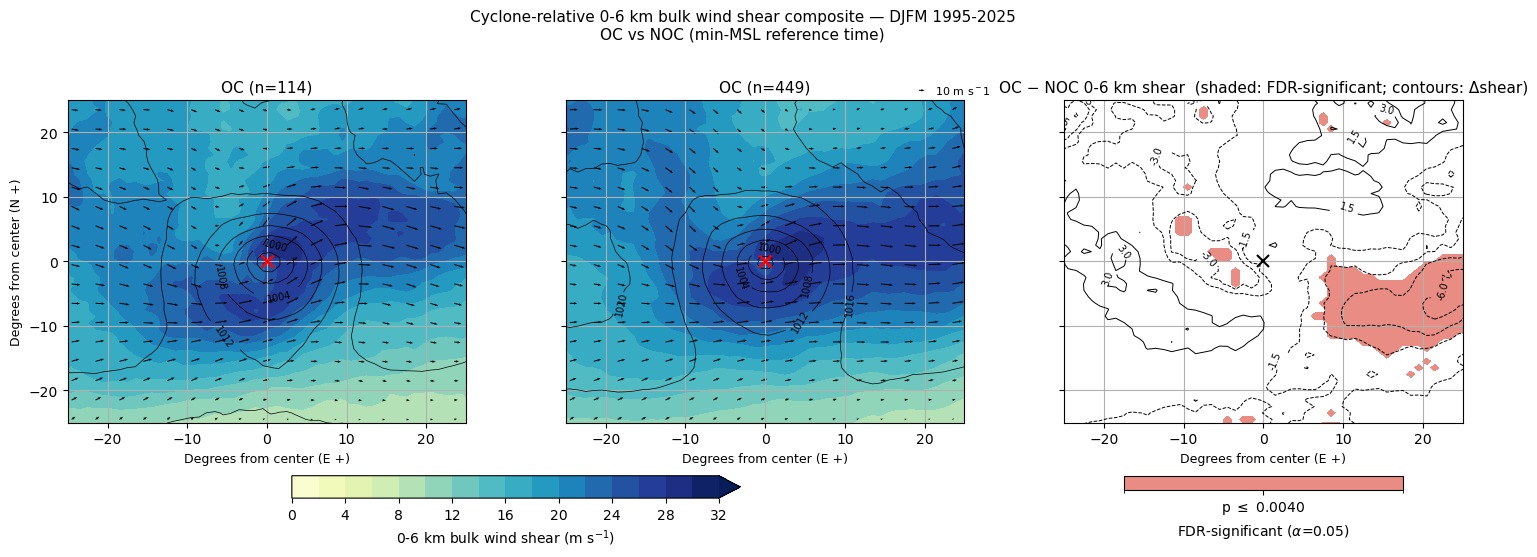

In [60]:
##### 0-6 km bulk shear
plot_shear_composite("shear06", "0-6 km", levels=np.arange(0, 32 + 1, 2), scale=700)

0-3 km shear BH-FDR 0.05: p*=0.008, 1051/6157 significant


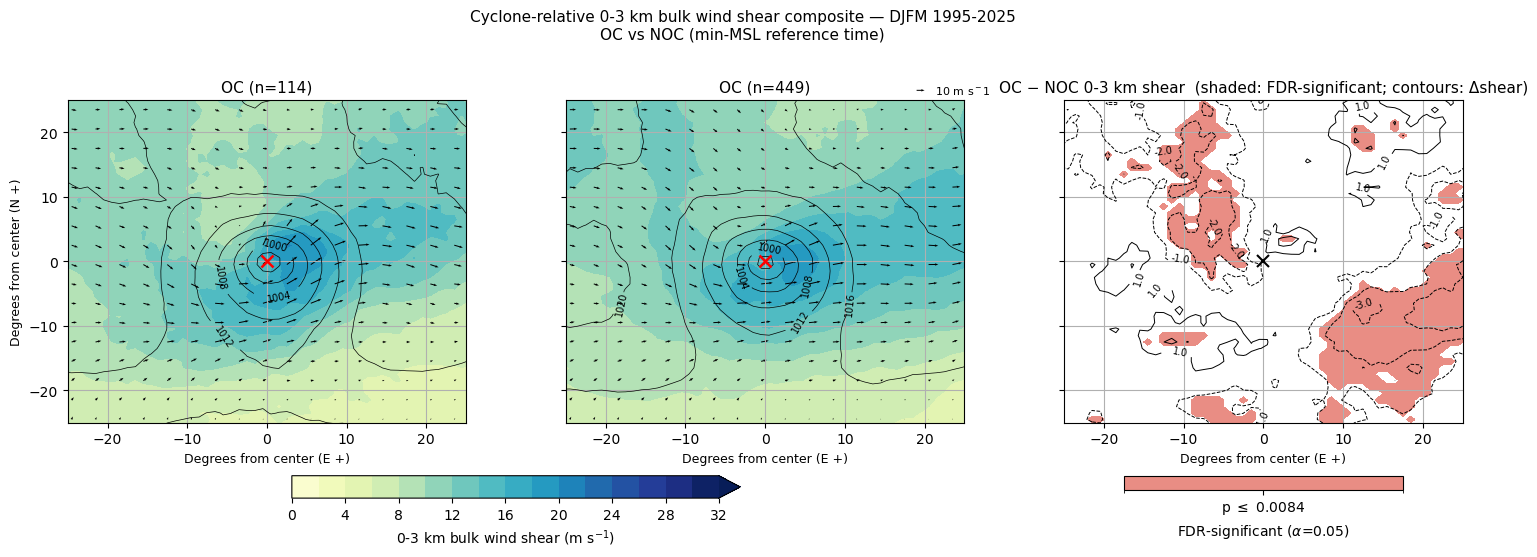

In [61]:
plot_shear_composite("shear03", "0-3 km", levels=np.arange(0, 32 + 1, 2), scale=500)

0-1 km shear BH-FDR 0.05: p*=0.002, 296/6157 significant


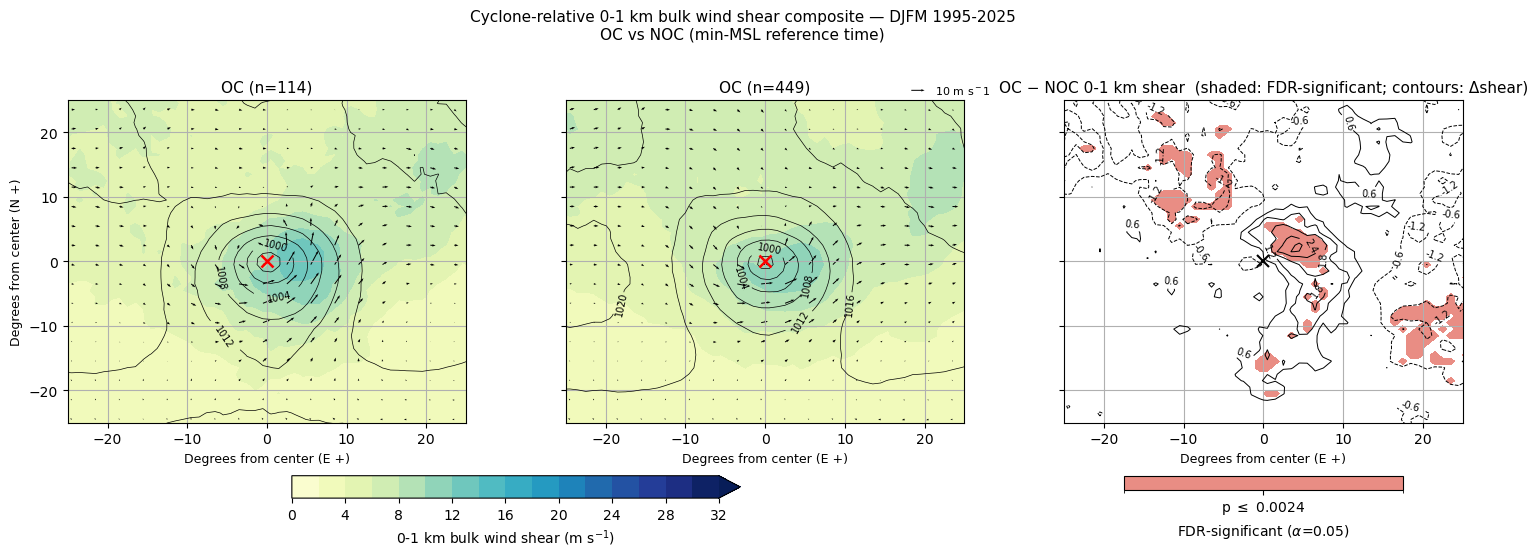

In [62]:
plot_shear_composite("shear01", "0-1 km", levels=np.arange(0, 32 + 1, 2), scale=300)

## Plotting composites at the time of min msl but accounting for differences in min msl

In [63]:
## min msl for contouring
ds_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_msl.nc", decode_times=False)
ds_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_msl.nc", decode_times=False)
msl_oc  = ds_oc["msl"]  / 100   # Pa -> hPa
msl_noc = ds_noc["msl"] / 100

# Shared contour levels so the two panels' pressure fields are directly comparable
mslp_vmin = min(float(msl_oc.min()), float(msl_noc.min()))
mslp_vmax = max(float(msl_oc.max()), float(msl_noc.max()))
mslp_levels = np.arange(np.floor(mslp_vmin / 4) * 4, np.ceil(mslp_vmax / 4) * 4 + 1, 4)

In [22]:
ds_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_t2m.nc", decode_times=False)
ds_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_t2m.nc", decode_times=False)

BH-FDR alpha=0.05: threshold p*=0.025, 3140/6157 tested grid points significant


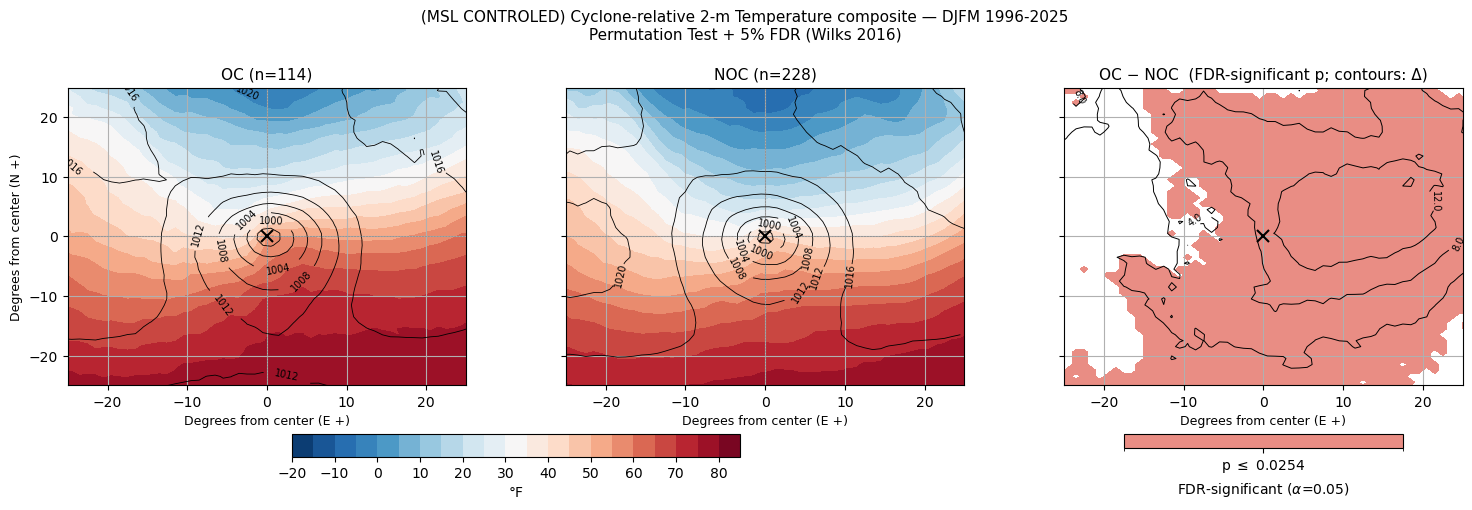

In [25]:
f_oc  = (ds_oc["t2m"] - 273.15) * 9/5 + 32
f_noc = (ds_noc["t2m"] - 273.15) * 9/5 + 32
snap_oc  = (ds_oc["snap_t2m"].values  - 273.15) * 9/5 + 32
snap_noc = (ds_noc["snap_t2m"].values - 273.15) * 9/5 + 32
diff_obs, pval = perm_test_diff_means(snap_oc, snap_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
n_tested = int(np.isfinite(pval).sum())
print(f"BH-FDR alpha=0.05: threshold p*={p_fdr:.3f}, "
      f"{int(np.nansum(sig_fdr))}/{n_tested} tested grid points significant")

# Shared contour levels across the OC/NOC panels for direct comparability
vmin = min(np.nanmin(f_oc.values), np.nanmin(f_noc.values))
vmax = max(np.nanmax(f_oc.values), np.nanmax(f_noc.values))
levels = np.arange(-20, 86, 5)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, f, msl, title in zip(axes[:2], [f_oc, f_noc], [msl_oc, msl_noc], ["OC (n=114)", "NOC (n=228)"]):
    cf = ax.contourf(ds_oc["x"], ds_oc["y"], f, levels=levels, cmap="RdBu_r")
    #cs = ax.contour(ds_oc["x"], ds_oc["y"], f, levels=levels, colors="k", linewidths=0.6)
    cs = ax.contour(ds_oc['x'], ds_oc['y'], msl, levels=mslp_levels, colors="k", linewidths=0.6)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
    ax.set_xlim(-25, 25); ax.set_ylim(-25, 25); ax.grid(True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)

# Panel 3: p-value shaded only where FDR-significant; contours = OC-NOC difference
plot_sig_panel(axes[2], ds_oc['x'], ds_oc['y'], pval, diff_obs, sig_fdr)
axes[2].set_title("OC − NOC  (FDR-significant p; contours: Δ)", fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)
fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_ticks(np.arange(-20, 86, 10))
cbar1.set_label("°F", fontsize=10)

add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

fig.suptitle(" (MSL CONTROLED) Cyclone-relative 2-m Temperature composite — DJFM 1996-2025\n Permutation Test + 5% FDR (Wilks 2016)", fontsize=11, y=1.01)
plt.show()

In [64]:
ds_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_d2m.nc", decode_times=False)
ds_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_d2m.nc", decode_times=False)

BH-FDR alpha=0.05: threshold p*=0.017, 2150/6157 tested grid points significant


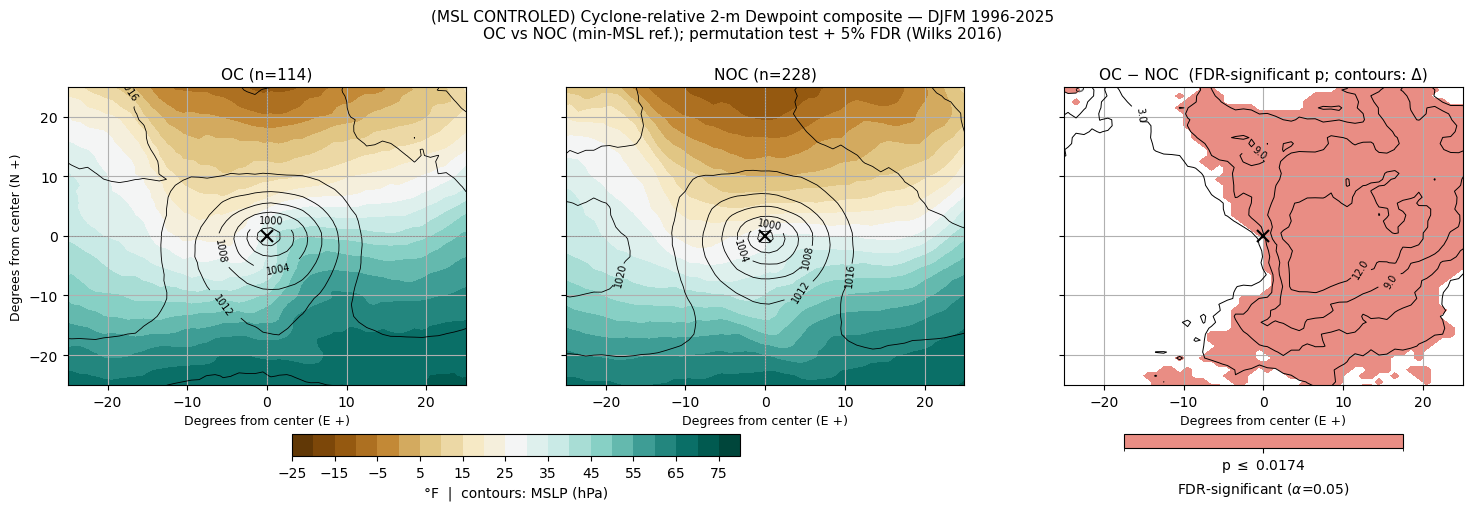

In [65]:
f_oc  = (ds_oc["d2m"] - 273.15) * 9/5 + 32
f_noc = (ds_noc["d2m"] - 273.15) * 9/5 + 32
snap_oc  = (ds_oc["snap_d2m"].values  - 273.15) * 9/5 + 32
snap_noc = (ds_noc["snap_d2m"].values - 273.15) * 9/5 + 32
diff_obs, pval = perm_test_diff_means(snap_oc, snap_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
n_tested = int(np.isfinite(pval).sum())
print(f"BH-FDR alpha=0.05: threshold p*={p_fdr:.3f}, "
      f"{int(np.nansum(sig_fdr))}/{n_tested} tested grid points significant")

# Shared contour levels across the OC/NOC panels for direct comparability
vmin = min(np.nanmin(f_oc.values), np.nanmin(f_noc.values))
vmax = max(np.nanmax(f_oc.values), np.nanmax(f_noc.values))
levels = np.arange(-25, 81, 5)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

n_oc, n_noc = snap_oc.shape[0], snap_noc.shape[0]
for ax, f, msl, title in zip(axes[:2], [f_oc, f_noc], [msl_oc, msl_noc],
                              [f"OC (n={n_oc})", f"NOC (n={n_noc})"]):
    cf = ax.contourf(ds_oc["x"], ds_oc["y"], f, levels=levels, cmap="BrBG")
    cs = ax.contour(ds_oc["x"], ds_oc["y"], msl, levels=mslp_levels, colors="k", linewidths=0.6)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
    ax.set_xlim(-25, 25); ax.set_ylim(-25, 25); ax.grid(True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)

# Panel 3: p-value shaded only where FDR-significant; contours = OC-NOC difference
plot_sig_panel(axes[2], ds_oc['x'], ds_oc['y'], pval, diff_obs, sig_fdr)
axes[2].set_title("OC − NOC  (FDR-significant p; contours: Δ)", fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)
fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_label("°F  |  contours: MSLP (hPa)", fontsize=10)
cbar1.set_ticks(np.arange(-25, 81, 10))
add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

fig.suptitle("(MSL CONTROLED) Cyclone-relative 2-m Dewpoint composite — DJFM 1996-2025\nOC vs NOC (min-MSL ref.); permutation test + 5% FDR (Wilks 2016)", fontsize=11, y=1.01)
plt.show()

BH-FDR alpha=0.05: threshold p*=0.008, 990/6157 tested grid points significant


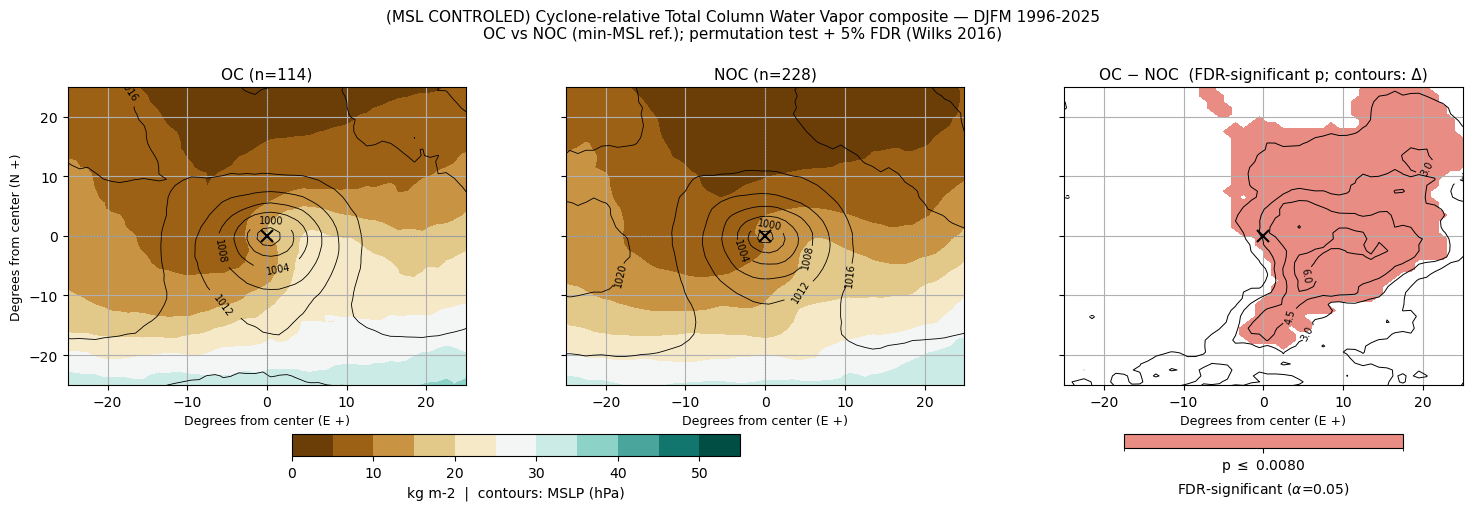

In [66]:
ds_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_tcwv.nc", decode_times=False)
ds_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_tcwv.nc", decode_times=False)

f_oc  = ds_oc["tcwv"]
f_noc = ds_noc["tcwv"]
snap_oc  = ds_oc["snap_tcwv"].values
snap_noc = ds_noc["snap_tcwv"].values
diff_obs, pval = perm_test_diff_means(snap_oc, snap_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
n_tested = int(np.isfinite(pval).sum())
print(f"BH-FDR alpha=0.05: threshold p*={p_fdr:.3f}, "
      f"{int(np.nansum(sig_fdr))}/{n_tested} tested grid points significant")

# Shared contour levels across the OC/NOC panels for direct comparability
vmin = min(np.nanmin(f_oc.values), np.nanmin(f_noc.values))
vmax = max(np.nanmax(f_oc.values), np.nanmax(f_noc.values))
levels = np.arange(0, 56, 5)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

n_oc, n_noc = snap_oc.shape[0], snap_noc.shape[0]
for ax, f, msl, title in zip(axes[:2], [f_oc, f_noc], [msl_oc, msl_noc],
                              [f"OC (n={n_oc})", f"NOC (n={n_noc})"]):
    cf = ax.contourf(ds_oc["x"], ds_oc["y"], f, levels=levels, cmap="BrBG")
    cs = ax.contour(ds_oc["x"], ds_oc["y"], msl, levels=mslp_levels, colors="k", linewidths=0.6)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
    ax.set_xlim(-25, 25); ax.set_ylim(-25, 25); ax.grid(True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)

# Panel 3: p-value shaded only where FDR-significant; contours = OC-NOC difference
plot_sig_panel(axes[2], ds_oc['x'], ds_oc['y'], pval, diff_obs, sig_fdr)
axes[2].set_title("OC − NOC  (FDR-significant p; contours: Δ)", fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)
fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_ticks(np.arange(0, 56, 10))
cbar1.set_label("kg m-2  |  contours: MSLP (hPa)", fontsize=10)
add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)


fig.suptitle("(MSL CONTROLED) Cyclone-relative Total Column Water Vapor composite — DJFM 1996-2025\nOC vs NOC (min-MSL ref.); permutation test + 5% FDR (Wilks 2016)", fontsize=11, y=1.01)
plt.show()

In [67]:
## So that 850 hPa geopotential height contours are on the wind plots:
z850_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_z850.nc",  decode_times=False)["z(5)"] / 9.80665
z850_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_z850.nc", decode_times=False)["z(5)"] / 9.80665

# Shared contour levels so the two panels' height fields are directly comparable
z850_vmin = min(float(z850_oc.min()), float(z850_noc.min()))
z850_vmax = max(float(z850_oc.max()), float(z850_noc.max()))
z850_levels = np.arange(np.floor(z850_vmin / 40) * 40, np.ceil(z850_vmax / 40) * 40 + 1, 40)


850 hPa speed BH-FDR 0.05: p*=nan, 0/6157 significant


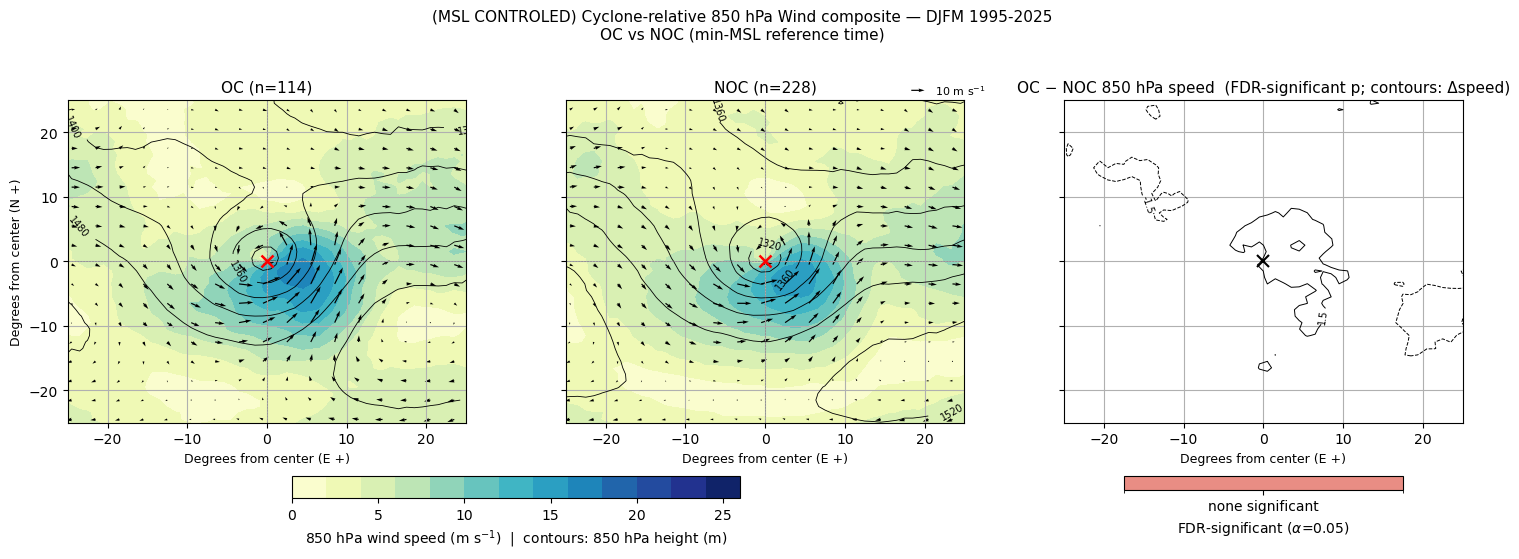

In [68]:
u_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_u850.nc", decode_times=False)["u(5)"]
v_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_v850.nc", decode_times=False)["v(5)"]
u_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_u850.nc", decode_times=False)["u(5)"]
v_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_v850.nc", decode_times=False)["v(5)"]

spd_oc  = np.sqrt(u_oc**2  + v_oc**2)
spd_noc = np.sqrt(u_noc**2 + v_noc**2)

# Per-cyclone wind-SPEED stacks for the significance test. This tests the mean
# of the per-cyclone speeds ("are the wind speeds different?"), which is not the
# same quantity as the speed of the mean wind vector shaded in panels 1-2.
su_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_u850.nc",  decode_times=False)["snap_u(5)"].values
sv_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_v850.nc",  decode_times=False)["snap_v(5)"].values
su_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_u850.nc", decode_times=False)["snap_u(5)"].values
sv_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_v850.nc", decode_times=False)["snap_v(5)"].values
snap_spd_oc  = np.sqrt(su_oc**2  + sv_oc**2)
snap_spd_noc = np.sqrt(su_noc**2 + sv_noc**2)
diff_obs, pval = perm_test_diff_means(snap_spd_oc, snap_spd_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
print(f"850 hPa speed BH-FDR 0.05: p*={p_fdr:.3f}, "
      f"{int(np.nansum(sig_fdr))}/{int(np.isfinite(pval).sum())} significant")

x = u_oc["x"]
y = u_oc["y"]

# shared speed scale across both panels for comparability
vmax = max(np.nanmax(spd_oc.values), np.nanmax(spd_noc.values))
levels = np.arange(0, 27, 2)

skip = 3
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5), sharey=True)

cf1 = axes[0].contourf(x, y, spd_oc, levels=levels, cmap="YlGnBu")
cs1 = axes[0].contour(x, y, z850_oc, levels=z850_levels, colors="k", linewidths=0.6)
axes[0].clabel(cs1, inline=True, fontsize=7, fmt="%.0f")
q1 = axes[0].quiver(
        x[::skip], y[::skip],
        u_oc[::skip, ::skip], v_oc[::skip, ::skip],
        scale=300, width=0.003, color="black",
    )

axes[0].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].plot(0, 0, "rx", markersize=9, markeredgewidth=1.8)
axes[0].grid(True)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
n_oc, n_noc = snap_spd_oc.shape[0], snap_spd_noc.shape[0]
axes[0].set_title(f"OC (n={n_oc})", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)

cf2 = axes[1].contourf(x, y, spd_noc, levels=levels, cmap="YlGnBu")
cs2 = axes[1].contour(x, y, z850_noc, levels=z850_levels, colors="k", linewidths=0.6)
axes[1].clabel(cs2, inline=True, fontsize=7, fmt="%.0f")
q2 = axes[1].quiver(
        x[::skip], y[::skip],
        u_noc[::skip, ::skip], v_noc[::skip, ::skip],
        scale=300, width=0.003, color="black",
    )

axes[1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].plot(0, 0, "rx", markersize=9, markeredgewidth=1.8)
axes[1].grid(True)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].set_title(f"NOC (n={n_noc})", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)

plot_sig_panel(axes[2], x, y, pval, diff_obs, sig_fdr)
axes[2].set_title("OC − NOC 850 hPa speed  (FDR-significant p; contours: Δspeed)", fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

axes[1].quiverkey(q2, 0.9, 1.03, 10, "10 m s$^{-1}$",
             labelpos="E", fontproperties={"size": 8})

fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_ticks(np.arange(0, 26, 5))
cbar1.set_label("850 hPa wind speed (m s$^{-1}$)  |  contours: 850 hPa height (m)", fontsize=10)

add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

fig.suptitle("(MSL CONTROLED) Cyclone-relative 850 hPa Wind composite — DJFM 1995-2025\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.02)

plt.show()

850 hPa v BH-FDR 0.05: p*=nan, 0/6157 significant


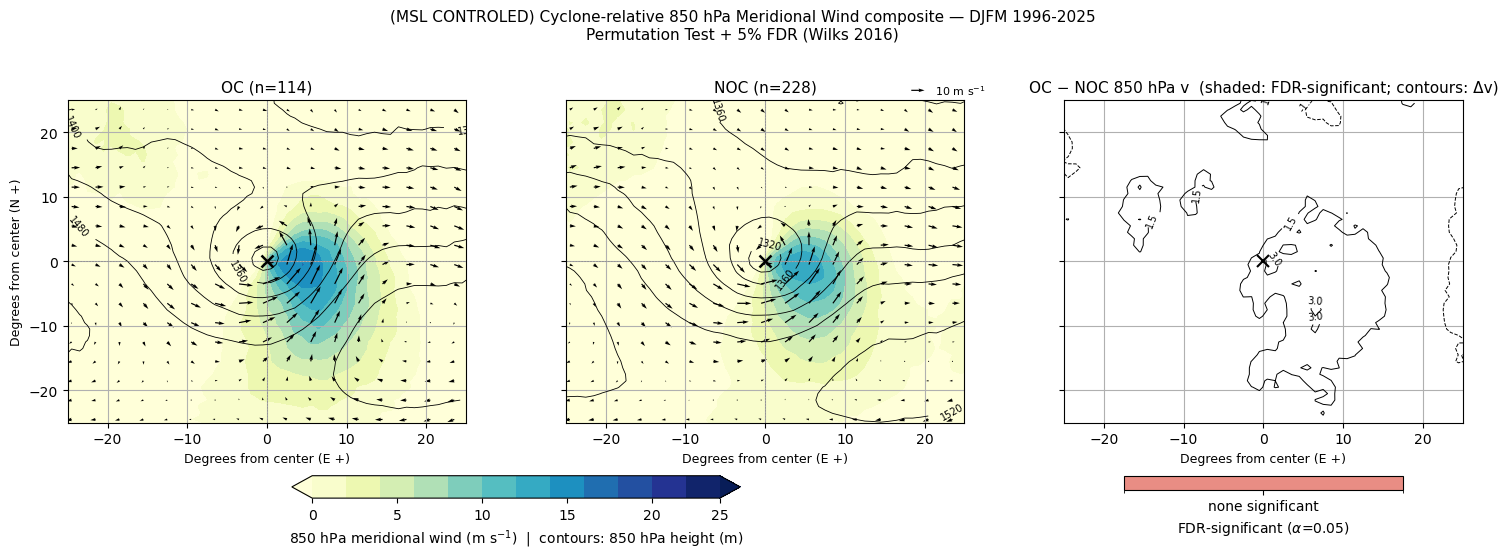

In [69]:
## Same as previous plot but just the meridional component.
## v is SIGNED (northerly flow is negative), so it gets a diverging colormap
## centred on zero -- the old levels started at 0 and clipped all the return flow.
v_ds_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_v850.nc",  decode_times=False)
v_ds_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_v850.nc", decode_times=False)

## Per-cyclone MERIDIONAL-wind stacks: this panel tests v itself (not speed),
## which is exactly the field shaded in panels 1-2.
snap_v_oc  = v_ds_oc["snap_v(5)"].values
snap_v_noc = v_ds_noc["snap_v(5)"].values
diff_obs, pval = perm_test_diff_means(snap_v_oc, snap_v_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
print(f"850 hPa v BH-FDR 0.05: p*={p_fdr:.4f}, "
      f"{int(np.nansum(sig_fdr))}/{int(np.isfinite(pval).sum())} significant")

n_oc, n_noc = snap_v_oc.shape[0], snap_v_noc.shape[0]
x = u_oc["x"]
y = u_oc["y"]

## symmetric, zero-centred levels so northerly/southerly read correctly
levels = np.arange(0, 26, 2)

skip = 3
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5), sharey=True)

for ax, u, v, z850, title in (
    (axes[0], u_oc,  v_oc,  z850_oc,  f"OC (n={n_oc})"),
    (axes[1], u_noc, v_noc, z850_noc, f"NOC (n={n_noc})"),
):
    cf = ax.contourf(x, y, v, levels=levels, cmap="YlGnBu", extend="both")
    cs = ax.contour(x, y, z850, levels=z850_levels, colors="k", linewidths=0.6)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    q = ax.quiver(x[::skip], y[::skip],
                  u[::skip, ::skip], v[::skip, ::skip],
                  scale=300, width=0.003, color="black")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "kx", markersize=9, markeredgewidth=1.8)
    ax.set_xlim(-25, 25); ax.set_ylim(-25, 25); ax.grid(True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)

axes[1].quiverkey(q, 0.9, 1.03, 10, "10 m s$^{-1}$",
                  labelpos="E", fontproperties={"size": 8})

plot_sig_panel(axes[2], x, y, pval, diff_obs, sig_fdr, diff_fmt="%.1f")
axes[2].set_title("OC − NOC 850 hPa v  (shaded: FDR-significant; contours: Δv)",
                  fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)
fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_ticks(np.arange(0, 26, 5))    
cbar1.set_label("850 hPa meridional wind (m s$^{-1}$)  |  contours: 850 hPa height (m)", fontsize=10)

add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

fig.suptitle("(MSL CONTROLED) Cyclone-relative 850 hPa Meridional Wind composite — DJFM 1996-2025\n"
             "Permutation Test + 5% FDR (Wilks 2016)", fontsize=11, y=1.02)
plt.show()

500 hPa height BH-FDR 0.05: p*=0.011, 1311/6157 significant


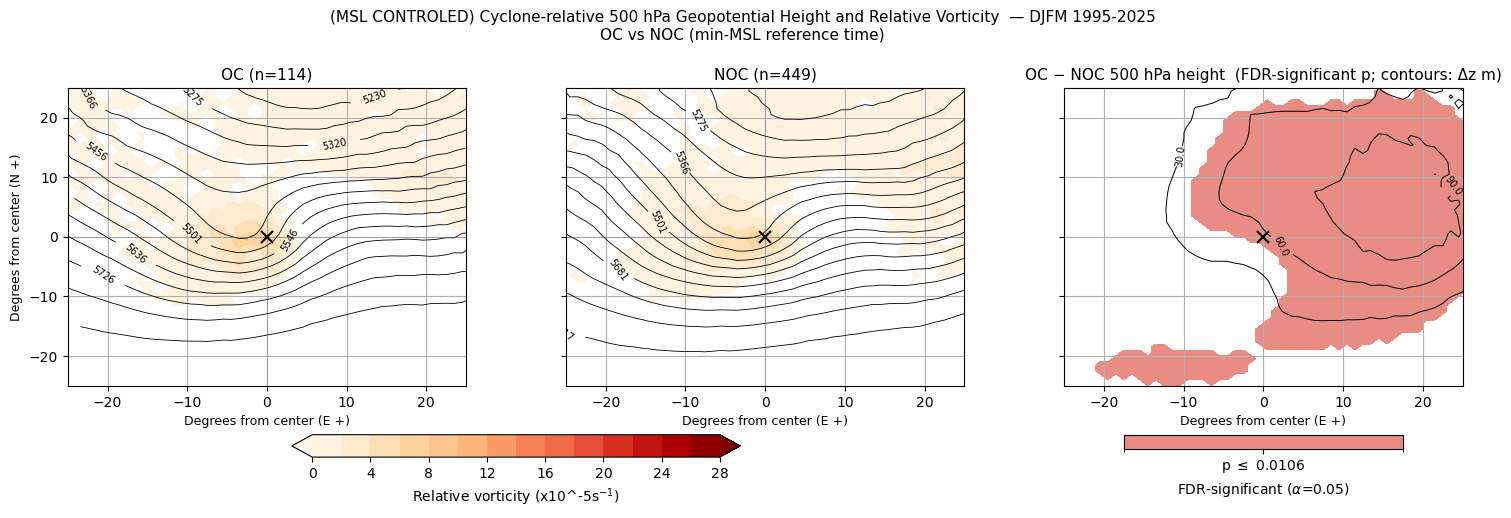

-7.7403617 17.365114
-8.764979 26.94819


In [42]:
z_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_z500.nc", decode_times=False)['z(12)'] / 9.80665
z_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_z500.nc", decode_times=False)['z(12)'] / 9.80665
oc_vort = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_vo500.nc", decode_times=False)['vo(12)']
noc_vort = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_vo500.nc", decode_times=False)['vo(12)']

# Per-cyclone 500 hPa geopotential-HEIGHT stacks for the significance test.
sz_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_z500.nc",  decode_times=False)["snap_z(12)"].values / 9.80665
sz_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_z500.nc", decode_times=False)["snap_z(12)"].values / 9.80665
diff_obs, pval = perm_test_diff_means(sz_oc, sz_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
print(f"500 hPa height BH-FDR 0.05: p*={p_fdr:.3f}, "
      f"{int(np.nansum(sig_fdr))}/{int(np.isfinite(pval).sum())} significant")

# Shared contour levels across both panels for direct comparability
vmin = min(np.nanmin(z_oc.values), np.nanmin(z_noc.values))
vmax = max(np.nanmax(z_oc.values), np.nanmax(z_noc.values))
levels = np.linspace(vmin, vmax, 21)

pos_vort_oc = np.where(oc_vort.values > 0, oc_vort.values * 1e5, np.nan)
pos_vort_noc = np.where(noc_vort.values > 0, noc_vort.values * 1e5, np.nan)

#vort_vmin = min(np.nanmin(oc_vort.values), np.nanmin(noc_vort.values))
vort_vmax = max(np.nanmax(pos_vort_oc), np.nanmax(pos_vort_noc))
vort_levels = np.arange(0, vort_vmax+2, 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

cf1 = axes[0].contourf(z_oc["x"], z_oc["y"], pos_vort_oc, levels=vort_levels, cmap="OrRd", extend="both")
cs1 = axes[0].contour(z_oc["x"], z_oc["y"], z_oc, levels=levels, colors="k", linewidths=0.6)
axes[0].clabel(cs1, inline=True, fontsize=7, fmt="%.0f")
axes[0].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].grid(True)
axes[0].set_title("OC (n=114)", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)

cf2 = axes[1].contourf(z_noc["x"], z_noc["y"], pos_vort_noc, levels=vort_levels, cmap="OrRd", extend="both")
cs2 = axes[1].contour(z_noc["x"], z_noc["y"], z_noc, levels=levels, colors="k", linewidths=0.6)
axes[1].clabel(cs2, inline=True, fontsize=7, fmt="%.0f")
axes[1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].grid(True)
axes[1].set_title("NOC (n=449)", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)

plot_sig_panel(axes[2], x, y, pval, diff_obs, sig_fdr)
axes[2].set_title("OC − NOC 500 hPa height  (FDR-significant p; contours: Δz m)", fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_label("Relative vorticity (x10^-5s$^{-1}$)", fontsize=10)

add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

fig.suptitle("(MSL CONTROLED) Cyclone-relative 500 hPa Geopotential Height and Relative Vorticity  — DJFM 1995-2025\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.01)

plt.show()
print(np.nanmin(oc_vort * 1e5), np.nanmax(oc_vort * 1e5))
print(np.nanmin(noc_vort * 1e5), np.nanmax(noc_vort * 1e5))

250 hPa speed BH-FDR 0.05: p*=0.002, 307/6157 significant


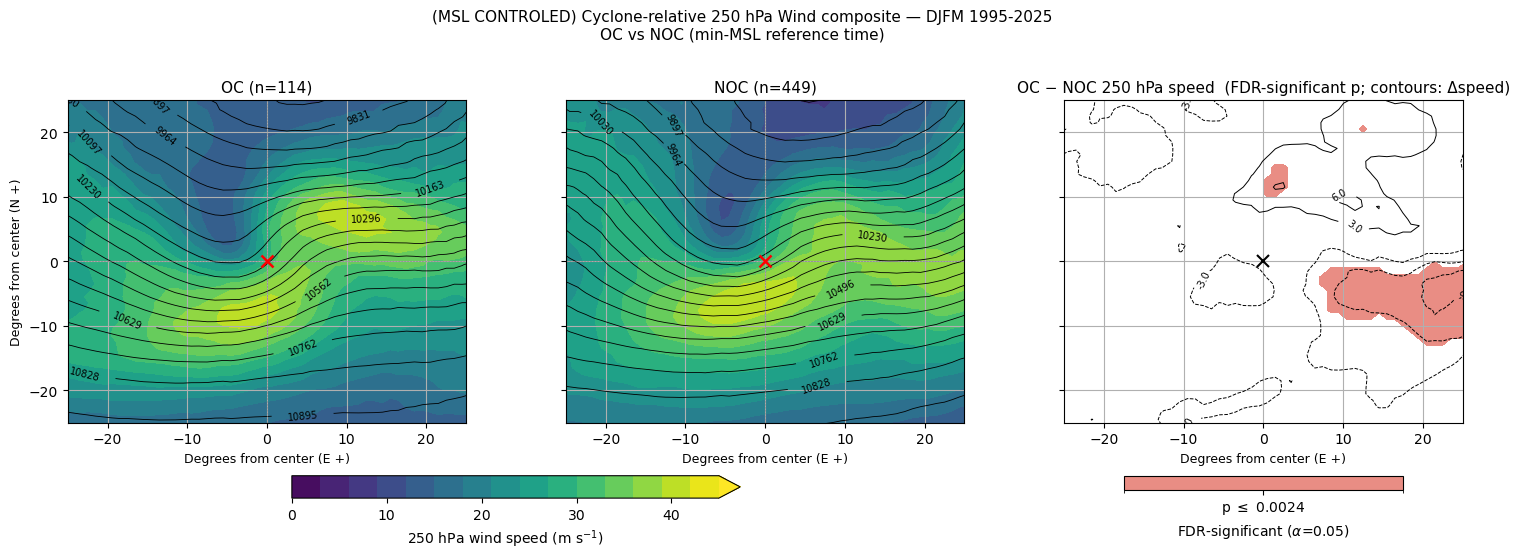

In [43]:
u_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_u250.nc", decode_times=False)['u(17)'] 
u_noc  = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_u250.nc", decode_times=False)['u(17)'] 

v_oc = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_v250.nc", decode_times=False)['v(17)']
v_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_v250.nc", decode_times=False)['v(17)']

z_oc = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_z250.nc", decode_times=False)['z(17)'] / 9.80665
z_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_z250.nc", decode_times=False)['z(17)'] / 9.80665

# Shared geopotential height contour levels across both panels for direct comparability
vmin_z = min(np.nanmin(z_oc.values), np.nanmin(z_noc.values))
vmax_z = max(np.nanmax(z_oc.values), np.nanmax(z_noc.values))
z_levels = np.linspace(vmin_z, vmax_z, 21)

spd_oc = np.sqrt(u_oc**2 + v_oc**2)
spd_noc = np.sqrt(u_noc**2 + v_noc**2)

# Per-cyclone wind-SPEED stacks for the significance test (mean of per-cyclone
# speeds, distinct from the speed of the mean vector shaded in panels 1-2).
su_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_u250.nc",  decode_times=False)["snap_u(17)"].values
sv_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_v250.nc",  decode_times=False)["snap_v(17)"].values
su_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_u250.nc", decode_times=False)["snap_u(17)"].values
sv_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_v250.nc", decode_times=False)["snap_v(17)"].values
snap_spd_oc  = np.sqrt(su_oc**2  + sv_oc**2)
snap_spd_noc = np.sqrt(su_noc**2 + sv_noc**2)
diff_obs, pval = perm_test_diff_means(snap_spd_oc, snap_spd_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
print(f"250 hPa speed BH-FDR 0.05: p*={p_fdr:.3f}, "
      f"{int(np.nansum(sig_fdr))}/{int(np.isfinite(pval).sum())} significant")

x = u_oc["x"]
y = u_oc["y"]

# Shared speed scale across both panels for comparability
vmax = max(np.nanmax(spd_oc.values), np.nanmax(spd_noc.values))
spd_levels = np.arange(0, 46, 3)

skip = 3

fig, axes = plt.subplots(1,3, figsize=(18,6.5), sharey=True)

cf1 = axes[0].contourf(spd_oc["x"], spd_oc["y"], spd_oc, levels=spd_levels, cmap="viridis", extend="max")
cs1 = axes[0].contour(z_oc["x"], z_oc["y"], z_oc, levels=z_levels, colors="k", linewidths=0.6)
axes[0].clabel(cs1, inline=True, fontsize=7, fmt="%.0f")
axes[0].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].plot(0, 0, "rx", markersize=9, markeredgewidth=1.8)
axes[0].grid(True)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].set_title("OC (n=114)", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)

cf2 = axes[1].contourf(spd_noc["x"], spd_noc["y"], spd_noc, levels=spd_levels, cmap="viridis", extend="max")
cs2 = axes[1].contour(z_noc["x"], z_noc["y"], z_noc, levels=z_levels, colors="k", linewidths=0.6)
axes[1].clabel(cs2, inline=True, fontsize=7, fmt="%.0f")
axes[1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].plot(0, 0, "rx", markersize=9, markeredgewidth=1.8)
axes[1].grid(True)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].set_title("NOC (n=449)", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)

plot_sig_panel(axes[2], x, y, pval, diff_obs, sig_fdr)
axes[2].set_title("OC − NOC 250 hPa speed  (FDR-significant p; contours: Δspeed)", fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_ticks(np.arange(0, 46, 10))
cbar1.set_label("250 hPa wind speed (m s$^{-1}$)", fontsize=10)

add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

fig.suptitle("(MSL CONTROLED) Cyclone-relative 250 hPa Wind composite — DJFM 1995-2025\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.02)

plt.show()



CAPE BH-FDR 0.05: p*=0.003, 394/6157 significant


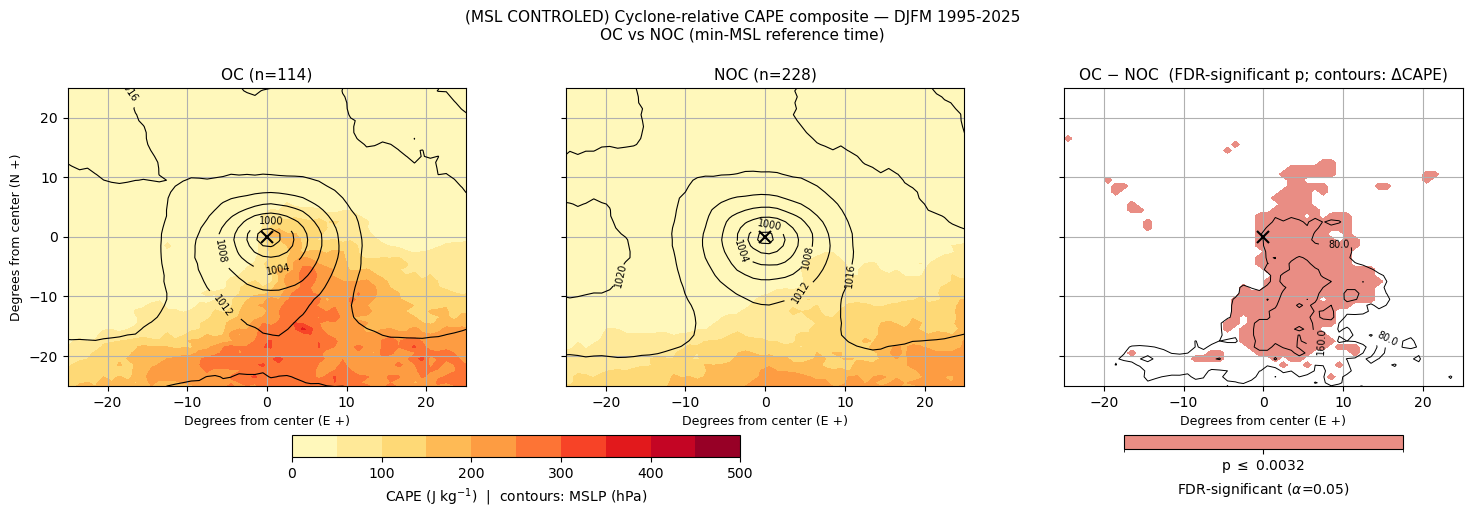

0.0 1090.3671
0.0 874.1238


In [70]:
cape_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_cape.nc", decode_times=False)['cape']
cape_noc  = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_cape.nc", decode_times=False)['cape']

vmin = min(np.nanmin(cape_oc.values), np.nanmin(cape_noc.values))
vmax = max(np.nanmax(cape_oc.values), np.nanmax(cape_noc.values))
levels = np.arange(0, 500+1, 50)

diff = cape_oc - cape_noc

# Per-cyclone CAPE stacks for the significance test.
snap_oc  = xr.open_dataset("/data1/lepique/composites_matched1to2/oc_min_msl_cape.nc",  decode_times=False)["snap_cape"].values
snap_noc = xr.open_dataset("/data1/lepique/composites_matched1to2/noc_min_msl_cape.nc", decode_times=False)["snap_cape"].values
diff_obs, pval = perm_test_diff_means(snap_oc, snap_noc, n_resamples=5000, seed=1)
sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
print(f"CAPE BH-FDR 0.05: p*={p_fdr:.3f}, "
      f"{int(np.nansum(sig_fdr))}/{int(np.isfinite(pval).sum())} significant")

x = cape_oc['x']
y = cape_oc['y']

fig, axes = plt.subplots(1,3, figsize=(18,6), sharey=True)

cf1 = axes[0].contourf(x, y, cape_oc, levels=levels, cmap="YlOrRd")
cs1 = axes[0].contour(x, y, msl_oc, levels=mslp_levels, colors="k", linewidths=0.8)
axes[0].clabel(cs1, inline=True, fontsize=7, fmt="%.0f")
axes[0].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].grid(True)
n_oc, n_noc = snap_oc.shape[0], snap_noc.shape[0]
axes[0].set_title(f"OC (n={n_oc})", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)

cf2 = axes[1].contourf(x, y, cape_noc, levels=levels, cmap="YlOrRd")
cs2 = axes[1].contour(x, y, msl_noc, levels=mslp_levels, colors="k", linewidths=0.8)
axes[1].clabel(cs2, inline=True, fontsize=7, fmt="%.0f")
axes[1].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].grid(True)
axes[1].set_title(f"NOC (n={n_noc})", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)

plot_sig_panel(axes[2], x, y, pval, diff_obs, sig_fdr)
axes[2].set_title("OC − NOC  (FDR-significant p; contours: ΔCAPE)", fontsize=11)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)
fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_label("CAPE (J kg$^{-1}$)  |  contours: MSLP (hPa)", fontsize=10)

add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

fig.suptitle("(MSL CONTROLED) Cyclone-relative CAPE composite — DJFM 1995-2025\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.01)

plt.show()
print(np.nanmin(cape_oc), np.nanmax(cape_oc))
print(np.nanmin(cape_oc), np.nanmax(cape_noc))

In [45]:
SHEAR_DIR = "/data1/lepique/composites_matched1to2"

def plot_shear_composite(tag, label, levels, n_resamples=5000, seed=1, skip=3, scale=None, key=10):
    def load(pop, var):
        return xr.open_dataset(f"{SHEAR_DIR}/{pop}_min_msl_{var}.nc",
                                decode_times=False)
    
    mag_oc, mag_noc = load("oc", tag)[tag], load("noc", tag)[tag]
    u_oc,    u_noc   = (load("oc",  f"{tag}_u")[f"{tag}_u"],
                        load("noc", f"{tag}_u")[f"{tag}_u"])
    v_oc,    v_noc   = (load("oc",  f"{tag}_v")[f"{tag}_v"],
                        load("noc", f"{tag}_v")[f"{tag}_v"])

    ## per-cyclone magnitude stacks -> permutation test and FDR control
    snap_oc = load("oc", tag)[f"snap_{tag}"].values
    snap_noc = load("noc", tag)[f"snap_{tag}"].values
    diff_obs, pval = perm_test_diff_means(snap_oc, snap_noc,
                                          n_resamples=n_resamples, seed=seed)
    sig_fdr, p_fdr = bh_fdr(pval, alpha_fdr=0.05)
    print(f"{label} shear BH-FDR 0.05: p*={p_fdr:.3f}, "
          f"{int(np.nansum(sig_fdr))}/{int(np.isfinite(pval).sum())} significant")

    n_oc, n_noc = snap_oc.shape[0], snap_noc.shape[0]
    x,y = mag_oc["x"], mag_oc["y"]

    fig, axes = plt.subplots(1,3, figsize=(18,6.5), sharey=True)

    for ax, mag, u, v, msl, title in (
        (axes[0], mag_oc, u_oc, v_oc, msl_oc, f"OC (n={n_oc})"),
        (axes[1], mag_noc, u_noc, v_noc, msl_noc, f"OC (n={n_noc})"),
    ):
        cf = ax.contourf(x, y, mag, levels=levels, cmap="YlGnBu", extend="max")
        cs = ax.contour(x, y, msl, levels=mslp_levels, colors="k", linewidths=0.5)
        ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
        q = ax.quiver(x[::skip], y[::skip],
                      u[::skip, ::skip], v[::skip, ::skip],
                      scale=scale, width=0.0025, minlength=0, 
                      headwidth=2.5, headlength=3.5, headaxislength=3,
                      color="black")
        ax.plot(0, 0, "rx", markersize=9, markeredgewidth=1.8)
        ax.grid(True)
        ax.set_xlim(-25, 25)
        ax.set_ylim(-25, 25)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Degrees from center (E +)", fontsize=9)

    axes[1].quiverkey(q, 0.9, 1.03, 10, f"{key} m s$^{-1}$",
                      labelpos="E", fontproperties={"size": 8})
    
    plot_sig_panel(axes[2], x, y, pval, diff_obs, sig_fdr, nbins=14)

    axes[2].set_title(f"OC − NOC {label} shear  (shaded: FDR-significant; contours: Δshear)",
                      fontsize=11)

    axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)
    fig.subplots_adjust(bottom=0.2, wspace=0.25)

    cbar1 = fig.colorbar(cf, ax=axes[:2], orientation="horizontal",
                         pad=0.12, shrink=0.5)
    cbar1.set_label(f"{label} bulk wind shear (m s$^{{-1}}$)", fontsize=10)

    add_sig_colorbar(fig, axes[2], p_fdr, pad=0.12, shrink=0.7)

    fig.suptitle(
        f"(MSL CONTROLED) Cyclone-relative {label} bulk wind shear composite — DJFM 1995-2025\n"
        f"OC vs NOC (min-MSL reference time)", fontsize=11, y=1.02)
    plt.show()

0-6 km shear BH-FDR 0.05: p*=0.005, 570/6157 significant


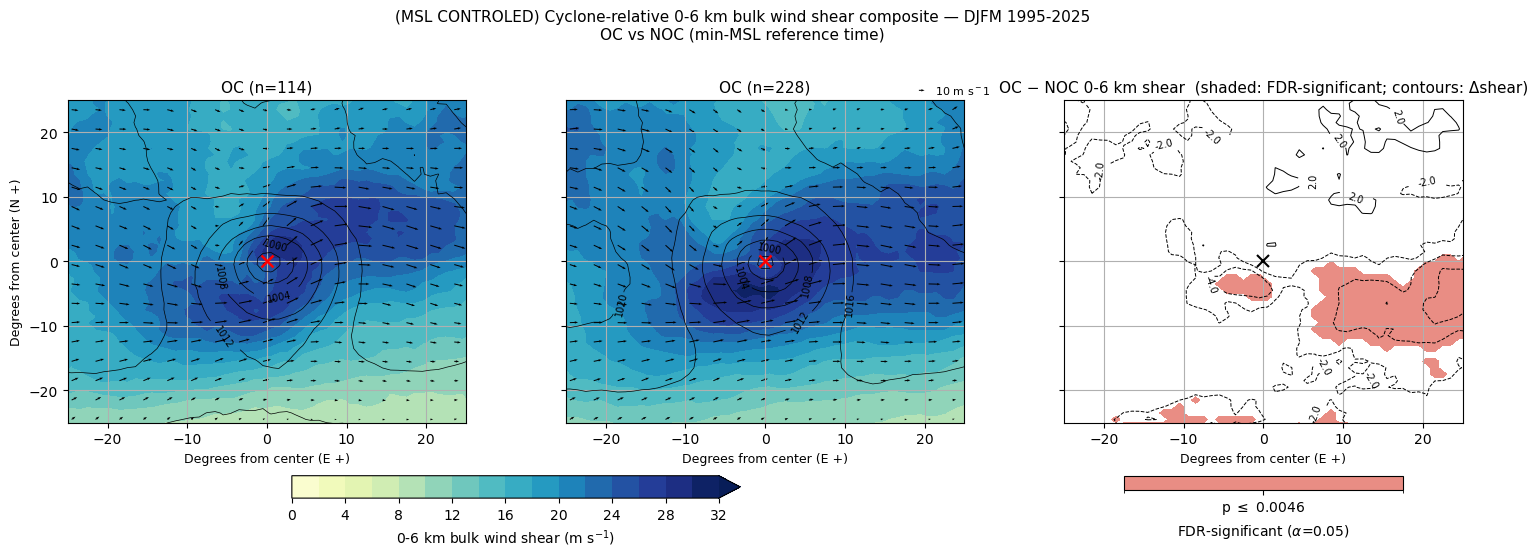

In [46]:
##### 0-6 km bulk shear
plot_shear_composite("shear06", "0-6 km", levels=np.arange(0, 32 + 1, 2), scale=700)

0-3 km shear BH-FDR 0.05: p*=0.005, 645/6157 significant


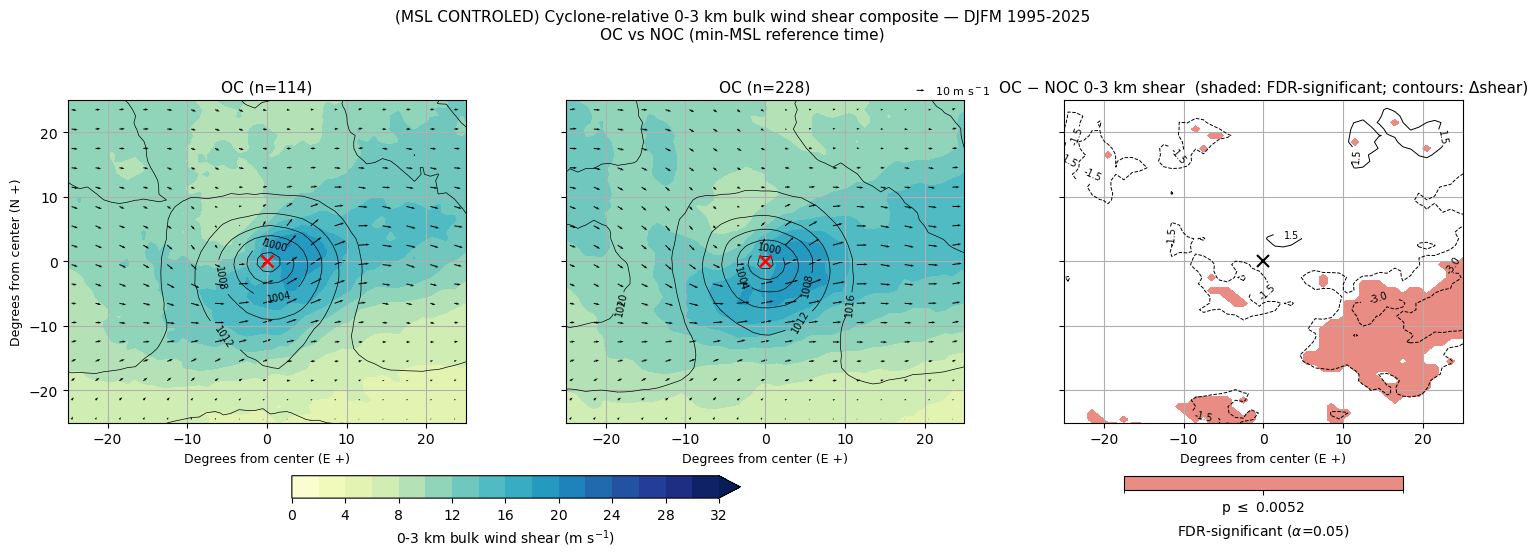

In [47]:
plot_shear_composite("shear03", "0-3 km", levels=np.arange(0, 32 + 1, 2), scale=500)

0-1 km shear BH-FDR 0.05: p*=0.001, 81/6157 significant


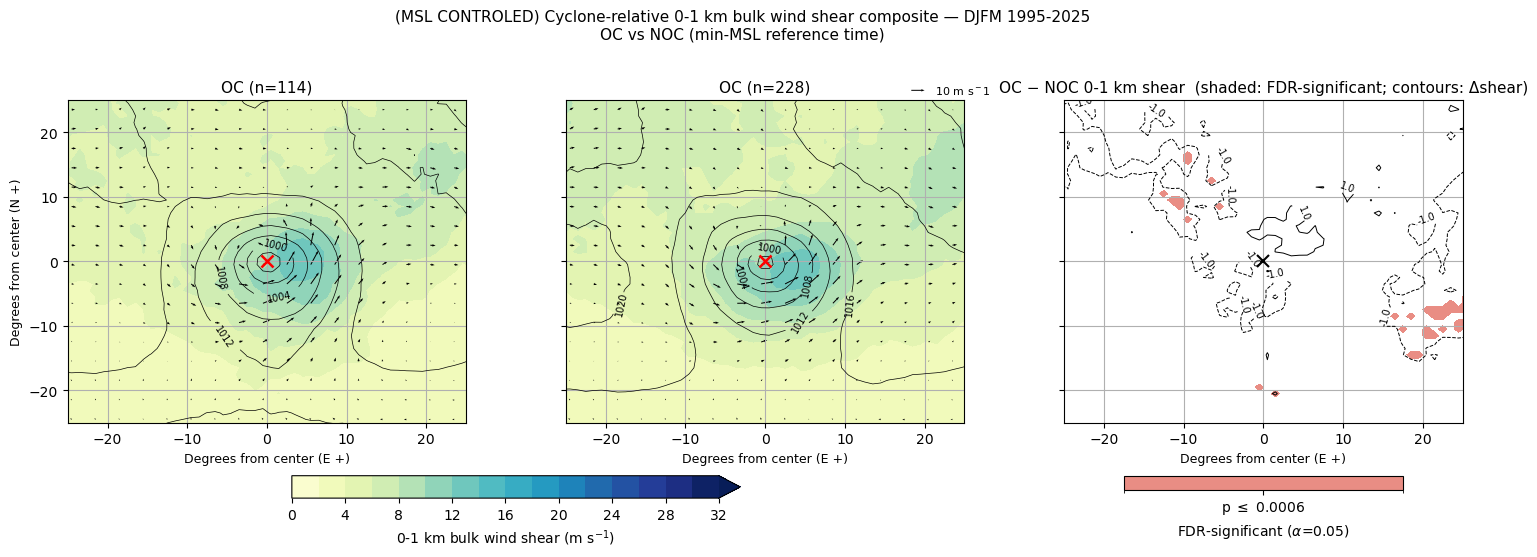

In [48]:
plot_shear_composite("shear01", "0-1 km", levels=np.arange(0, 32 + 1, 2), scale=300)

## Composites at the time of max reports (to compare to TN2016)

### 2m Temperature

In [33]:
ds_oc  = xr.open_dataset("/data1/lepique/composites_full/oc_timemaxreports_t2m.nc")
ds_oc = (ds_oc - 273.15) * 9/5 + 32
t_oc  = ds_oc["t2m"]  

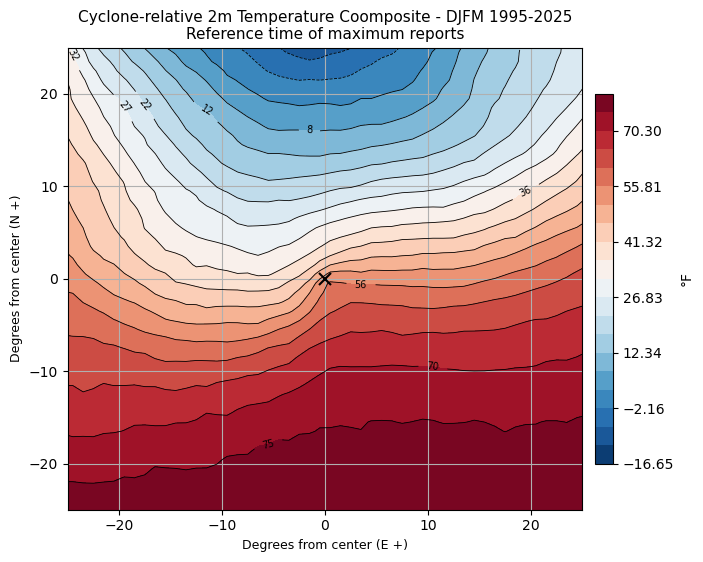

In [34]:
vmin = np.nanmin(t_oc.values)
vmax = np.nanmax(t_oc.values)
levels = np.linspace(vmin, vmax, 21)

fig, ax = plt.subplots(figsize=(8,6))

cf = ax.contourf(
    ds_oc['x'], ds_oc['y'], t_oc,
    levels=levels, cmap='RdBu_r',
)
cs = ax.contour(
        ds_oc['x'], ds_oc['y'], t_oc,
        levels=levels, colors="k", linewidths=0.6,
    )

ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
ax.set_xlim(-25, 25)
ax.set_ylim(-25, 25)
ax.grid(True)
ax.set_title("Cyclone-relative 2m Temperature Coomposite - DJFM 1995-2025\nReference time of maximum reports",
              fontsize=11)
ax.set_xlabel("Degrees from center (E +)", fontsize=9)
ax.set_ylabel("Degrees from center (N +)", fontsize=9)

cbar = fig.colorbar(cf, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label("°F", fontsize=10)

### 2m Dewpoint

In [38]:
ds_oc  = xr.open_dataset("/data1/lepique/composites_full/oc_timemaxreports_d2m.nc")
ds_oc = (ds_oc - 273.15) * 9/5 + 32
t_oc  = ds_oc["d2m"]  

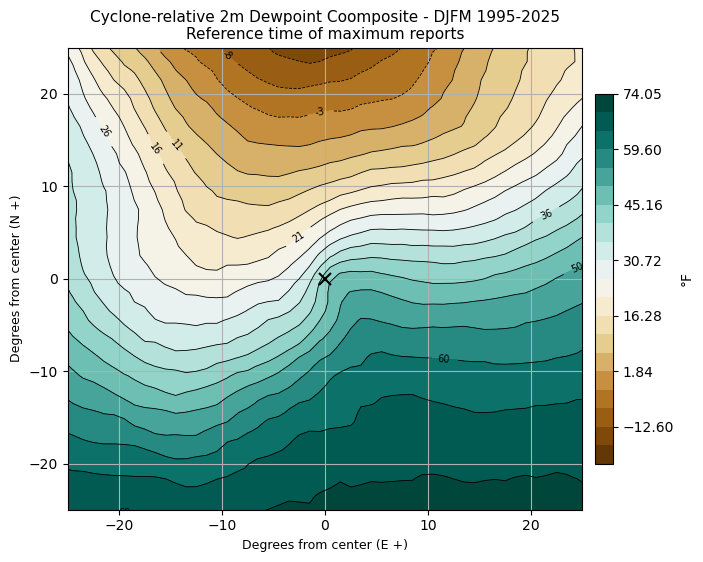

In [39]:
vmin = np.nanmin(t_oc.values)
vmax = np.nanmax(t_oc.values)
levels = np.linspace(vmin, vmax, 21)

fig, ax = plt.subplots(figsize=(8,6))

cf = ax.contourf(
    ds_oc['x'], ds_oc['y'], t_oc,
    levels=levels, cmap='BrBG',
)
cs = ax.contour(
        ds_oc['x'], ds_oc['y'], t_oc,
        levels=levels, colors="k", linewidths=0.6,
    )

ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
ax.set_xlim(-25, 25)
ax.set_ylim(-25, 25)
ax.grid(True)
ax.set_title("Cyclone-relative 2m Dewpoint Coomposite - DJFM 1995-2025\nReference time of maximum reports",
              fontsize=11)
ax.set_xlabel("Degrees from center (E +)", fontsize=9)
ax.set_ylabel("Degrees from center (N +)", fontsize=9)

cbar = fig.colorbar(cf, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label("°F", fontsize=10)

### Total Column Integrated Water Vapor

In [41]:
ds_oc  = xr.open_dataset("/data1/lepique/composites_full/oc_timemaxreports_tcwv.nc")
t_oc  = ds_oc["tcwv"] 

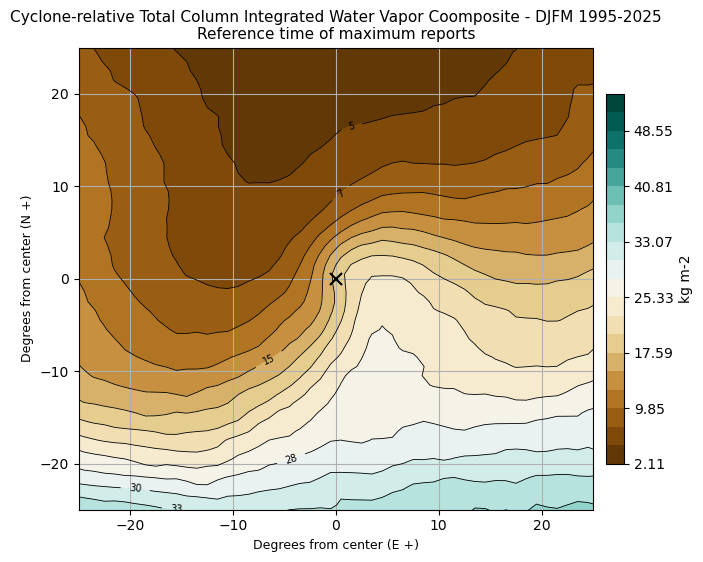

In [43]:
vmin = np.nanmin(t_oc.values)
vmax = np.nanmax(t_oc.values)
levels = np.linspace(vmin, vmax, 21)

fig, ax = plt.subplots(figsize=(8,6))

cf = ax.contourf(
    ds_oc['x'], ds_oc['y'], t_oc,
    levels=levels, cmap='BrBG',
)
cs = ax.contour(
        ds_oc['x'], ds_oc['y'], t_oc,
        levels=levels, colors="k", linewidths=0.6,
    )

ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
ax.set_xlim(-25, 25)
ax.set_ylim(-25, 25)
ax.grid(True)
ax.set_title("Cyclone-relative Total Column Integrated Water Vapor Coomposite - DJFM 1995-2025\nReference time of maximum reports",
              fontsize=11)
ax.set_xlabel("Degrees from center (E +)", fontsize=9)
ax.set_ylabel("Degrees from center (N +)", fontsize=9)

cbar = fig.colorbar(cf, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label("kg m-2", fontsize=10)

### 850 hPa winds

In [49]:
u_oc  = xr.open_dataset("/data1/lepique/composites_full/oc_timemaxreports_u850.nc")["u(5)"]
v_oc  = xr.open_dataset("/data1/lepique/composites_full/oc_timemaxreports_v850.nc")["v(5)"]
z_oc  = xr.open_dataset("/data1/lepique/composites_full/oc_timemaxreports_z850.nc")["z(5)"] / 9.80665

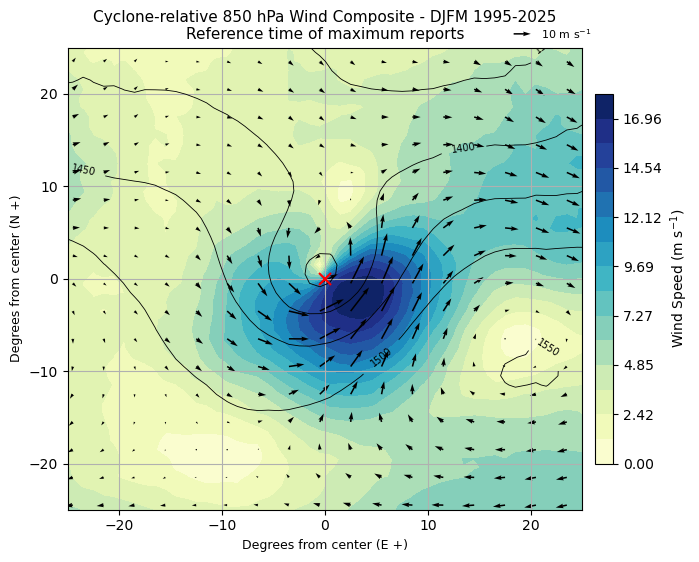

In [57]:
spd_oc  = np.sqrt(u_oc**2  + v_oc**2)

x = u_oc["x"]
y = u_oc["y"]

vmax = np.nanmax(spd_oc.values)
levels = np.linspace(0, vmax, 16)

skip = 3

fig, ax = plt.subplots(figsize=(8,6))

cf = ax.contourf(
    x, y, spd_oc,
    levels=levels, cmap='YlGnBu',
)
cs = ax.contour(
        ds_oc['x'], ds_oc['y'], z_oc,
        colors="k", linewidths=0.6,
    )
q = ax.quiver(
        x[::skip], y[::skip],
        u_oc[::skip, ::skip], v_oc[::skip, ::skip],
        scale=300, width=0.003, color="black",
    )

# reference arrow on the second panel
ax.quiverkey(q, 0.9, 1.03, 10, "10 m s$^{-1}$",
             labelpos="E", fontproperties={"size": 8})

ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
ax.plot(0, 0, "rx", markersize=8, markeredgewidth=1.5)
ax.set_xlim(-25, 25)
ax.set_ylim(-25, 25)
ax.grid(True)
ax.set_title("Cyclone-relative 850 hPa Wind Composite - DJFM 1995-2025\nReference time of maximum reports",
              fontsize=11)
ax.set_xlabel("Degrees from center (E +)", fontsize=9)
ax.set_ylabel("Degrees from center (N +)", fontsize=9)

cbar = fig.colorbar(cf, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label("Wind Speed (m s$^{-1}$)", fontsize=10)

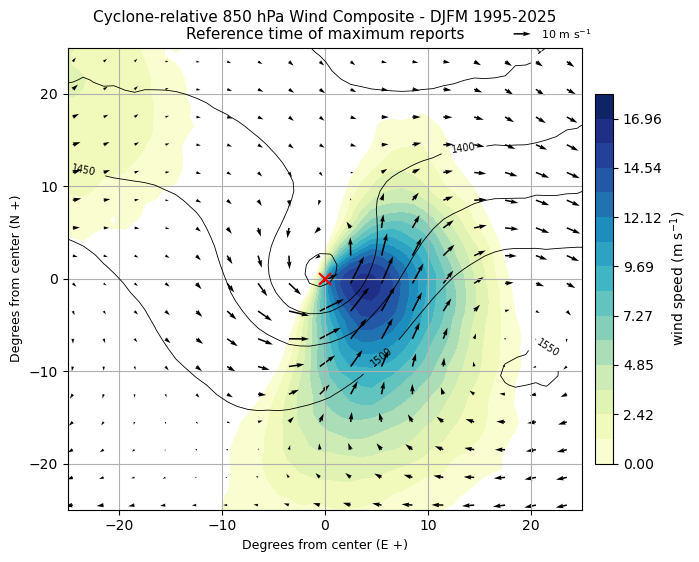

In [58]:
## meridional component only

x = u_oc["x"]
y = u_oc["y"]
v = v_oc.values

vmax = np.nanmax(spd_oc.values)
levels = np.linspace(0, vmax, 16)

skip = 3

fig, ax = plt.subplots(figsize=(8,6))

cf = ax.contourf(
    x, y, v,
    levels=levels, cmap='YlGnBu',
)
cs = ax.contour(
        ds_oc['x'], ds_oc['y'], z_oc,
        colors="k", linewidths=0.6,
    )
q = ax.quiver(
        x[::skip], y[::skip],
        u_oc[::skip, ::skip], v_oc[::skip, ::skip],
        scale=300, width=0.003, color="black",
    )
# reference arrow on the second panel
ax.quiverkey(q, 0.9, 1.03, 10, "10 m s$^{-1}$",
             labelpos="E", fontproperties={"size": 8})

ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
ax.plot(0, 0, "rx", markersize=8, markeredgewidth=1.5)
ax.set_xlim(-25, 25)
ax.set_ylim(-25, 25)
ax.grid(True)
ax.set_title("Cyclone-relative 850 hPa Wind Composite - DJFM 1995-2025\nReference time of maximum reports",
              fontsize=11)
ax.set_xlabel("Degrees from center (E +)", fontsize=9)
ax.set_ylabel("Degrees from center (N +)", fontsize=9)

cbar = fig.colorbar(cf, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label("wind speed (m s$^{-1}$)", fontsize=10)

### 500 hPa Heights and Vorticity

In [14]:
z_oc  = xr.open_dataset("/data1/lepique/composites_full/oc_timemaxreports_z500.nc")['z(12)'] / 9.80665
oc_vort = xr.open_dataset("/data1/lepique/composites_full/oc_timemaxreports_vo500.nc")['vo(12)'] * 1e5


-7.3000093 29.067764


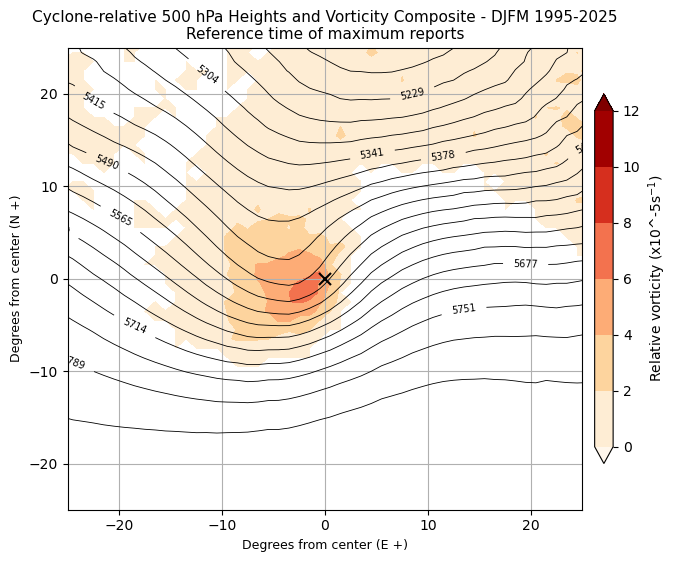

In [20]:
h_vmin = np.nanmin(z_oc.values)
h_vmax = np.nanmax(z_oc.values)
h_levels = np.linspace(h_vmin, h_vmax, 21)

pos_vort = np.where(oc_vort.values > 0, oc_vort.values, np.nan)

vort_vmax = np.nanmax(pos_vort)
vort_levels = np.arange(0, 12 + 2, 2)

fig, ax = plt.subplots(figsize=(8,6))

cf = ax.contourf(
        oc_vort["x"], oc_vort["y"], pos_vort,
        levels=vort_levels, cmap="OrRd", extend="both"
    )
cs = ax.contour(
        z_oc["x"], z_oc["y"], z_oc.values,
        levels=h_levels, colors="k", linewidths=0.6,
    )

ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
ax.set_xlim(-25, 25)
ax.set_ylim(-25, 25)
ax.grid(True)
ax.set_title("Cyclone-relative 500 hPa Heights and Vorticity Composite - DJFM 1995-2025\nReference time of maximum reports",
              fontsize=11)
ax.set_xlabel("Degrees from center (E +)", fontsize=9)
ax.set_ylabel("Degrees from center (N +)", fontsize=9)

cbar = fig.colorbar(cf, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label("Relative vorticity (x10^-5s$^{-1}$)", fontsize=10)

print(np.nanmin(oc_vort), np.nanmax(oc_vort))

### 250 hPa heights and winds:

In [22]:
u_oc  = xr.open_dataset("/data1/lepique/composites_full/oc_timemaxreports_u250.nc")["u(17)"]
v_oc  = xr.open_dataset("/data1/lepique/composites_full/oc_timemaxreports_v250.nc")["v(17)"]
z_oc  = xr.open_dataset("/data1/lepique/composites_full/oc_timemaxreports_z250.nc")["z(17)"] / 9.80665

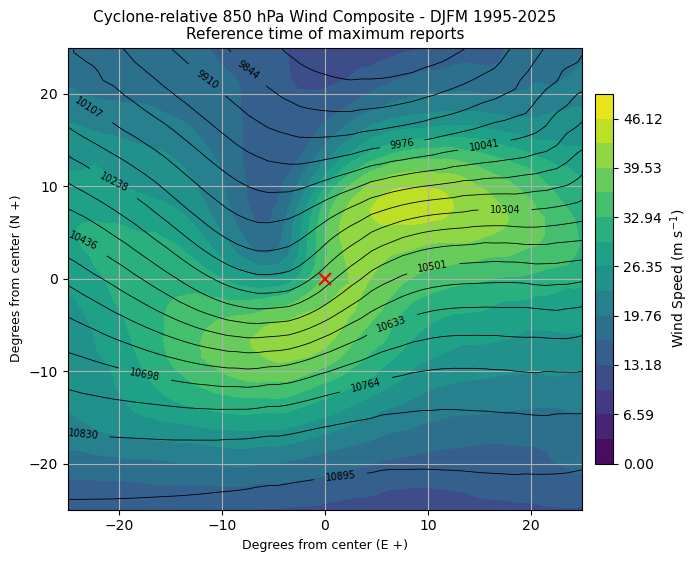

In [26]:
vmin_z = np.nanmin(z_oc.values)
vmax_z = np.nanmax(z_oc.values)
z_levels = np.linspace(vmin_z, vmax_z, 21)

spd_oc  = np.sqrt(u_oc**2  + v_oc**2)

x = u_oc["x"]
y = u_oc["y"]

vmax = np.nanmax(spd_oc.values)
levels = np.linspace(0, vmax, 16)

skip = 3

fig, ax = plt.subplots(figsize=(8,6))

cf = ax.contourf(
    x, y, spd_oc,
    levels=levels, cmap='viridis',
)
cs = ax.contour(
        z_oc['x'], z_oc['y'], z_oc,
        levels = z_levels, colors="k", linewidths=0.6,
    )
# q = ax.quiver(
#         x[::skip], y[::skip],
#         u_oc[::skip, ::skip], v_oc[::skip, ::skip],
#         scale=300, width=0.003, color="black",
#     )

# reference arrow on the second panel
# ax.quiverkey(q, 0.9, 1.03, 10, "10 m s$^{-1}$",
#              labelpos="E", fontproperties={"size": 8})

ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
ax.plot(0, 0, "rx", markersize=8, markeredgewidth=1.5)
ax.set_xlim(-25, 25)
ax.set_ylim(-25, 25)
ax.grid(True)
ax.set_title("Cyclone-relative 850 hPa Wind Composite - DJFM 1995-2025\nReference time of maximum reports",
              fontsize=11)
ax.set_xlabel("Degrees from center (E +)", fontsize=9)
ax.set_ylabel("Degrees from center (N +)", fontsize=9)

cbar = fig.colorbar(cf, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label("Wind Speed (m s$^{-1}$)", fontsize=10)

### CAPE

In [27]:
cape_oc  = xr.open_dataset("/data1/lepique/composites_full/oc_timemaxreports_cape.nc")['cape']

0.0
835.67114


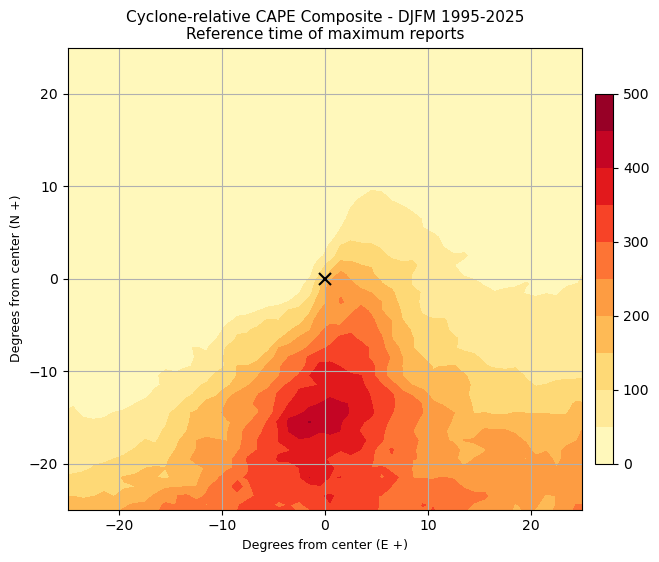

In [33]:
vmin = np.nanmin(cape_oc.values)
vmax = np.nanmax(cape_oc.values)
levels = np.arange(0, 500+1, 50)

x = cape_oc['x']
y = cape_oc['y']

fig, ax = plt.subplots(figsize=(8,6))

cf = ax.contourf(
        x, y, cape_oc, 
        levels=levels, cmap="YlOrRd",
    )

ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
ax.set_xlim(-25, 25)
ax.set_ylim(-25, 25)
ax.grid(True)
ax.set_title(title, fontsize=11)
ax.set_xlabel("Degrees from center (E +)", fontsize=9)
ax.set_ylabel("Degrees from center (N +)", fontsize=9)

cbar = fig.colorbar(cf, ax=ax, pad=0.02, shrink=0.8)

ax.set_title("Cyclone-relative CAPE Composite - DJFM 1995-2025\nReference time of maximum reports",
              fontsize=11)

print(np.nanmin(cape_oc.values))
print(np.nanmax(cape_oc.values))




## Differences between the samples of OCs and NOCs

In [8]:
etc_summary = pd.read_csv('data/etc_summary_final.csv')

In [9]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind,n_cores_total,n_cores_kept,kept_reports,max_core_reports,time_max_reports
0,1.0,1995-12-01 00:00:00+00:00,1995-12-06 23:00:00+00:00,1995-12-02 22:00:00+00:00,980.3069,144,0,0,0,0,0,0,0,0,NaN
1,2.0,1995-12-01 00:00:00+00:00,1995-12-12 03:00:00+00:00,1995-12-10 06:00:00+00:00,961.9612,251,0,0,0,0,0,0,0,0,NaN
2,3.0,1995-12-03 06:00:00+00:00,1995-12-07 01:00:00+00:00,1995-12-05 04:00:00+00:00,994.3956,92,1,1,0,0,0,0,0,0,1995-12-06 04:00:00+00:00
3,4.0,1995-12-04 04:00:00+00:00,1995-12-06 04:00:00+00:00,1995-12-06 04:00:00+00:00,978.0338,49,0,0,0,0,0,0,0,0,NaN
4,5.0,1995-12-06 17:00:00+00:00,1995-12-08 01:00:00+00:00,1995-12-07 19:00:00+00:00,980.9462,31,0,0,0,0,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,6114.0,2025-03-24 18:00:00+00:00,2025-03-29 11:00:00+00:00,2025-03-27 22:00:00+00:00,1005.1210,106,5,0,4,1,1,0,0,0,2025-03-28 21:00:00+00:00
2221,6116.0,2025-03-26 17:00:00+00:00,2025-03-30 19:00:00+00:00,2025-03-29 10:00:00+00:00,982.2738,99,0,0,0,0,0,0,0,0,NaN
2222,6117.0,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114,927,66,277,584,7,2,891,821,2025-03-30 20:00:00+00:00
2223,6119.0,2025-03-28 20:00:00+00:00,2025-03-31 21:00:00+00:00,2025-03-30 23:00:00+00:00,989.9344,73,1,0,1,0,0,0,0,0,2025-03-31 21:00:00+00:00


In [19]:
## Restrict to the SAME population that actually feeds the composites: DJFM
## cyclones whose reference node falls inside CONUS_BOX (see the CONUS_BOX /
## select_reference_nodes cells earlier), not every DJFM cyclone in
## etc_summary. The earlier version of this cell compared the full unfiltered
## global population (270 OC / 1955 NOC, including dateline and high-Arctic
## systems the composites exclude) and found the min_msl difference
## insignificant (p=0.29) -- that was an artifact of the population mismatch,
## not a real null result: on this filtered population the difference is
## ~6 hPa and highly significant (see the permutation test below).
##
## Requires picks_df from run_all()/select_reference_nodes() earlier in the
## notebook -- rerun that cell first if picks_df is not yet defined.
_pop = picks_df.merge(etc_summary[["track_id", "min_msl"]], on="track_id", how="left")
oc  = _pop[_pop["is_oc"]]
noc = _pop[~_pop["is_oc"]]
print(f"OC : n={len(oc)}   (CONUS-box + DJFM filtered, matches the composite population)")
print(f"NOC: n={len(noc)}")


OC : n=114   (CONUS-box + DJFM filtered, matches the composite population)
NOC: n=449


count     114.000000
mean      991.176770
std         8.818377
min       957.076200
25%       986.567200
50%       991.709400
75%       997.555000
max      1008.298000
Name: min_msl, dtype: float64 count     449.000000
mean      997.072293
std         9.572284
min       952.789400
25%       993.159400
50%       998.770000
75%      1003.119000
max      1015.983000
Name: min_msl, dtype: float64


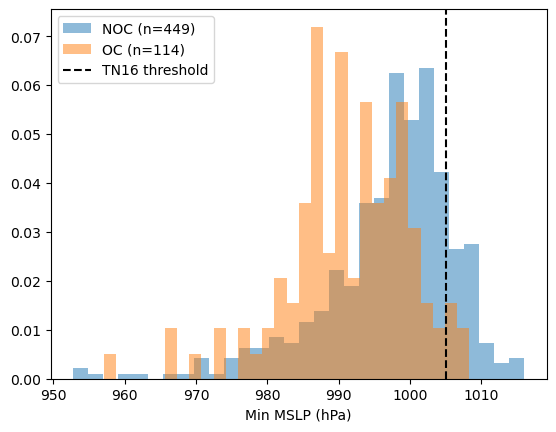

In [20]:
plt.hist(noc.min_msl, bins=30, alpha=0.5, label=f'NOC (n={len(noc)})', density=True)
plt.hist(oc.min_msl, bins=30, alpha=0.5, label=f'OC (n={len(oc)})', density=True)
plt.axvline(1005, color="k", ls="--", label="TN16 threshold")
plt.xlabel("Min MSLP (hPa)")
plt.legend()
print(oc.min_msl.describe(), noc.min_msl.describe())


In [21]:
## testing if the means are statistically different from eachother
from scipy.stats import permutation_test

oc_vals = oc['min_msl'].dropna().values
noc_vals = noc['min_msl'].dropna().values

def mean_diff(x,y):
    return np.mean(x) - np.mean(y)

res = permutation_test(
    (oc_vals, noc_vals), mean_diff,
    permutation_type="independent",
    n_resamples=10000, alternative="two-sided", random_state=1,
)

print(f"OC:  n={len(oc_vals):3d}  mean={np.mean(oc_vals):7.2f}  median={np.median(oc_vals):7.2f}  sd={np.std(oc_vals, ddof=1):5.2f}")
print(f"NOC: n={len(noc_vals):3d}  mean={np.mean(noc_vals):7.2f}  median={np.median(noc_vals):7.2f}  sd={np.std(noc_vals, ddof=1):5.2f}")
print(f"\nMean difference : {res.statistic:+.2f} hPa")
print(f"Permutation p   : {res.pvalue:.4f}")

OC:  n=114  mean= 991.18  median= 991.71  sd= 8.82
NOC: n=449  mean= 997.07  median= 998.77  sd= 9.57

Mean difference : -5.90 hPa
Permutation p   : 0.0002


Means are significantly different from eachother.  

## Adding core onset and peak report time to core_summary dataframe

In [11]:
etc_summary = pd.read_csv('data/etc_summary_final.csv')
#reports = pd.read_csv('data/reports_tagged_final.csv', low_memory=False)
cores = pd.read_csv('data/kde_core_summary.csv')

In [33]:
msl_map = (etc_summary
           .dropna(subset=['track_id'])
           .assign(track_id = lambda d: d['track_id'].astype(int))
           .set_index('track_id')['time_min_msl'])
msl_map = pd.to_datetime(msl_map, utc=True)

In [34]:
msl_map

track_id
1      1995-12-02 22:00:00+00:00
2      1995-12-10 06:00:00+00:00
3      1995-12-05 04:00:00+00:00
4      1995-12-06 04:00:00+00:00
5      1995-12-07 19:00:00+00:00
                  ...           
6114   2025-03-27 22:00:00+00:00
6116   2025-03-29 10:00:00+00:00
6117   2025-03-31 20:00:00+00:00
6119   2025-03-30 23:00:00+00:00
6120   2025-03-31 23:00:00+00:00
Name: time_min_msl, Length: 2225, dtype: datetime64[ns, UTC]

In [35]:
cores['time_min_msl'] = cores['track_id'].map(msl_map)

/tmp/ipykernel_2748897/3544581300.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cores['time_min_msl'] = cores['track_id'].map(msl_map)


In [37]:
cores['time_min_msl'].nunique()

269

In [41]:
etc_with_cores = etc_summary[etc_summary['n_cores_kept'] >=1]

In [43]:
etc_with_cores['time_min_msl'].nunique()

269

In [44]:
onset = pd.to_datetime(cores['onset_time'], utc=True)
peak = pd.to_datetime(cores['peak_time'], utc=True)

In [12]:
kept = cores[cores['kept']]
print(f"mean onset: {kept['onset_h_from_min_msl'].mean():+.1f} h from min MSL "
      f"(n={kept['onset_h_from_min_msl'].notna().sum()})")
print(f"mean peak : {kept['peak_h_from_min_msl'].mean():+.1f} h from min MSL")

mean onset: -40.2 h from min MSL (n=332)
mean peak : -32.6 h from min MSL


In [45]:
cores['onset_h_from_min_msl'] = (onset - cores['time_min_msl']).dt.total_seconds() / 3600
cores['peak_h_from_min_msl']  = (peak  - cores['time_min_msl']).dt.total_seconds() / 3600

/tmp/ipykernel_2748897/1578571765.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cores['onset_h_from_min_msl'] = (onset - cores['time_min_msl']).dt.total_seconds() / 3600
/tmp/ipykernel_2748897/1578571765.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cores['peak_h_from_min_msl']  = (peak  - cores['time_min_msl']).dt.total_seconds() / 3600


In [46]:
cores

,track_id,core_id,n_reports,n_tornado,n_hail,n_wind,t_start,t_end,lat_min,lax_max,...,thr_density_ratio,kept,centroid_lat,centroid_lon,onset_time,peak_time,peak_n_reports,time_min_msl,onset_h_from_min_msl,peak_h_from_min_msl
7,25,25_1g0,271,23,32,216,1996-01-18 00:00:00+00:00,1996-01-19 02:00:00+00:00,30.250,43.3000,...,0.031657,True,36.166605,-91.123137,1996-01-18 00:00:00+00:00,1996-01-18 16:00:00+00:00,29,1996-01-21 00:00:00+00:00,-72.0,-56.0
8,25,25_1g1,85,1,1,83,1996-01-19 06:00:00+00:00,1996-01-19 22:00:00+00:00,34.620,43.7800,...,0.031657,True,38.142941,-77.120471,1996-01-19 06:00:00+00:00,1996-01-19 16:00:00+00:00,12,1996-01-21 00:00:00+00:00,-42.0,-32.0
9,28,28_0,50,2,13,35,1996-01-26 13:00:00+00:00,1996-01-27 12:00:00+00:00,30.230,34.3000,...,0.031657,True,31.963400,-87.189000,1996-01-26 13:00:00+00:00,1996-01-27 00:00:00+00:00,8,1996-01-20 02:00:00+00:00,155.0,166.0
23,54,54_1g2,84,0,64,20,1996-02-27 15:00:00+00:00,1996-02-28 02:00:00+00:00,32.120,40.5500,...,0.031657,True,35.580238,-91.026310,1996-02-27 15:00:00+00:00,1996-02-27 19:00:00+00:00,14,1996-03-01 09:00:00+00:00,-66.0,-62.0
27,60,60_1g0,171,11,107,53,1996-03-05 18:00:00+00:00,1996-03-06 12:00:00+00:00,29.830,38.3700,...,0.031657,True,34.999298,-91.348947,1996-03-05 18:00:00+00:00,1996-03-06 04:00:00+00:00,28,1996-03-04 23:00:00+00:00,19.0,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1446,6109,6109_0g1,506,21,59,426,2025-03-16 03:00:00+00:00,2025-03-17 04:00:00+00:00,29.820,44.3300,...,0.040183,True,39.327536,-79.758995,2025-03-16 03:00:00+00:00,2025-03-16 16:00:00+00:00,134,2025-03-17 17:00:00+00:00,-38.0,-25.0
1449,6111,6111_1,206,16,43,147,2025-03-19 07:00:00+00:00,2025-03-20 03:00:00+00:00,35.993,42.5300,...,0.040183,True,40.001778,-87.383061,2025-03-19 07:00:00+00:00,2025-03-19 21:00:00+00:00,42,2025-03-19 04:00:00+00:00,3.0,17.0
1451,6113,6113_1,168,2,130,36,2025-03-23 21:00:00+00:00,2025-03-24 15:00:00+00:00,29.280,37.0739,...,0.040183,True,31.931806,-93.555014,2025-03-23 21:00:00+00:00,2025-03-23 23:00:00+00:00,35,2025-03-24 14:00:00+00:00,-17.0,-15.0
1457,6117,6117_4g0,70,1,49,20,2025-03-30 00:00:00+00:00,2025-03-30 08:00:00+00:00,31.180,41.6000,...,0.040183,True,34.925389,-97.082104,2025-03-30 00:00:00+00:00,2025-03-30 02:00:00+00:00,19,2025-03-31 20:00:00+00:00,-44.0,-42.0


## Distribution of Core Onset time (relative to min msl):

In [49]:
print("Average offset of core onset time from min msl:", cores['onset_h_from_min_msl'].mean())
print("Average offset of core peak time from min msl:", cores['peak_h_from_min_msl'].mean())

print("STD of offset of core onset time from min msl:", cores['onset_h_from_min_msl'].std())
print("Std of offset of core peak time from min msl:", cores['peak_h_from_min_msl'].std())

Average offset of core onset time from min msl: -40.25
Average offset of core peak time from min msl: -32.6355421686747
STD of offset of core onset time from min msl: 71.39800047129538
Std of offset of core peak time from min msl: 71.4957354188965


In [52]:
cores.to_csv('data/kde_core_summary.csv', index=False)

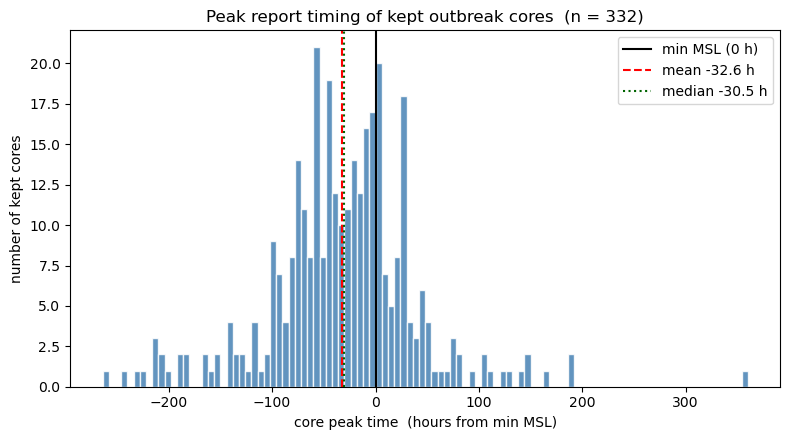

In [15]:
vals = kept['peak_h_from_min_msl'].dropna()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(vals, bins=range(int(vals.min()) - 3, int(vals.max()) + 6, 6),
        color='steelblue', edgecolor='white', alpha=0.85)

ax.axvline(0, color='k', lw=1.5, ls='-',  label='min MSL (0 h)')
ax.axvline(vals.mean(),   color='red',     lw=1.5, ls='--', label=f'mean {vals.mean():+.1f} h')
ax.axvline(vals.median(), color='darkgreen', lw=1.5, ls=':', label=f'median {vals.median():+.1f} h')

ax.set_xlabel('core peak time  (hours from min MSL)')
ax.set_ylabel('number of kept cores')
ax.set_title(f'Peak report timing of kept outbreak cores  (n = {len(vals)})')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
test = kept[kept['peak_h_from_min_msl'] >=300]

In [18]:
test

,track_id,core_id,n_reports,n_tornado,n_hail,n_wind,t_start,t_end,lat_min,lax_max,...,thr_density_ratio,kept,centroid_lat,centroid_lon,onset_time,peak_time,peak_n_reports,time_min_msl,onset_h_from_min_msl,peak_h_from_min_msl
183,3335,3335_0g0,185,12,41,132,2012-01-17 08:00:00+00:00,2012-01-18 00:00:00+00:00,31.079,43.15,...,0.036109,True,39.024085,-85.231618,2012-01-17 08:00:00+00:00,2012-01-17 23:00:00+00:00,22,2012-01-03 04:00:00+00:00,340.0,355.0


In [3]:
nodes = pd.read_csv('data/nodes_with_reports_final.csv')

In [7]:
test = nodes[nodes['track_id'] == 3335]

In [12]:
test

,track_id,time_hour,lat,lon,msl,n_reports,n_tornado,n_hail,n_wind
143853,3335,2011-12-31 04:00:00+00:00,40.75,128.25,1021.589,0,0,0,0
143854,3335,2011-12-31 05:00:00+00:00,40.75,128.25,1020.812,0,0,0,0
143855,3335,2011-12-31 06:00:00+00:00,40.75,128.25,1020.404,0,0,0,0
143856,3335,2011-12-31 07:00:00+00:00,40.75,128.25,1020.734,0,0,0,0
143857,3335,2011-12-31 11:00:00+00:00,39.00,132.75,1020.477,0,0,0,0
...,...,...,...,...,...,...,...,...,...
144408,3335,2012-01-24 08:00:00+00:00,54.75,23.50,1011.007,0,0,0,0
144409,3335,2012-01-24 09:00:00+00:00,55.00,23.50,1011.528,0,0,0,0
144410,3335,2012-01-24 10:00:00+00:00,55.00,24.00,1012.186,0,0,0,0
144411,3335,2012-01-24 11:00:00+00:00,54.75,24.25,1012.569,0,0,0,0


In [32]:
test['time_hour'].to_list()

['2011-12-31 04:00:00+00:00',
 '2011-12-31 05:00:00+00:00',
 '2011-12-31 06:00:00+00:00',
 '2011-12-31 07:00:00+00:00',
 '2011-12-31 11:00:00+00:00',
 '2011-12-31 12:00:00+00:00',
 '2011-12-31 14:00:00+00:00',
 '2011-12-31 15:00:00+00:00',
 '2011-12-31 16:00:00+00:00',
 '2011-12-31 17:00:00+00:00',
 '2011-12-31 18:00:00+00:00',
 '2011-12-31 19:00:00+00:00',
 '2011-12-31 20:00:00+00:00',
 '2011-12-31 21:00:00+00:00',
 '2011-12-31 22:00:00+00:00',
 '2011-12-31 23:00:00+00:00',
 '2012-01-01 00:00:00+00:00',
 '2012-01-01 01:00:00+00:00',
 '2012-01-01 02:00:00+00:00',
 '2012-01-01 03:00:00+00:00',
 '2012-01-01 04:00:00+00:00',
 '2012-01-01 05:00:00+00:00',
 '2012-01-01 06:00:00+00:00',
 '2012-01-01 07:00:00+00:00',
 '2012-01-01 08:00:00+00:00',
 '2012-01-01 09:00:00+00:00',
 '2012-01-01 10:00:00+00:00',
 '2012-01-01 11:00:00+00:00',
 '2012-01-01 12:00:00+00:00',
 '2012-01-01 13:00:00+00:00',
 '2012-01-01 14:00:00+00:00',
 '2012-01-01 15:00:00+00:00',
 '2012-01-01 16:00:00+00:00',
 '2012-01-